In [1]:
# ============================================================
# Imports and notebook-level constants
# ============================================================

!pip install captum

import os
import sys
import re
import glob
import csv
import json
import math
import zipfile
import urllib.request
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.models as models
from torchvision import datasets, transforms
from torchvision.models import (
    AlexNet_Weights,
    VGG16_Weights,
    ViT_B_16_Weights,
    vit_b_16,
)


try:
    from captum.attr import DeepLift,visualization as viz
except ImportError:
    DeepLift = None
    print("Captum is not installed. DeepLIFT cells require: pip install captum")




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 2.8 MB/s eta 0:00:00


In [2]:
# -------------------------------
# Step 2. Setup paths
# -------------------------------

from google.colab import drive
drive.mount('/content/drive')
drive_dir = '/content/drive/MyDrive/'

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUT_DIR = "/content/drive/MyDrive/AlexNet_Images"
TINY_ROOT = "/content/tiny-imagenet-200"

os.makedirs(OUT_DIR, exist_ok=True)
print("device:", DEVICE)

Mounted at /content/drive
device: cpu


In [ ]:
# ----------------------------
# Download TinyImageNet
# ----------------------------

import os, sys, zipfile, urllib.request

TINY_URLS = [
    "http://cs231n.stanford.edu/tiny-imagenet-200.zip",
    "https://cs231n.stanford.edu/tiny-imagenet-200.zip",
]
zip_path = "tiny-imagenet-200.zip"
extract_dir = "tiny-imagenet-200"

def _dl_progress(block_num, block_size, total_size):
    downloaded = block_num * block_size
    if total_size > 0:
        pct = 100.0 * downloaded / total_size
        mb = downloaded / (1024**2)
        tot = total_size / (1024**2)
        sys.stdout.write(f"\rDownloading: {pct:6.2f}%  ({mb:7.1f}/{tot:7.1f} MB)")
        sys.stdout.flush()

if not os.path.isdir(extract_dir):
    if not os.path.isfile(zip_path):
        last_err = None
        for url in TINY_URLS:
            try:
                print("Downloading Tiny ImageNet-200 from:", url)
                urllib.request.urlretrieve(url, zip_path, reporthook=_dl_progress)
                print("\nDownloaded:", zip_path)
                break
            except Exception as e:
                last_err = e
                print("\nFailed from:", url, "->", repr(e))
        if not os.path.isfile(zip_path):
            raise RuntimeError(f"Could not download tiny-imagenet-200.zip. Last error: {last_err}")

    print("Extracting...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(".")
    print("Extracted to:", extract_dir)
else:
    print("Already extracted:", extract_dir)

# sanity check
test_dir = os.path.join(extract_dir, "test", "images")
print("Test images dir:", test_dir)
print("Exists?", os.path.isdir(test_dir))
if os.path.isdir(test_dir):
    print("Num test images:", len(os.listdir(test_dir)))


Downloading: 100.00%  (  236.6/  236.6 MB)
Downloaded: tiny-imagenet-200.zip
Extracting...
Extracted to: tiny-imagenet-200
Test images dir: tiny-imagenet-200/test/images
Exists? True
Num test images: 10000


In [ ]:
# -------------------------------------------------------
# Layerwise BDI (Top-1 vs Top-2) + return C_evid / C_bias
# -------------------------------------------------------
def _get_conv_linear_layers(model: nn.Module):
    return [(name, m) for name, m in model.named_modules()
            if isinstance(m, (nn.Conv2d, nn.Linear))]

def _broadcast_bias(module: nn.Module, u: torch.Tensor) -> torch.Tensor:
    if getattr(module, "bias", None) is None or module.bias is None:
        return torch.zeros_like(u)
    b = module.bias
    if u.ndim == 2:       # Linear: (B, C)
        return b.view(1, -1).expand_as(u)
    if u.ndim == 4:       # Conv: (B, C, H, W)
        return b.view(1, -1, 1, 1).expand_as(u)
    return torch.zeros_like(u)

@torch.enable_grad()
def layerwise_bdi_top1_top2(model: nn.Module, x: torch.Tensor, layers=None, return_all_C: bool = True):
    """
    Computes layerwise BDI for margin m = z_top1 - z_top2 (Top-1 vs Top-2).

    Returns (if return_all_C=True):
      bdi_by_layer:      dict name -> (B,) float tensor
      bdi_all:           (B,) float tensor (abs-sum aggregate)
      top1_idx:          (B,) long
      top2_idx:          (B,) long
      C_evid_by_layer:   dict name -> (B,) float tensor (signed)
      C_bias_by_layer:   dict name -> (B,) float tensor (signed)
      C_evid_all:        (B,) float tensor (signed sum across layers)
      C_bias_all:        (B,) float tensor (signed sum across layers)

    If return_all_C=False, the last two are omitted.
    """
    model.eval()

    # Ensure grad graph
    x = x.detach()
    x.requires_grad_(True)

    if layers is None:
        layers = _get_conv_linear_layers(model)

    store, hooks = {}, []

    def make_hook(layer_name, layer_module):
        def hook_fn(m, inp, out):
            u = out
            if not u.requires_grad:
                raise RuntimeError(
                    f"{layer_name} output has requires_grad=False. "
                    f"Set x.requires_grad_(True) and avoid torch.inference_mode()/no_grad()."
                )
            u.retain_grad()
            store[layer_name] = {"u": u, "u_bias": _broadcast_bias(layer_module, u)}
        return hook_fn

    for name, m in layers:
        hooks.append(m.register_forward_hook(make_hook(name, m)))

    try:
        z = model(x)  # (B, K)
        if z.ndim != 2 or z.shape[1] < 2:
            raise ValueError(f"Expected logits shape (B,K) with K>=2; got {tuple(z.shape)}")

        top2 = torch.topk(z, k=2, dim=1).indices  # (B,2)
        top1_idx, top2_idx = top2[:, 0], top2[:, 1]

        z_top1 = z.gather(1, top1_idx[:, None]).squeeze(1)
        z_top2 = z.gather(1, top2_idx[:, None]).squeeze(1)
        m = z_top1 - z_top2  # (B,)

        model.zero_grad(set_to_none=True)
        m.sum().backward()

        bdi_by_layer = {}
        C_evid_by_layer = {}
        C_bias_by_layer = {}

        abs_bias_sum, abs_evid_sum = None, None
        C_bias_signed_sum, C_evid_signed_sum = None, None

        for name, _ in layers:
            u = store[name]["u"]
            u_bias = store[name]["u_bias"]
            g = u.grad
            if g is None:
                raise RuntimeError(f"{name}: u.grad is None (grad graph not built).")

            u_evid = u - u_bias
            dims = tuple(range(1, u.ndim))  # conv: (C,H,W), linear: (C,)

            C_bias = (g * u_bias).sum(dim=dims)    # (B,)
            C_evid = (g * u_evid).sum(dim=dims)    # (B,)

            C_bias_by_layer[name] = C_bias.detach()
            C_evid_by_layer[name] = C_evid.detach()

            denom = C_bias.abs() + C_evid.abs()
            bdi_l = torch.where(
                denom > 0,
                C_bias.abs() / denom,
                torch.full_like(denom, 0.5)
            )
            bdi_by_layer[name] = bdi_l.detach()

            abs_bias_sum = C_bias.abs() if abs_bias_sum is None else abs_bias_sum + C_bias.abs()
            abs_evid_sum = C_evid.abs() if abs_evid_sum is None else abs_evid_sum + C_evid.abs()

            if return_all_C:
                C_bias_signed_sum = C_bias if C_bias_signed_sum is None else C_bias_signed_sum + C_bias
                C_evid_signed_sum = C_evid if C_evid_signed_sum is None else C_evid_signed_sum + C_evid

        denom_all = abs_bias_sum + abs_evid_sum
        bdi_all = torch.where(
            denom_all > 0,
            abs_bias_sum / denom_all,
            torch.full_like(denom_all, 0.5)
        ).detach()

        if return_all_C:
            return (bdi_by_layer, bdi_all, top1_idx.detach(), top2_idx.detach(),
                    C_evid_by_layer, C_bias_by_layer,
                    C_evid_signed_sum.detach(), C_bias_signed_sum.detach())

        return (bdi_by_layer, bdi_all, top1_idx.detach(), top2_idx.detach(),
                C_evid_by_layer, C_bias_by_layer)

    finally:
        for h in hooks:
            h.remove()


# ----------------------------
# Model selection
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

USE = "vgg16"  # "alexnet" or "vgg16"

if USE == "alexnet":
    weights = AlexNet_Weights.IMAGENET1K_V1
    model = models.alexnet(weights=weights).to(device).eval()
elif USE == "vgg16":
    weights = VGG16_Weights.IMAGENET1K_V1
    model = models.vgg16(weights=weights).to(device).eval()
else:
    raise ValueError("USE must be 'alexnet' or 'vgg16'")

transform = weights.transforms()

# IMPORTANT: we need grads for BDI/C computations (do NOT disable globally)
# (We will use torch.no_grad() ONLY around pure forward/conf computations when safe.)

# ----------------------------
# Tiny-ImageNet paths (VAL is flat + annotations)
# ----------------------------
TINY_ROOT = "/content/tiny-imagenet-200"  # <-- change if needed
val_img_dir = os.path.join(TINY_ROOT, "val", "images")
val_ann_path = os.path.join(TINY_ROOT, "val", "val_annotations.txt")
train_dir = os.path.join(TINY_ROOT, "train")

if not os.path.isdir(val_img_dir):
    raise FileNotFoundError(f"Not found: {val_img_dir}")
if not os.path.isfile(val_ann_path):
    raise FileNotFoundError(f"Not found: {val_ann_path}")
if not os.path.isdir(train_dir):
    raise FileNotFoundError(f"Not found: {train_dir}")

# ----------------------------
# Build Tiny wnid -> y_tiny (0..199) from train folders
# ----------------------------
wnids = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
if len(wnids) == 0:
    raise RuntimeError(f"No class folders found under: {train_dir}")

wnid_to_tiny = {w: i for i, w in enumerate(wnids)}
print("✅ #Tiny classes:", len(wnids))

# ----------------------------
# ImageNet-1k wnid -> index mapping (download JSON if needed)
# ----------------------------
out_dir = "/content/drive/MyDrive/AlexNet_Images"
os.makedirs(out_dir, exist_ok=True)

IMAGENET_CLASS_INDEX_JSON = os.path.join(out_dir, "imagenet_class_index.json")

def ensure_imagenet_class_index_json(path=IMAGENET_CLASS_INDEX_JSON):
    if os.path.isfile(path) and os.path.getsize(path) > 0:
        return path
    url = "https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json"
    print("⬇️ Downloading ImageNet class index JSON:", url)
    urllib.request.urlretrieve(url, path)
    if not os.path.isfile(path) or os.path.getsize(path) == 0:
        raise RuntimeError("Failed to download imagenet_class_index.json")
    return path

def load_wnid2im1k(json_path=IMAGENET_CLASS_INDEX_JSON):
    with open(json_path, "r") as f:
        j = json.load(f)  # {"0":["n01440764","tench"], ...}
    return {v[0]: int(k) for k, v in j.items()}

ensure_imagenet_class_index_json()
WNID2IM1K = load_wnid2im1k()
print("✅ ImageNet-1k wnid map size:", len(WNID2IM1K))

# ----------------------------
# Parse val_annotations.txt (filename -> wnid)
# ----------------------------
fname_to_wnid = {}
with open(val_ann_path, "r") as f:
    for line in f:
        parts = line.strip().split("\t")
        if len(parts) >= 2:
            fname_to_wnid[parts[0]] = parts[1]

# ----------------------------
# Collect validation images + labels (deterministic order)
# items: (img_path, y_tiny, wnid, y_im1k)
# ----------------------------
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp", ".JPEG", ".JPG")
all_imgs = sorted(glob.glob(os.path.join(val_img_dir, "*")))
all_imgs = [p for p in all_imgs if os.path.splitext(p)[1] in IMG_EXTS]
all_imgs = sorted(list(dict.fromkeys(all_imgs)))

items = []
missing = 0
missing_im1k = 0
for p in all_imgs:
    fn = os.path.basename(p)
    wnid = fname_to_wnid.get(fn, None)
    if wnid is None or wnid not in wnid_to_tiny:
        missing += 1
        continue
    y_tiny = wnid_to_tiny[wnid]
    y_im1k = WNID2IM1K.get(wnid, -1)
    if y_im1k < 0:
        missing_im1k += 1
    items.append((p, int(y_tiny), wnid, int(y_im1k)))

print("N val images found:", len(all_imgs))
print("N labeled val images:", len(items))
if missing:
    print("⚠️ Missing/unknown Tiny labels for:", missing)
if missing_im1k:
    print("⚠️ Tiny wnid not in ImageNet-1k mapping:", missing_im1k, "(these will have valid_label=0)")

if len(items) == 0:
    raise RuntimeError("No labeled images found. Check Tiny-ImageNet paths.")

# ----------------------------
# Saving config (ONE CSV)
# ----------------------------
SAVE_EVERY = 1000   # flush to disk every N newly-processed images
BATCH = 100          # batch size for processing

csv_path = os.path.join(out_dir, f"{USE}_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv")

# ----------------------------
# Helpers: CSV append + load seen
# ----------------------------
def _csv_append(path: str, header: list, rows: list):
    file_exists = os.path.exists(path) and os.path.getsize(path) > 0
    with open(path, "a", newline="") as f:
        w = csv.writer(f)
        if not file_exists:
            w.writerow(header)
        w.writerows(rows)

def _load_seen_img_paths(path: str) -> set:
    if not (os.path.exists(path) and os.path.getsize(path) > 0):
        return set()
    seen = set()
    with open(path, "r", newline="") as f:
        r = csv.reader(f)
        header = next(r, None)
        if header is None:
            return set()
        try:
            idx = header.index("img_path")
        except ValueError:
            idx = 0
        for row in r:
            if len(row) > idx:
                seen.add(row[idx])
    return seen

# ----------------------------
# Layers + probe dims to build stable header
# ----------------------------
layers = _get_conv_linear_layers(model)
layer_names = [n for n, _ in layers]

@torch.no_grad()
def _probe_layer_dims(probe_items):
    imgs = []
    ok = []
    for (p, _y_tiny, _wnid, _y_im1k) in probe_items:
        try:
            img = Image.open(p).convert("RGB")
            imgs.append(transform(img))
            ok.append(p)
        except:
            pass
    if len(imgs) == 0:
        return None

    x = torch.stack(imgs, dim=0).to(device)

    # unpack with C_* returns
    (bdi_by_layer, bdi_all, top1_idx, top2_idx,
     C_evid_by_layer, C_bias_by_layer, C_evid_all, C_bias_all) = \
        layerwise_bdi_top1_top2(model, x, layers=layers, return_all_C=True)

    dims = {}
    for name in layer_names:
        arr = np.asarray(bdi_by_layer[name].detach().cpu().numpy())
        if arr.shape[0] != len(ok):
            raise ValueError(f"Probe: {name} first dim mismatch {arr.shape[0]} vs {len(ok)}")
        dims[name] = int(arr.reshape(arr.shape[0], -1).shape[1])
    return dims

probe_dims = None
for j in range(min(200, len(items))):
    probe_dims = _probe_layer_dims(items[j:j+min(8, BATCH)])
    if probe_dims is not None:
        break
if probe_dims is None:
    raise RuntimeError("Could not probe layer dims (no readable images).")

# ----------------------------
# Header (FIXED: includes y_tiny + y_im1k + valid_label)
# + includes aggregated C_*_all and per-layer Cevid/Cbias
# ----------------------------
header = [
    "img_path", "wnid",
    "y_tiny", "y_im1k", "valid_label",
    "pred", "conf", "correct",
    "bdi_all", "top1", "top2",
    "C_evid_all", "C_bias_all"  # aggregated signed sums (diagnostic)
]

# per-layer scalar contributions
for name in layer_names:
    safe = name.replace(".", "__")
    header.append(f"{safe}__Cevid")
    header.append(f"{safe}__Cbias")

# existing per-unit BDI columns
for name in layer_names:
    K = probe_dims[name]
    safe = name.replace(".", "__")
    for k in range(K):
        header.append(f"{safe}__bdi{k}")

# ----------------------------
# Load seen (skip already-run images)
# ----------------------------
seen = _load_seen_img_paths(csv_path)
print(f"Already processed (from CSV): {len(seen)} images")

# ----------------------------
# Batch processing: BDI + confidence + correctness (fixed) + C_evid/C_bias
# ----------------------------
def process_batch(batch_items):
    imgs, ok_items = [], []
    for (p, y_tiny, wnid, y_im1k) in batch_items:
        try:
            img = Image.open(p).convert("RGB")
            imgs.append(transform(img))
            ok_items.append((p, int(y_tiny), wnid, int(y_im1k)))
        except Exception as e:
            print(f"Skipping unreadable {p}: {e}")

    if len(imgs) == 0:
        return None

    x = torch.stack(imgs, dim=0).to(device)

    # ---- BDI + C_evid/C_bias (needs grad) ----
    (bdi_by_layer, bdi_all, top1_idx, top2_idx,
     C_evid_by_layer, C_bias_by_layer, C_evid_all, C_bias_all) = \
        layerwise_bdi_top1_top2(model, x, layers=layers, return_all_C=True)

    # ---- Confidence (softmax top-1) from the model logits ----
    with torch.no_grad():
        logits = model(x)
        prob = F.softmax(logits, dim=1)
        conf, pred = torch.max(prob, dim=1)  # (B,), (B,)

    # ---- to numpy ----
    ok_paths = [t[0] for t in ok_items]
    y_tiny_np = np.array([t[1] for t in ok_items], dtype=np.int32)
    wnids_b   = [t[2] for t in ok_items]
    y_im1k_np = np.array([t[3] for t in ok_items], dtype=np.int32)

    pred_np = pred.detach().cpu().numpy().astype(np.int32, copy=False)
    conf_np = conf.detach().cpu().numpy().astype(np.float32, copy=False)

    valid_np = (y_im1k_np >= 0).astype(np.int32)
    correct_np = np.zeros_like(valid_np, dtype=np.int32)
    correct_np[valid_np == 1] = (pred_np[valid_np == 1] == y_im1k_np[valid_np == 1]).astype(np.int32)

    bdi_all_np = bdi_all.detach().cpu().numpy().reshape(-1).astype(np.float32, copy=False)
    top1_np = top1_idx.detach().cpu().numpy().reshape(-1).astype(np.int32, copy=False)
    top2_np = top2_idx.detach().cpu().numpy().reshape(-1).astype(np.int32, copy=False)

    # aggregated signed sums across layers
    C_evid_all_np = C_evid_all.detach().cpu().numpy().reshape(-1).astype(np.float32, copy=False)
    C_bias_all_np = C_bias_all.detach().cpu().numpy().reshape(-1).astype(np.float32, copy=False)

    # per-layer signed scalars (B,)
    Ce_layer_np = {k: v.detach().cpu().numpy().reshape(-1).astype(np.float32, copy=False)
                   for k, v in C_evid_by_layer.items()}
    Cb_layer_np = {k: v.detach().cpu().numpy().reshape(-1).astype(np.float32, copy=False)
                   for k, v in C_bias_by_layer.items()}

    # per-layer BDI arrays (possibly vector-shaped) for existing behavior
    bdi_layer_np = {k: v.detach().cpu().numpy() for k, v in bdi_by_layer.items()}

    return (ok_paths, wnids_b, y_tiny_np, y_im1k_np, valid_np,
            pred_np, conf_np, correct_np,
            bdi_all_np, top1_np, top2_np,
            C_evid_all_np, C_bias_all_np, Ce_layer_np, Cb_layer_np,
            bdi_layer_np)

# ----------------------------
# Chunked writing
# ----------------------------
chunk_rows = []
chunk_paths = []
chunk_count = 0
n_done_total = 0

def flush():
    global chunk_rows, chunk_paths, chunk_count, seen
    if chunk_count == 0:
        return
    _csv_append(csv_path, header, chunk_rows)
    for p in chunk_paths:
        seen.add(p)
    print(f"✅ Flushed {chunk_count} new images to {csv_path} (seen now {len(seen)})", flush=True)
    chunk_rows = []
    chunk_paths = []
    chunk_count = 0

# ----------------------------
# Main loop with skip
# ----------------------------
N = len(items)
total_batches = math.ceil(N / BATCH)

for bi in range(total_batches):
    batch = items[bi*BATCH:(bi+1)*BATCH]

    # skip already processed
    batch = [it for it in batch if it[0] not in seen]
    if len(batch) == 0:
        if (bi + 1) % 100 == 0:
            print(f"[{bi+1}/{total_batches}] batch skipped (all previously processed)", flush=True)
        continue

    out = process_batch(batch)
    if out is None:
        continue

    (ok_paths, wnids_b, y_tiny_np, y_im1k_np, valid_np,
     pred_np, conf_np, correct_np,
     bdi_all_np, top1_np, top2_np,
     C_evid_all_np, C_bias_all_np, Ce_layer_np, Cb_layer_np,
     bdi_layer_np) = out

    m = len(ok_paths)

    # flatten layer BDI arrays
    flat_layers = {}
    for name in layer_names:
        arr = np.asarray(bdi_layer_np[name])
        if arr.shape[0] != m:
            raise ValueError(f"Layer {name}: first dim mismatch {arr.shape[0]} vs {m}")
        arr2 = arr.reshape(m, -1)
        if arr2.shape[1] != probe_dims[name]:
            raise ValueError(f"Layer {name}: dim changed (expected {probe_dims[name]}, got {arr2.shape[1]})")
        flat_layers[name] = arr2

    # build rows
    for r in range(m):
        p = ok_paths[r]
        row = [
            p,
            wnids_b[r],
            int(y_tiny_np[r]),
            int(y_im1k_np[r]),
            int(valid_np[r]),
            int(pred_np[r]),
            float(conf_np[r]),
            int(correct_np[r]),
            float(bdi_all_np[r]),
            int(top1_np[r]),
            int(top2_np[r]),
            float(C_evid_all_np[r]),
            float(C_bias_all_np[r]),
        ]

        # per-layer Cevid/Cbias scalars
        for name in layer_names:
            row.append(float(Ce_layer_np[name][r]))
            row.append(float(Cb_layer_np[name][r]))

        # per-unit BDI vectors (existing behavior)
        for name in layer_names:
            row.extend([float(x) for x in flat_layers[name][r]])

        chunk_rows.append(row)
        chunk_paths.append(p)

    n_done_total += m
    chunk_count += m

    # optional quick monitoring (accuracy on valid subset only)
    if n_done_total % 500 == 0:
        valid_rate = float(valid_np.mean())
        acc_valid = float(correct_np[valid_np == 1].mean()) if np.any(valid_np == 1) else float("nan")
        print(f"newly processed: {n_done_total} | valid_label≈{valid_rate:.3f} | acc(valid)≈{acc_valid:.3f} | total seen: {len(seen)}", flush=True)
    else:
        print(f"newly processed this run: {n_done_total} | total seen: {len(seen)}", flush=True)

    if chunk_count >= SAVE_EVERY:
        flush()

flush()
print("Done. CSV:", csv_path)


✅ #Tiny classes: 200
✅ ImageNet-1k wnid map size: 1000
N val images found: 10000
N labeled val images: 10000
Already processed (from CSV): 10000 images
[100/100] batch skipped (all previously processed)
Done. CSV: /content/drive/MyDrive/AlexNet_Images/vgg16_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv


Loaded: /content/drive/MyDrive/AlexNet_Images/vgg16_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv
Shape: (10000, 61)
Using LAST-LAYER BDI column: classifier__6__bdi0
Using LAST-LAYER C_evid column: classifier__6__Cevid
Saved: /content/drive/MyDrive/AlexNet_Images/vgg16_scatter_lastlayerCevid_vs_lastlayerBDI_Mismatch.eps


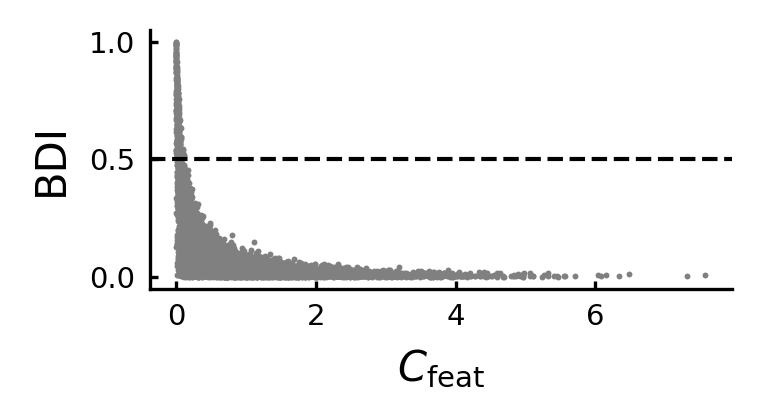

vgg16: n=10000, acc=0.1672


In [ ]:
#---------------------
# CNN plots
#---------------------

USE = "vgg16"  # "alexnet" | "vgg16"
out_dir = "/content/drive/MyDrive/AlexNet_Images"
csv_path = os.path.join(out_dir, f"{USE}_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv")

CORRECT = False
save_fig = True
CEVID_LIM = None          # e.g., (-200, 200) or leave None to auto


BDI_LIM   = (-0.05, 1.05)

# ---- load CSV ----
df = pd.read_csv(csv_path)
print("Loaded:", csv_path)
print("Shape:", df.shape)

# ---- locate BDI column (prefer last-layer bdi) ----
bdi_col = "bdi_all" if "bdi_all" in df.columns else ("bdi" if "bdi" in df.columns else None)
if bdi_col is None and not any(re.search(r"__bdi\d+$", c) for c in df.columns):
    raise ValueError(f"Missing BDI columns. Found: {df.columns.tolist()[:40]} ...")

layer_bdi_cols = [c for c in df.columns if re.search(r"__bdi\d+$", c)]
last_layer_col = None

def layer_sort_key(colname: str):
    s = re.sub(r"__bdi\d+$", "", colname)
    m = re.match(r"^(features|classifier)__(\d+)$", s)
    if m:
        block = m.group(1)
        idx = int(m.group(2))
        group = 0 if block == "features" else 1
        return (group, idx, colname)
    nums = re.findall(r"\d+", s)
    first_num = int(nums[0]) if nums else 10**9
    return (2, first_num, colname)

if layer_bdi_cols:
    layer_bdi_cols = sorted(layer_bdi_cols, key=layer_sort_key)
    last_layer_col = layer_bdi_cols[-1]
    y_bdi = pd.to_numeric(df[last_layer_col], errors="coerce").to_numpy(float)
    print("Using LAST-LAYER BDI column:", last_layer_col)
else:
    y_bdi = pd.to_numeric(df[bdi_col], errors="coerce").to_numpy(float)
    print("No per-layer bdi columns found; using:", bdi_col)

# ---- locate C_evid (prefer last-layer Cevid; fallback to C_evid_all) ----
cevid_all_col = "C_evid_all" if "C_evid_all" in df.columns else None
layer_cevid_cols = [c for c in df.columns if c.endswith("__Cevid")]

last_cevid_col = None
if layer_cevid_cols:
    # Sort layer Cevid columns using the corresponding layer name in the prefix
    def cevid_sort_key(colname: str):
        # e.g., "features__10__Cevid" -> treat as "features__10"
        s = re.sub(r"__Cevid$", "", colname)
        m = re.match(r"^(features|classifier)__(\d+)$", s)
        if m:
            block = m.group(1)
            idx = int(m.group(2))
            group = 0 if block == "features" else 1
            return (group, idx, colname)
        nums = re.findall(r"\d+", s)
        first_num = int(nums[0]) if nums else 10**9
        return (2, first_num, colname)

    layer_cevid_cols = sorted(layer_cevid_cols, key=cevid_sort_key)
    last_cevid_col = layer_cevid_cols[-1]
    x_cevid = pd.to_numeric(df[last_cevid_col], errors="coerce").to_numpy(float)
    print("Using LAST-LAYER C_evid column:", last_cevid_col)
elif cevid_all_col is not None:
    x_cevid = pd.to_numeric(df[cevid_all_col], errors="coerce").to_numpy(float)
    print("No per-layer Cevid columns found; using:", cevid_all_col)
else:
    raise ValueError(
        "Missing C_evid columns. Expected per-layer '*__Cevid' or 'C_evid_all'. "
        f"Found columns head: {df.columns.tolist()[:60]} ..."
    )

# ---- correctness (for black/gray plotting) ----
if "correct" not in df.columns:
    raise ValueError("Missing 'correct' column in CSV (needed for black/gray plotting).")
correct = pd.to_numeric(df["correct"], errors="coerce").to_numpy(float)

# Optional but recommended: filter to valid_label==1
if "valid_label" in df.columns:
    valid = pd.to_numeric(df["valid_label"], errors="coerce").to_numpy(float)
    valid_mask = (valid == 1)
else:
    valid_mask = np.ones(len(df), dtype=bool)

mask = np.isfinite(x_cevid) & np.isfinite(y_bdi) & np.isfinite(correct) & valid_mask
x_cevid, y_bdi = x_cevid[mask], y_bdi[mask]
correct = correct[mask].astype(int)

m_ok = (correct == 1)
m_bad = (correct == 0)

# ---- plot ----
fig, ax = plt.subplots(figsize=(2.7, 1.5), dpi=300)

# Plot incorrect first (gray), then correct on top (black)
if CORRECT:
    ax.scatter(abs(x_cevid[m_ok]),  y_bdi[m_ok],  s=2, color="black", alpha=1.0, linewidths=0, rasterized=True)
else:
    ax.scatter(abs(x_cevid[m_bad]), y_bdi[m_bad], s=2, color="gray",  alpha=1.0, linewidths=0, rasterized=True)


ax.axhline(0.5, linestyle="--", color="black", linewidth=1)

if CEVID_LIM is not None:
    ax.set_xlim(*CEVID_LIM)
ax.set_ylim(*BDI_LIM)

# ax.set_xlabel("C_evid", fontsize=10)
ax.set_xlabel(r"$C_{\mathrm{feat}}$", fontsize=10)
ax.set_ylabel("BDI", fontsize=10)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.tick_params(axis="both", which="both", direction="in", length=2, labelsize=7)

fig.tight_layout()

# ---- save ----
tag_cevid = "lastlayerCevid" if last_cevid_col is not None else "CevidAll"
tag_bdi   = "lastlayerBDI" if last_layer_col is not None else "bdiAll"

outpath = os.path.join(out_dir, f"{USE}_scatter_{tag_cevid}_vs_{tag_bdi}_correct_gray.eps")

if save_fig:
   if CORRECT:
      outpath = os.path.join(out_dir, f"{USE}_scatter_lastlayerCevid_vs_lastlayerBDI_Match.eps")
      fig.savefig(outpath, format="eps", bbox_inches="tight", pad_inches=0.02)
      print("Saved:", outpath)
   else:
      outpath = os.path.join(out_dir, f"{USE}_scatter_lastlayerCevid_vs_lastlayerBDI_Mismatch.eps")
      fig.savefig(outpath, format="eps", bbox_inches="tight", pad_inches=0.02)
      print("Saved:", outpath)

plt.show()

acc = float(m_ok.mean()) if correct.size else np.nan
print(f"{USE}: n={x_cevid.size}, acc={acc:.4f}")


Loaded: /content/drive/MyDrive/AlexNet_Images/vgg16_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv
Shape: (10000, 61)
Using LAST-LAYER BDI column: classifier__6__bdi0
Saved: /content/drive/MyDrive/AlexNet_Images/vgg16_scatter_conf_vs_lastlayerBDI_with_binned_summary.eps


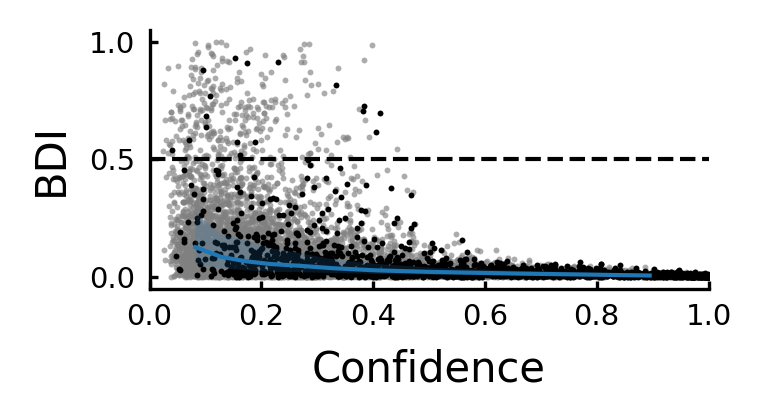

vgg16: n=10000, acc=0.1672
Binned summary: kept 10 bins (min_per_bin=25, method=quantile, nbins=10)


In [ ]:
# ---- set these to match your saved file ----
USE = "vgg16"  # "alexnet" | "vgg16"
out_dir = "/content/drive/MyDrive/AlexNet_Images"
csv_path = os.path.join(out_dir, f"{USE}_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv")

save_fig = True
CONF_LIM = (0.0, 1.0)
BDI_LIM  = (-0.05, 1.05)

# ---- binned summary params ----
NBINS = 10                      # 5–10 reads well for Fig 5A
BINNING = "quantile"            # "quantile" or "uniform"
SHOW_IQR = True                 # IQR band around median
MIN_PER_BIN = 25                # skip bins with too few points

# ---- load CSV ----
df = pd.read_csv(csv_path)
print("Loaded:", csv_path)
print("Shape:", df.shape)

# ---- locate columns ----
conf_col = "conf" if "conf" in df.columns else None
bdi_col  = "bdi_all" if "bdi_all" in df.columns else ("bdi" if "bdi" in df.columns else None)

if conf_col is None:
    raise ValueError(f"Missing 'conf' in columns: {df.columns.tolist()[:40]} ...")
if bdi_col is None:
    raise ValueError(f"Missing BDI column ('bdi_all' or 'bdi'). Found: {df.columns.tolist()[:40]} ...")

# ---- LAST-LAYER BDI (preferred) ----
layer_bdi_cols = [c for c in df.columns if re.search(r"__bdi\d+$", c)]
last_layer_col = None

def layer_sort_key(colname: str):
    s = re.sub(r"__bdi\d+$", "", colname)
    m = re.match(r"^(features|classifier)__(\d+)$", s)
    if m:
        block = m.group(1)
        idx = int(m.group(2))
        group = 0 if block == "features" else 1
        return (group, idx, colname)
    nums = re.findall(r"\d+", s)
    first_num = int(nums[0]) if nums else 10**9
    return (2, first_num, colname)

if layer_bdi_cols:
    layer_bdi_cols = sorted(layer_bdi_cols, key=layer_sort_key)
    last_layer_col = layer_bdi_cols[-1]
    y = pd.to_numeric(df[last_layer_col], errors="coerce").to_numpy(float)
    print("Using LAST-LAYER BDI column:", last_layer_col)
else:
    y = pd.to_numeric(df[bdi_col], errors="coerce").to_numpy(float)
    print("No per-layer bdi columns found; using:", bdi_col)

x = pd.to_numeric(df[conf_col], errors="coerce").to_numpy(float)

# ---- correctness ----
if "correct" not in df.columns:
    raise ValueError("Missing 'correct' column in CSV (needed for black/gray plotting).")
correct = pd.to_numeric(df["correct"], errors="coerce").to_numpy(float)

# Optional but recommended: if you used the fixed-label CSV, filter to valid_label==1
if "valid_label" in df.columns:
    valid = pd.to_numeric(df["valid_label"], errors="coerce").to_numpy(float)
    valid_mask = (valid == 1)
else:
    valid_mask = np.ones(len(df), dtype=bool)

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(correct) & valid_mask
x, y = x[mask], y[mask]
correct = correct[mask].astype(int)

m_ok = (correct == 1)
m_bad = (correct == 0)

# ---- helper to compute binned summaries ----
def binned_summary(xv, yv, nbins=10, method="quantile", min_per_bin=10):
    xv = np.asarray(xv)
    yv = np.asarray(yv)

    if method == "quantile":
        edges = np.quantile(xv, np.linspace(0, 1, nbins + 1))
        # make edges strictly increasing to avoid empty/repeated bins
        edges = np.unique(edges)
        if edges.size < 3:
            raise ValueError("Quantile bin edges collapsed. Try uniform binning or fewer bins.")
    elif method == "uniform":
        edges = np.linspace(CONF_LIM[0], CONF_LIM[1], nbins + 1)
    else:
        raise ValueError("method must be 'quantile' or 'uniform'")

    # assign bins
    idx = np.digitize(xv, edges, right=False) - 1  # 0..nbins-1
    # clamp right edge
    idx = np.clip(idx, 0, len(edges) - 2)

    xc, med, q25, q75, n = [], [], [], [], []
    for b in range(len(edges) - 1):
        sel = (idx == b)
        if sel.sum() < min_per_bin:
            continue
        xb = xv[sel]
        yb = yv[sel]
        xc.append(np.median(xb))               # x position as median confidence in bin
        med.append(np.median(yb))
        q25.append(np.quantile(yb, 0.25))
        q75.append(np.quantile(yb, 0.75))
        n.append(sel.sum())

    return (np.array(xc), np.array(med), np.array(q25), np.array(q75), np.array(n))

# compute summaries (overall, and optionally for correct/incorrect separately)
xc_all, med_all, q25_all, q75_all, n_all = binned_summary(
    x, y, nbins=NBINS, method=BINNING, min_per_bin=MIN_PER_BIN
)

# ---- plot ----
fig, ax = plt.subplots(figsize=(2.7, 1.5), dpi=300)

# scatter points
if np.any(m_bad):
    ax.scatter(x[m_bad], y[m_bad], s=2, color="gray",  alpha=.65, linewidths=0, rasterized=True)
if np.any(m_ok):
    ax.scatter(x[m_ok],  y[m_ok],  s=2, color="black", alpha=1.0, linewidths=0, rasterized=True)

# binned median + IQR band
if xc_all.size:
    if SHOW_IQR:
        ax.fill_between(xc_all, q25_all, q75_all, alpha=0.20, linewidth=0)
    ax.plot(xc_all, med_all, linewidth=1)

ax.axhline(0.5, linestyle="--", color="black", linewidth=1)
ax.set_xlim(*CONF_LIM)
ax.set_ylim(*BDI_LIM)

ax.set_xlabel("Confidence", fontsize=10)
ax.set_ylabel("BDI", fontsize=10)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.tick_params(axis="both", which="both", direction="in", length=2, labelsize=7)

fig.tight_layout()

outpath = os.path.join(out_dir, f"{USE}_scatter_conf_vs_lastlayerBDI_with_binned_summary.eps")
if save_fig:
    fig.savefig(outpath, bbox_inches="tight", pad_inches=0.02)
    print("Saved:", outpath)

plt.show()

acc = float(m_ok.mean()) if correct.size else np.nan
print(f"{USE}: n={x.size}, acc={acc:.4f}")
print(f"Binned summary: kept {xc_all.size} bins (min_per_bin={MIN_PER_BIN}, method={BINNING}, nbins={NBINS})")


In [ ]:
# ============================================================
# Load/reconstruct layerwise BDI arrays for AlexNet or VGG-16
# ============================================================

import os
import re
import numpy as np
import pandas as pd

# Choose model
USE = "alexnet"   # options: "alexnet", "vgg16"

out_dir = "/content/drive/MyDrive/AlexNet_Images"

csv_path = os.path.join(
    out_dir,
    f"{USE}_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv"
)

if not os.path.isfile(csv_path):
    raise FileNotFoundError(f"CSV not found: {csv_path}")

df = pd.read_csv(csv_path)

print("Loaded:", csv_path)
print("Shape:", df.shape)
print("First columns:", df.columns[:15].tolist())


# ------------------------------------------------------------
# Core columns
# ------------------------------------------------------------
top1_col = "top1" if "top1" in df.columns else "top1_idx" if "top1_idx" in df.columns else None
top2_col = "top2" if "top2" in df.columns else "top2_idx" if "top2_idx" in df.columns else None
bdi_all_col = "bdi_all" if "bdi_all" in df.columns else "bdi_all_layers" if "bdi_all_layers" in df.columns else None

if bdi_all_col is None:
    raise ValueError(
        "Could not find global BDI column. Expected 'bdi_all' or 'bdi_all_layers'."
    )

bdi_all_np = df[bdi_all_col].to_numpy(dtype=np.float32)

if top1_col is not None:
    top1_np = df[top1_col].to_numpy(dtype=np.int32)
else:
    top1_np = None

if top2_col is not None:
    top2_np = df[top2_col].to_numpy(dtype=np.int32)
else:
    top2_np = None


# ------------------------------------------------------------
# Reconstruct layerwise BDI dictionary
# Supports:
#   New format:    "<layer>__bdi"
#   Indexed format:"<layer>__bdi0", "<layer>__bdi1", ...
#   Old format:    "bdi_<layer>"
# ------------------------------------------------------------
bdi_layers_np = {}

# New/current format: one scalar column per layer
scalar_bdi_cols = [
    c for c in df.columns
    if c.endswith("__bdi")
]

if len(scalar_bdi_cols) > 0:
    for c in scalar_bdi_cols:
        layer_name = c.replace("__bdi", "")
        bdi_layers_np[layer_name] = df[c].to_numpy(dtype=np.float32)

else:
    # Indexed format: layer__bdi0, layer__bdi1, ...
    indexed_bdi_cols = [
        c for c in df.columns
        if re.search(r"__bdi\d+$", c)
    ]

    if len(indexed_bdi_cols) > 0:
        prefixes = sorted(
            set(re.sub(r"__bdi\d+$", "", c) for c in indexed_bdi_cols)
        )

        for pref in prefixes:
            cols_pref = [
                c for c in indexed_bdi_cols
                if re.sub(r"__bdi\d+$", "", c) == pref
            ]

            cols_pref = sorted(
                cols_pref,
                key=lambda c: int(re.search(r"__bdi(\d+)$", c).group(1))
            )

            arr = df[cols_pref].to_numpy(dtype=np.float32)

            if arr.shape[1] == 1:
                arr = arr[:, 0]

            bdi_layers_np[pref] = arr

    else:
        # Older format: bdi_features.0, bdi_classifier.6, etc.
        old_bdi_cols = [
            c for c in df.columns
            if c.startswith("bdi_") and c not in ("bdi_all", "bdi_all_layers")
        ]

        if len(old_bdi_cols) == 0:
            raise ValueError(
                "Could not find any layerwise BDI columns.\n"
                "Expected columns like '<layer>__bdi', '<layer>__bdi0', or 'bdi_<layer>'."
            )

        for c in old_bdi_cols:
            layer_name = c[len("bdi_"):]
            bdi_layers_np[layer_name] = df[c].to_numpy(dtype=np.float32)


print("Reconstructed:")
print("  bdi_all_np:", bdi_all_np.shape)
print("  top1_np:", None if top1_np is None else top1_np.shape)
print("  top2_np:", None if top2_np is None else top2_np.shape)
print("  N layerwise BDI arrays:", len(bdi_layers_np))
print("  First layers:", list(bdi_layers_np.keys())[:10])

Loaded: /content/drive/MyDrive/AlexNet_Images/alexnet_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv
Shape: (10000, 37)
First columns: ['img_path', 'wnid', 'y_tiny', 'y_im1k', 'valid_label', 'pred', 'conf', 'correct', 'bdi_all', 'top1', 'top2', 'C_evid_all', 'C_bias_all', 'features__0__Cevid', 'features__0__Cbias']
Reconstructed:
  bdi_all_np: (10000,)
  top1_np: (10000,)
  top2_np: (10000,)
  N layerwise BDI arrays: 8
  First layers: ['classifier__1', 'classifier__4', 'classifier__6', 'features__0', 'features__10', 'features__3', 'features__6', 'features__8']


Loaded: /content/drive/MyDrive/AlexNet_Images/alexnet_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv
Shape: (10000, 37)
First columns: ['img_path', 'wnid', 'y_tiny', 'y_im1k', 'valid_label', 'pred', 'conf', 'correct', 'bdi_all', 'top1', 'top2', 'C_evid_all', 'C_bias_all', 'features__0__Cevid', 'features__0__Cbias']
Reconstructed:
  bdi_all_np: (10000,)
  top1_np: (10000,)
  top2_np: (10000,)
  N layerwise BDI arrays: 8
  First layers: ['classifier__1', 'classifier__4', 'classifier__6', 'features__0', 'features__10', 'features__3', 'features__6', 'features__8']

Layer order:
00: features__0
01: features__3
02: features__6
03: features__8
04: features__10
05: classifier__1
06: classifier__4
07: classifier__6
Saved: /content/drive/MyDrive/AlexNet_Images/ImageNet_alexnet_BDI_all_layers_groupcolors_cbfriendly.eps
Saved: /content/drive/MyDrive/AlexNet_Images/ImageNet_alexnet_BDI_all_layers_groupcolors_cbfriendly.png


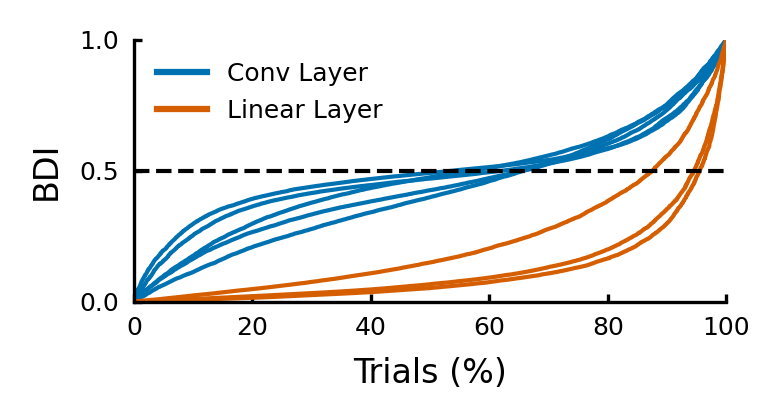

Saved: /content/drive/MyDrive/AlexNet_Images/ImageNet_alexnet_BDI_gt50_groupcolors_cbfriendly.eps
Saved: /content/drive/MyDrive/AlexNet_Images/ImageNet_alexnet_BDI_gt50_groupcolors_cbfriendly.png


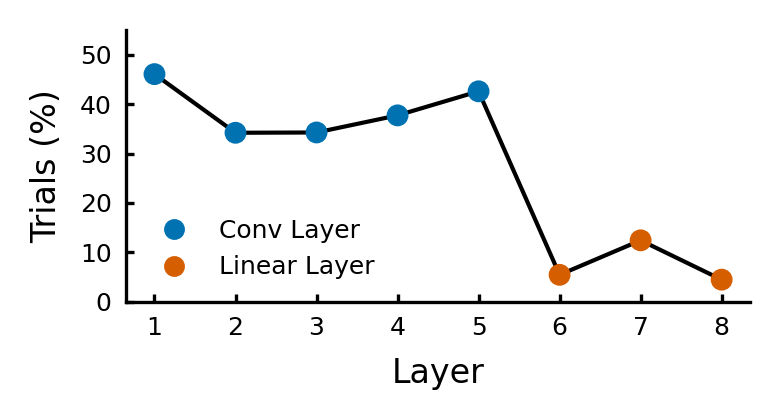

In [ ]:
# ============================================================
# Load CSV + reconstruct layerwise BDI + make both plots
# Features = one color, Classifiers = another color
# Color-blind friendly palette (Okabe-Ito style)
# Works for AlexNet and VGG-16
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
USE = "alexnet"      # options: "alexnet", "vgg16"
save_fig = True
out_dir = "/content/drive/MyDrive/AlexNet_Images"
save_dir = out_dir
os.makedirs(save_dir, exist_ok=True)

show_legend_layerwise = True
show_legend_pct = True
include_all_layers = False
sort_each_layer = True
n_show = 10000

# ------------------------------------------------------------
# Color-blind friendly group colors
# Okabe-Ito inspired palette
# ------------------------------------------------------------
FEATURE_COLOR = "#0072B2"      # blue
CLASSIFIER_COLOR = "#D55E00"   # vermillion/orange
OTHER_COLOR = "#7F7F7F"        # gray

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
mpl.set_loglevel("error")

# ------------------------------------------------------------
# Load CSV
# ------------------------------------------------------------
csv_path = os.path.join(
    out_dir,
    f"{USE}_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv"
)

if not os.path.isfile(csv_path):
    raise FileNotFoundError(f"CSV not found: {csv_path}")

df = pd.read_csv(csv_path)

print("Loaded:", csv_path)
print("Shape:", df.shape)
print("First columns:", df.columns[:15].tolist())

# ------------------------------------------------------------
# Core columns
# ------------------------------------------------------------
top1_col = "top1" if "top1" in df.columns else ("top1_idx" if "top1_idx" in df.columns else None)
top2_col = "top2" if "top2" in df.columns else ("top2_idx" if "top2_idx" in df.columns else None)
bdi_all_col = "bdi_all" if "bdi_all" in df.columns else ("bdi_all_layers" if "bdi_all_layers" in df.columns else None)

if bdi_all_col is None:
    raise ValueError("Could not find 'bdi_all' or 'bdi_all_layers'.")

bdi_all_np = df[bdi_all_col].to_numpy(dtype=np.float32)
top1_np = df[top1_col].to_numpy(dtype=np.int32) if top1_col is not None else None
top2_np = df[top2_col].to_numpy(dtype=np.int32) if top2_col is not None else None

# ------------------------------------------------------------
# Reconstruct layerwise BDI dictionary
# Supports:
#   <layer>__bdi
#   <layer>__bdi0, <layer>__bdi1, ...
#   bdi_<layer>
# ------------------------------------------------------------
bdi_layers_np = {}

# Case 1: "<layer>__bdi"
scalar_bdi_cols = [c for c in df.columns if c.endswith("__bdi")]

if len(scalar_bdi_cols) > 0:
    for c in scalar_bdi_cols:
        layer_name = c.replace("__bdi", "")
        bdi_layers_np[layer_name] = df[c].to_numpy(dtype=np.float32)

else:
    # Case 2: "<layer>__bdi0", "<layer>__bdi1", ...
    indexed_bdi_cols = [c for c in df.columns if re.search(r"__bdi\d+$", c)]

    if len(indexed_bdi_cols) > 0:
        prefixes = sorted(set(re.sub(r"__bdi\d+$", "", c) for c in indexed_bdi_cols))

        for pref in prefixes:
            cols_pref = [c for c in indexed_bdi_cols if re.sub(r"__bdi\d+$", "", c) == pref]
            cols_pref = sorted(
                cols_pref,
                key=lambda c: int(re.search(r"__bdi(\d+)$", c).group(1))
            )

            arr = df[cols_pref].to_numpy(dtype=np.float32)
            if arr.shape[1] == 1:
                arr = arr[:, 0]

            bdi_layers_np[pref] = arr

    else:
        # Case 3: "bdi_<layer>"
        old_bdi_cols = [
            c for c in df.columns
            if c.startswith("bdi_") and c not in ("bdi_all", "bdi_all_layers")
        ]

        if len(old_bdi_cols) == 0:
            raise ValueError(
                "Could not find any layerwise BDI columns.\n"
                "Expected '<layer>__bdi', '<layer>__bdi0', or 'bdi_<layer>'."
            )

        for c in old_bdi_cols:
            layer_name = c[len("bdi_"):]
            bdi_layers_np[layer_name] = df[c].to_numpy(dtype=np.float32)

print("Reconstructed:")
print("  bdi_all_np:", bdi_all_np.shape)
print("  top1_np:", None if top1_np is None else top1_np.shape)
print("  top2_np:", None if top2_np is None else top2_np.shape)
print("  N layerwise BDI arrays:", len(bdi_layers_np))
print("  First layers:", list(bdi_layers_np.keys())[:10])

# ------------------------------------------------------------
# Shared ordering for AlexNet / VGG-16
# ------------------------------------------------------------
def layer_sort_key(name: str):
    """
    Sort order:
      1) features.* (ascending index)
      2) classifier.* (ascending index)
      3) anything else (last)

    Handles:
      features.0, features_0
      classifier.6, classifier_6
      avgpool
    """
    s = str(name)
    s = re.sub(r"^bdi_", "", s)
    s = s.replace("__", ".").replace("_", ".")
    parts = s.split(".")
    prefix = parts[0] if len(parts) > 0 else s

    if prefix == "features":
        group = 0
    elif prefix == "avgpool":
        group = 1
    elif prefix == "classifier":
        group = 2
    else:
        group = 3

    m = re.search(r"(\d+)", s[len(prefix):]) if prefix in ("features", "classifier") else None
    idx = int(m.group(1)) if m else 10**9

    return (group, idx, s)

layer_names = sorted(bdi_layers_np.keys(), key=layer_sort_key)

print("\nLayer order:")
for i, name in enumerate(layer_names):
    print(f"{i:02d}: {name}")

# ------------------------------------------------------------
# Group colors: features vs classifier
# ------------------------------------------------------------
def layer_group(name: str):
    s = str(name)
    s = re.sub(r"^bdi_", "", s)
    s = s.replace("__", ".").replace("_", ".")
    prefix = s.split(".")[0] if len(s) > 0 else s

    if prefix == "features":
        return "features"
    elif prefix == "classifier":
        return "classifier"
    else:
        return "other"

def layer_group_color(name: str):
    g = layer_group(name)
    if g == "features":
        return FEATURE_COLOR
    elif g == "classifier":
        return CLASSIFIER_COLOR
    else:
        return OTHER_COLOR

layer_colors = {name: layer_group_color(name) for name in layer_names}
layer_color_list = [layer_colors[name] for name in layer_names]

N = len(layer_names)

# ============================================================
# Plot 1: Layer-resolved BDI curves
# ============================================================
fig, ax = plt.subplots(figsize=(2.7, 1.5), dpi=300)

for name in layer_names:
    bdi = np.asarray(bdi_layers_np[name]).reshape(-1)
    bdi = bdi[np.isfinite(bdi)]

    if bdi.size == 0:
        continue

    if sort_each_layer:
        bdi = np.sort(bdi)

    n = min(n_show, bdi.size)
    x = np.linspace(0, 100, n) if n > 1 else np.array([0.0])

    ax.plot(
        x,
        bdi[:n],
        linewidth=1,
        alpha=1,
        color=layer_colors[name],
        label=name
    )

if include_all_layers:
    bdi = np.asarray(bdi_all_np).reshape(-1)
    bdi = bdi[np.isfinite(bdi)]

    if sort_each_layer:
        bdi = np.sort(bdi)

    n = min(n_show, bdi.size)
    x = np.linspace(0, 100, n) if n > 1 else np.array([0.0])

    ax.plot(
        x,
        bdi[:n],
        linewidth=1.4,
        color="black",
        label="all_layers"
    )

ax.axhline(0.5, linestyle="--", color="black", linewidth=1)

ax.set_xlim(0, 100)
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}"))

ax.set_ylim(0, 1)
ax.set_yticks([0, 0.5, 1])

ax.set_xlabel("Trials (%)", fontsize=8)
ax.set_ylabel("BDI", fontsize=8)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.tick_params(
    axis="y",
    which="both",
    direction="in",
    left=True,
    right=False,
    length=2,
    labelsize=6
)
ax.tick_params(
    axis="x",
    which="both",
    direction="in",
    length=2,
    labelsize=6
)

if show_legend_layerwise:
    legend_handles = [
        Line2D([0], [0], color=FEATURE_COLOR, lw=1.5, label="Conv Layer"),
        Line2D([0], [0], color=CLASSIFIER_COLOR, lw=1.5, label="Linear Layer"),
    ]
    ax.legend(
        handles=legend_handles,
        fontsize=6,
        frameon=False,
        loc="upper left",
        # bbox_to_anchor=(1.02, 0.5)
    )

fig.tight_layout()

if save_fig:
    base = os.path.join(save_dir, f"ImageNet_{USE}_BDI_all_layers_groupcolors_cbfriendly")
    fig.savefig(base + ".eps", format="eps", bbox_inches="tight", pad_inches=0.02)
    fig.savefig(base + ".png", format="png", dpi=600, bbox_inches="tight", pad_inches=0.02)
    print("Saved:", base + ".eps")
    print("Saved:", base + ".png")

plt.show()

# ============================================================
# Plot 2: Percent trials with BDI > 0.5
# ============================================================
pct_gt05 = []

for name in layer_names:
    bdi = np.asarray(bdi_layers_np[name]).ravel()
    bdi = bdi[np.isfinite(bdi)]
    pct_gt05.append(100.0 * np.mean(bdi > 0.5) if bdi.size else np.nan)

pct_gt05 = np.asarray(pct_gt05, dtype=float)
x = np.arange(N)

fig_pct, ax_pct = plt.subplots(figsize=(2.7, 1.5), dpi=300)

# black line
ax_pct.plot(x, pct_gt05, linestyle='-', linewidth=1, color='black', zorder=1)

# colored dots
ax_pct.scatter(x, pct_gt05, c=layer_color_list, s=18, zorder=2)

ax_pct.set_ylim(0, 55)
ax_pct.set_yticks([0, 10, 20, 30, 40, 50])
ax_pct.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}"))

ax_pct.set_xlabel("Layer", fontsize=8)
ax_pct.set_ylabel("Trials (%)", fontsize=8)

ax_pct.set_xticks(x)
ax_pct.set_xticklabels([str(i) for i in range(1, N + 1)], fontsize=8)

ax_pct.spines['right'].set_visible(False)
ax_pct.spines['top'].set_visible(False)
ax_pct.tick_params(axis='y', which='both', direction='in', left=True, right=False, length=2, labelsize=6)
ax_pct.tick_params(axis='x', which='both', direction='in', length=2, labelsize=6)

if show_legend_pct:
    legend_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=FEATURE_COLOR,
            markeredgecolor=FEATURE_COLOR,
            markersize=4,
            label="Conv Layer"
        ),
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=CLASSIFIER_COLOR,
            markeredgecolor=CLASSIFIER_COLOR,
            markersize=4,
            label="Linear Layer"
        ),
    ]
    ax_pct.legend(
        handles=legend_handles,
        fontsize=6,
        frameon=False,
        loc="best"
    )

fig_pct.tight_layout()

if save_fig:
    base = os.path.join(save_dir, f"ImageNet_{USE}_BDI_gt50_groupcolors_cbfriendly")
    fig_pct.savefig(
        base + ".eps",
        format="eps",
        bbox_inches="tight",
        pad_inches=0.02
    )
    fig_pct.savefig(
        base + ".png",
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.02
    )
    print("Saved:", base + ".eps")
    print("Saved:", base + ".png")

plt.show()

## ViT-B/16 all-layer BDI on Tiny-ImageNet

This section uses the ViT BDI implementation that returns `C_evid`/`C_bias`, which is required by the retained ViT CSV writer.

In [ ]:
# -------------------------------------------------------
# Track ViT layers including LayerNorm (bias term = beta)
# -------------------------------------------------------
def _get_vit_track_layers(model: nn.Module,
                         include_conv=True,
                         include_linear=True,
                         include_layernorm=True):
    types = []
    if include_conv:
        types.append(nn.Conv2d)
    if include_linear:
        types.append(nn.Linear)
    if include_layernorm:
        types.append(nn.LayerNorm)

    return [(name, m) for name, m in model.named_modules() if isinstance(m, tuple(types))]


def _broadcast_bias(module: nn.Module, u: torch.Tensor) -> torch.Tensor:
    """
    Broadcasts module bias to match u.
    Supports:
      - Linear: (B,C) or (B,T,C)
      - Conv2d: (B,C,H,W)
      - LayerNorm: (B,T,C) or (B,C) or other shapes ending with normalized_shape
    """
    b = getattr(module, "bias", None)
    if b is None:
        return torch.zeros_like(u)

    if u.ndim == 2:        # (B, C)
        return b.view(1, -1).expand_as(u)
    if u.ndim == 3:        # (B, T, C)
        return b.view(1, 1, -1).expand_as(u)
    if u.ndim == 4:        # (B, C, H, W)
        return b.view(1, -1, 1, 1).expand_as(u)

    try:
        shape = [1] * u.ndim
        shape[-b.ndim:] = list(b.shape)
        return b.view(*shape).expand_as(u)
    except Exception:
        return torch.zeros_like(u)


@torch.enable_grad()
def layerwise_bdi_top1_top2_vit(model: nn.Module, x: torch.Tensor, layers=None, return_all_C: bool = True):
    """
    Computes layerwise BDI for margin = z_top1 - z_top2.

    Returns (if return_all_C=True):
      bdi_by_layer:      dict name -> (B,)
      bdi_all:           (B,)  (abs-sum aggregate)
      top1_idx:          (B,)
      top2_idx:          (B,)
      conf_top1:         (B,)  softmax prob of top-1
      conf_top2:         (B,)  softmax prob of top-2
      C_evid_by_layer:   dict name -> (B,) signed
      C_bias_by_layer:   dict name -> (B,) signed
      C_evid_all:        (B,) signed sum across layers
      C_bias_all:        (B,) signed sum across layers

    If return_all_C=False, the last two (C_*_all) are omitted.
    """
    model.eval()

    x = x.detach()
    x.requires_grad_(True)

    if layers is None:
        layers = _get_vit_track_layers(
            model,
            include_conv=True,
            include_linear=True,
            include_layernorm=True
        )

    store, hooks = {}, []

    def make_hook(layer_name, layer_module):
        def hook_fn(m, inp, out):
            if not torch.is_tensor(out):
                return
            u = out
            if not u.requires_grad:
                raise RuntimeError(
                    f"{layer_name} output has requires_grad=False. "
                    f"Set x.requires_grad_(True) and avoid torch.inference_mode()/no_grad()."
                )
            u.retain_grad()
            store[layer_name] = {"u": u, "u_bias": _broadcast_bias(layer_module, u)}
        return hook_fn

    for name, m in layers:
        hooks.append(m.register_forward_hook(make_hook(name, m)))

    try:
        z = model(x)  # logits (B,K)
        if z.ndim != 2 or z.shape[1] < 2:
            raise ValueError(f"Expected logits shape (B,K) with K>=2; got {tuple(z.shape)}")

        # --- top-1 / top-2 from logits ---
        top2 = torch.topk(z, k=2, dim=1).indices
        top1_idx, top2_idx = top2[:, 0], top2[:, 1]

        z_top1 = z.gather(1, top1_idx[:, None]).squeeze(1)
        z_top2 = z.gather(1, top2_idx[:, None]).squeeze(1)
        margin = z_top1 - z_top2  # (B,)

        # --- softmax confidence (prob of top-1/top-2 class) ---
        p = torch.softmax(z, dim=1)
        conf_top1 = p.gather(1, top1_idx[:, None]).squeeze(1).detach()  # (B,)
        conf_top2 = p.gather(1, top2_idx[:, None]).squeeze(1).detach()  # (B,)

        model.zero_grad(set_to_none=True)
        margin.sum().backward()

        bdi_by_layer = {}
        C_evid_by_layer = {}
        C_bias_by_layer = {}

        abs_bias_sum, abs_evid_sum = None, None
        C_bias_signed_sum, C_evid_signed_sum = None, None

        for name, _ in layers:
            if name not in store:
                continue

            u = store[name]["u"]
            u_bias = store[name]["u_bias"]
            g = u.grad
            if g is None:
                raise RuntimeError(f"{name}: u.grad is None (grad graph not built).")

            u_evid = u - u_bias
            dims = tuple(range(1, u.ndim))

            C_bias = (g * u_bias).sum(dim=dims)    # (B,) signed
            C_evid = (g * u_evid).sum(dim=dims)    # (B,) signed

            C_bias_by_layer[name] = C_bias.detach()
            C_evid_by_layer[name] = C_evid.detach()

            denom = C_bias.abs() + C_evid.abs()
            bdi_l = torch.where(
                denom > 0,
                C_bias.abs() / denom,
                torch.full_like(denom, 0.5)
            )
            bdi_by_layer[name] = bdi_l.detach()

            abs_bias_sum = C_bias.abs() if abs_bias_sum is None else abs_bias_sum + C_bias.abs()
            abs_evid_sum = C_evid.abs() if abs_evid_sum is None else abs_evid_sum + C_evid.abs()

            if return_all_C:
                C_bias_signed_sum = C_bias if C_bias_signed_sum is None else C_bias_signed_sum + C_bias
                C_evid_signed_sum = C_evid if C_evid_signed_sum is None else C_evid_signed_sum + C_evid

        denom_all = abs_bias_sum + abs_evid_sum
        bdi_all = torch.where(
            denom_all > 0,
            abs_bias_sum / denom_all,
            torch.full_like(denom_all, 0.5)
        ).detach()

        if return_all_C:
            return (
                bdi_by_layer,
                bdi_all,
                top1_idx.detach(),
                top2_idx.detach(),
                conf_top1,
                conf_top2,
                C_evid_by_layer,
                C_bias_by_layer,
                C_evid_signed_sum.detach(),
                C_bias_signed_sum.detach()
            )

        return (
            bdi_by_layer,
            bdi_all,
            top1_idx.detach(),
            top2_idx.detach(),
            conf_top1,
            conf_top2,
            C_evid_by_layer,
            C_bias_by_layer
        )

    finally:
        for h in hooks:
            h.remove()


In [ ]:
# ============================================================
# ViT-B/16 Tiny-ImageNet BDI extraction with visible progress
# Assumes imports are already done and
# layerwise_bdi_top1_top2_vit(model, x, return_all_C=True)
# is already defined.
# ============================================================

import gc
import time

USE = "vit_b16"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# Output directory
# ============================================================

out_dir = "/content/drive/MyDrive/AlexNet_Images"
save_dir = out_dir
os.makedirs(out_dir, exist_ok=True)

print("out_dir:", out_dir)


# ============================================================
# Download Tiny ImageNet if needed
# ============================================================

TINY_URLS = [
    "http://cs231n.stanford.edu/tiny-imagenet-200.zip",
    "https://cs231n.stanford.edu/tiny-imagenet-200.zip",
]

zip_path = "tiny-imagenet-200.zip"
extract_dir = "tiny-imagenet-200"


def _dl_progress(block_num, block_size, total_size):
    downloaded = block_num * block_size

    if total_size > 0:
        pct = 100.0 * downloaded / total_size
        mb = downloaded / (1024**2)
        total_mb = total_size / (1024**2)

        sys.stdout.write(
            f"\rDownloading: {pct:6.2f}%  ({mb:7.1f}/{total_mb:7.1f} MB)"
        )
        sys.stdout.flush()


if not os.path.isdir(extract_dir):
    if not os.path.isfile(zip_path):
        last_err = None

        for url in TINY_URLS:
            try:
                print("Downloading Tiny ImageNet-200 from:", url)
                urllib.request.urlretrieve(url, zip_path, reporthook=_dl_progress)
                print("\nDownloaded:", zip_path)
                break

            except Exception as e:
                last_err = e
                print("\nFailed from:", url, "->", repr(e))

        if not os.path.isfile(zip_path):
            raise RuntimeError(
                f"Could not download tiny-imagenet-200.zip. Last error: {last_err}"
            )

    print("Extracting Tiny ImageNet...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(".")

    print("Extracted to:", extract_dir)

else:
    print("Already extracted:", extract_dir)


# ============================================================
# Tiny ImageNet validation set
# ============================================================

val_img_dir = os.path.join(extract_dir, "val", "images")
val_anno = os.path.join(extract_dir, "val", "val_annotations.txt")

if not os.path.isdir(val_img_dir):
    raise FileNotFoundError(f"Not found: {val_img_dir}")

if not os.path.isfile(val_anno):
    raise FileNotFoundError(f"Not found: {val_anno}")


img_files = sorted(
    [
        f for f in os.listdir(val_img_dir)
        if f.lower().endswith((".jpeg", ".jpg", ".png"))
    ]
)

if len(img_files) == 0:
    raise RuntimeError(f"No image files found in {val_img_dir}")

print("Num validation images:", len(img_files))


# ============================================================
# Parse Tiny ImageNet labels
# ============================================================

fname2wnid = {}

with open(val_anno, "r") as f:
    for line in f:
        parts = line.strip().split("\t")

        if len(parts) >= 2:
            fname2wnid[parts[0]] = parts[1]

print("Num annotation entries:", len(fname2wnid))


# ============================================================
# ImageNet-1K WNID mapping
# ============================================================

IMAGENET_CLASS_INDEX_JSON = os.path.join(out_dir, "imagenet_class_index.json")


def ensure_imagenet_class_index_json(path=IMAGENET_CLASS_INDEX_JSON):
    if os.path.isfile(path) and os.path.getsize(path) > 0:
        return path

    url = "https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json"

    print("Downloading ImageNet class index:", url)
    urllib.request.urlretrieve(url, path)

    if not os.path.isfile(path) or os.path.getsize(path) == 0:
        raise RuntimeError("Failed to download imagenet_class_index.json")

    return path


def load_wnid2idx(json_path=IMAGENET_CLASS_INDEX_JSON):
    with open(json_path, "r") as f:
        j = json.load(f)

    return {v[0]: int(k) for k, v in j.items()}


ensure_imagenet_class_index_json()
WNID2IDX = load_wnid2idx()

print("Loaded ImageNet-1K WNID map:", len(WNID2IDX))


# Tiny ImageNet WNID -> 0..199 class index
wnids_txt = os.path.join(extract_dir, "wnids.txt")

wnid_list = []

if os.path.isfile(wnids_txt):
    with open(wnids_txt, "r") as f:
        wnid_list = [ln.strip() for ln in f if ln.strip()]

wnid2tiny = {w: i for i, w in enumerate(wnid_list)} if wnid_list else {}

print("Loaded Tiny ImageNet WNID map:", len(wnid2tiny))


# ============================================================
# Load ViT-B/16 and preprocessing
# ============================================================

weights = ViT_B_16_Weights.IMAGENET1K_V1
model = vit_b_16(weights=weights).to(device).eval()
preprocess = weights.transforms()

print("Loaded ViT-B/16.")


# ============================================================
# CSV settings
# ============================================================


PRINT_EVERY = 100

csv_path = os.path.join(
    out_dir,
    "vit_b16_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv"
)

# Set True to delete existing CSV and rerun from scratch.
OVERWRITE_CSV = False

# Use small value while debugging. Increase later if desired.
SAVE_EVERY = 100

# Optional cap for debugging.
# Set to None for all pending images.
MAX_IMAGES = None

if OVERWRITE_CSV and os.path.exists(csv_path):
    os.remove(csv_path)
    print("Removed existing CSV:", csv_path)


def _csv_append(path: str, header: list, rows: list):
    file_exists = os.path.exists(path) and os.path.getsize(path) > 0

    with open(path, "a", newline="") as f:
        w = csv.writer(f)

        if not file_exists:
            w.writerow(header)

        w.writerows(rows)


def _load_seen_fnames(path: str) -> set:
    if not (os.path.exists(path) and os.path.getsize(path) > 0):
        return set()

    seen = set()

    with open(path, "r", newline="") as f:
        r = csv.reader(f)
        header = next(r, None)

        if header is None:
            return set()

        try:
            idx = header.index("fname")
        except ValueError:
            idx = 0

        for row in r:
            if len(row) > idx:
                seen.add(row[idx])

    return seen


seen = _load_seen_fnames(csv_path)

img_files_set = set(img_files)
seen_in_dataset = seen.intersection(img_files_set)

pending_files = [fn for fn in img_files if fn not in seen]

if MAX_IMAGES is not None:
    pending_files = pending_files[:MAX_IMAGES]

print("CSV path:", csv_path)
print("Total validation images:", len(img_files))
print("Rows already seen in CSV:", len(seen))
print("Seen filenames matching current validation set:", len(seen_in_dataset))
print("Pending images to process:", len(pending_files))

if len(pending_files) == 0:
    print(
        "\nNo images are pending. "
        "The CSV may already contain all filenames. "
        "Set OVERWRITE_CSV=True to rerun from scratch."
    )


# ============================================================
# Adapter for BDI function
# ============================================================

def _call_bdi_with_conf_and_C(model, x):
    """
    Expected return from layerwise_bdi_top1_top2_vit(..., return_all_C=True):

      (
        bdi_by_layer,
        bdi_all,
        top1,
        top2,
        conf_top1,
        conf_top2,
        C_evid_by_layer,
        C_bias_by_layer,
        C_evid_all,
        C_bias_all
      )
    """
    out = layerwise_bdi_top1_top2_vit(model, x, return_all_C=True)

    if isinstance(out, tuple) and len(out) == 10:
        (
            bdi_by_layer,
            bdi_all,
            top1,
            top2,
            conf_top1,
            conf_top2,
            C_evid_by_layer,
            C_bias_by_layer,
            C_evid_all,
            C_bias_all,
        ) = out

        return (
            bdi_by_layer,
            bdi_all,
            top1,
            top2,
            conf_top1,
            conf_top2,
            C_evid_by_layer,
            C_bias_by_layer,
            C_evid_all,
            C_bias_all,
        )

    raise ValueError(
        "Unexpected return from layerwise_bdi_top1_top2_vit. "
        f"Got tuple length {len(out) if isinstance(out, tuple) else 'NA'}."
    )


# ============================================================
# Header inference
# ============================================================

def _infer_layers_and_header_from_existing_csv(csv_path: str):
    if not (os.path.exists(csv_path) and os.path.getsize(csv_path) > 0):
        return None, None

    with open(csv_path, "r", newline="") as f:
        r = csv.reader(f)
        existing_header = next(r, None)

    if not existing_header:
        return None, None

    layer_cols = [c for c in existing_header if c.endswith("__bdi")]

    if not layer_cols:
        return None, None

    layer_names = [c[:-5] for c in layer_cols]

    return layer_names, existing_header


def _make_header(layer_names):
    header = [
        "fname",
        "path",
        "wnid",
        "y_tiny",
        "y_im1k",
        "top1",
        "top2",
        "conf_top1",
        "conf_top2",
        "correct",
        "bdi_all",
        "C_evid_all",
        "C_bias_all",
    ]

    header += [f"{k}__bdi" for k in layer_names]
    header += [f"{k}__Cevid" for k in layer_names]
    header += [f"{k}__Cbias" for k in layer_names]

    return header


def _probe_layers_and_header():
    """
    Uses existing CSV header if present.
    Otherwise probes exactly one pending image.
    """
    layer_names0, header0 = _infer_layers_and_header_from_existing_csv(csv_path)

    if header0 is not None:
        print("Using existing CSV header.")
        print("N layers from header:", len(layer_names0))
        print("First 10 layers:", layer_names0[:10])
        return layer_names0, header0

    if len(pending_files) == 0:
        raise RuntimeError(
            "No pending files available for probing. "
            "Set OVERWRITE_CSV=True or delete the existing CSV."
        )

    probe_fn = pending_files[0]
    probe_path = os.path.join(val_img_dir, probe_fn)

    print("Probing ViT BDI function using:", probe_fn)

    pil = Image.open(probe_path).convert("RGB")
    x = preprocess(pil).unsqueeze(0).to(device)

    (
        bdi_by_layer,
        bdi_all,
        top1,
        top2,
        conf_top1,
        conf_top2,
        C_evid_by_layer,
        C_bias_by_layer,
        C_evid_all,
        C_bias_all,
    ) = _call_bdi_with_conf_and_C(model, x)

    layer_names = list(bdi_by_layer.keys())
    header = _make_header(layer_names)

    print("Probe successful.")
    print("N tracked layers:", len(layer_names))
    print("First 10 layers:", layer_names[:10])
    print("Probe top1:", int(top1.item()))
    print("Probe conf_top1:", float(conf_top1.item()))
    print("Probe bdi_all:", float(bdi_all.item()))

    del x
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return layer_names, header


layer_names, header = _probe_layers_and_header()


# ============================================================
# Header sanity check
# ============================================================

if os.path.exists(csv_path) and os.path.getsize(csv_path) > 0:
    with open(csv_path, "r", newline="") as f:
        r = csv.reader(f)
        existing_header = next(r, None)

    if existing_header is not None and existing_header != header:
        raise RuntimeError(
            "Existing CSV header does not match current model/layer hooks.\n"
            "Delete the CSV, set OVERWRITE_CSV=True, or write to a new CSV file.\n"
            f"Existing cols: {len(existing_header)} | New cols: {len(header)}"
        )


# ============================================================
# Single-image test before main loop
# ============================================================

def run_one(fn: str):
    path = os.path.join(val_img_dir, fn)

    pil_image = Image.open(path).convert("RGB")
    x = preprocess(pil_image).unsqueeze(0).to(device)

    result = _call_bdi_with_conf_and_C(model, x)

    del x

    return result, path


if len(pending_files) > 0:
    test_fn = pending_files[0]
else:
    test_fn = img_files[0]

print("\nTesting one image:", test_fn)

t0 = time.time()

test_out, test_path = run_one(test_fn)

(
    test_bdi_by_layer,
    test_bdi_all,
    test_top1,
    test_top2,
    test_conf_top1,
    test_conf_top2,
    test_C_evid_by_layer,
    test_C_bias_by_layer,
    test_C_evid_all,
    test_C_bias_all,
) = test_out

dt = time.time() - t0

print("Single-image test successful.")
print("Path:", test_path)
print("Top1:", int(test_top1.item()))
print("Top2:", int(test_top2.item()))
print("Conf top1:", float(test_conf_top1.item()))
print("BDI all:", float(test_bdi_all.item()))
print("N layers:", len(test_bdi_by_layer))
print(f"Single-image runtime: {dt:.2f} seconds")

del test_out
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ============================================================
# Main loop: print only every 100 images
# ============================================================

chunk_rows = []
chunk_fnames = []
chunk_count = 0

n_new = 0
n_failed = 0


def flush(verbose=False):
    global chunk_rows, chunk_fnames, chunk_count, seen

    if chunk_count == 0:
        return

    _csv_append(csv_path, header, chunk_rows)

    for fn in chunk_fnames:
        seen.add(fn)

    if verbose:
        print(
            f"Flushed {chunk_count} images | "
            f"new this run: {n_new} | "
            f"failed: {n_failed} | "
            f"total seen: {len(seen)}",
            flush=True
        )

    chunk_rows = []
    chunk_fnames = []
    chunk_count = 0


total_pending = len(pending_files)

print("\nStarting main loop.")
print("Pending images:", total_pending)
print("SAVE_EVERY:", SAVE_EVERY)
print("PRINT_EVERY:", PRINT_EVERY)

if total_pending == 0:
    print("Nothing to process.")

else:
    for local_i, fn in enumerate(pending_files, start=1):

        if fn not in fname2wnid:
            n_failed += 1
            continue

        wnid = fname2wnid[fn]
        y_tiny = wnid2tiny.get(wnid, -1)
        y_im1k = WNID2IDX.get(wnid, -1)

        try:
            (
                bdi_by_layer,
                bdi_all,
                top1,
                top2,
                conf_top1,
                conf_top2,
                C_evid_by_layer,
                C_bias_by_layer,
                C_evid_all,
                C_bias_all,
            ), path = run_one(fn)

        except Exception:
            n_failed += 1
            continue

        correct = int((y_im1k >= 0) and (int(top1.item()) == int(y_im1k)))

        row = [
            fn,
            path,
            wnid,
            int(y_tiny),
            int(y_im1k),
            int(top1.item()),
            int(top2.item()),
            float(conf_top1.item()),
            float(conf_top2.item()),
            correct,
            float(bdi_all.item()),
            float(C_evid_all.item()),
            float(C_bias_all.item()),
        ]

        # Per-layer BDI
        for k in layer_names:
            v = bdi_by_layer.get(k, None)
            row.append(float(v.item()) if v is not None else np.nan)

        # Per-layer evidence contribution
        for k in layer_names:
            v = C_evid_by_layer.get(k, None)
            row.append(float(v.item()) if v is not None else np.nan)

        # Per-layer bias contribution
        for k in layer_names:
            v = C_bias_by_layer.get(k, None)
            row.append(float(v.item()) if v is not None else np.nan)

        chunk_rows.append(row)
        chunk_fnames.append(fn)

        chunk_count += 1
        n_new += 1

        # Cleanup without printing
        del (
            bdi_by_layer,
            bdi_all,
            top1,
            top2,
            conf_top1,
            conf_top2,
            C_evid_by_layer,
            C_bias_by_layer,
            C_evid_all,
            C_bias_all,
        )

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        # Save every 100 images
        if chunk_count >= SAVE_EVERY:
            flush(verbose=False)

        # Print only every 100 attempted images
        if local_i % PRINT_EVERY == 0:
            print(
                f"[{local_i}/{total_pending}] "
                f"processed={n_new} | failed={n_failed} | total seen={len(seen)}",
                flush=True
            )

    # Final save and final print
    flush(verbose=False)

print("\nDone.")
print("Newly processed:", n_new)
print("Failed:", n_failed)
print("Total seen now:", len(seen))
print("CSV saved to:", csv_path)

device: cpu
out_dir: /content/drive/MyDrive/AlexNet_Images
Already extracted: tiny-imagenet-200
Num validation images: 10000
Num annotation entries: 10000
Loaded ImageNet-1K WNID map: 1000
Loaded Tiny ImageNet WNID map: 200
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:00<00:00, 389MB/s]


Loaded ViT-B/16.
CSV path: /content/drive/MyDrive/AlexNet_Images/vit_b16_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv
Total validation images: 10000
Rows already seen in CSV: 10000
Seen filenames matching current validation set: 10000
Pending images to process: 0

No images are pending. The CSV may already contain all filenames. Set OVERWRITE_CSV=True to rerun from scratch.
Using existing CSV header.
N layers from header: 51
First 10 layers: ['conv_proj', 'encoder.layers.encoder_layer_0.ln_1', 'encoder.layers.encoder_layer_0.ln_2', 'encoder.layers.encoder_layer_0.mlp.0', 'encoder.layers.encoder_layer_0.mlp.3', 'encoder.layers.encoder_layer_1.ln_1', 'encoder.layers.encoder_layer_1.ln_2', 'encoder.layers.encoder_layer_1.mlp.0', 'encoder.layers.encoder_layer_1.mlp.3', 'encoder.layers.encoder_layer_2.ln_1']

Testing one image: val_0.JPEG
Single-image test successful.
Path: tiny-imagenet-200/val/images/val_0.JPEG
Top1: 573
Top2: 830
Conf top1: 0.6926537752151489
BDI all: 0.25195848

Using last-layer BDI column: heads.head__bdi
Using last-layer C_evid column: heads.head__Cevid
Rows: 10000 | Finite points: 10000 | Acc (finite): 0.5190
Saved: /content/drive/MyDrive/AlexNet_Images/vit_b16_scatter_lastlayerCevid_vs_lastlayerBDI_Match.eps


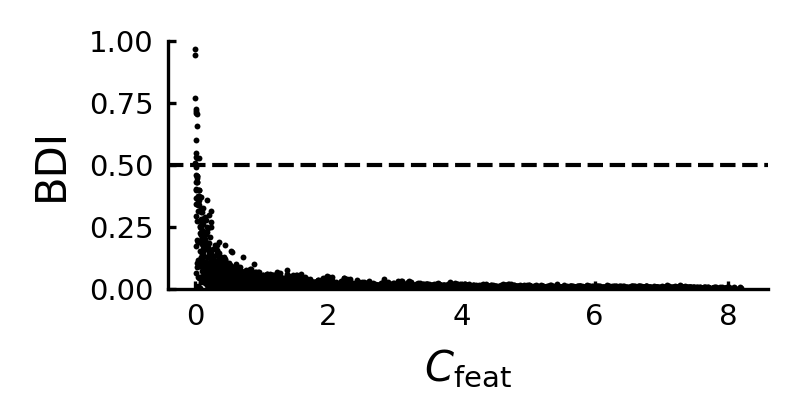

In [ ]:
# -----------------------
# ViT plots
# -----------------------
USE = "vit_b16"
save_dir = "/content/drive/MyDrive/AlexNet_Images"
out_dir = save_dir
csv_path = os.path.join(out_dir, f"{USE}_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv")

CORRECT = True
save_fig = True
CORRECT_COL = "correct"   # expects 0/1 in CSV


# -----------------------
# Load
# -----------------------
df = pd.read_csv(csv_path)

if CORRECT_COL not in df.columns:
    raise ValueError(f"Missing '{CORRECT_COL}' in CSV. Available: {df.columns.tolist()}")

# -----------------------
# Pick "last layer" BDI column automatically (endswith __bdi)
# -----------------------
bdi_cols = [c for c in df.columns if c.endswith("__bdi")]
if len(bdi_cols) == 0:
    raise ValueError("No layerwise BDI columns found (expected columns ending with '__bdi').")

# prioritize head/classifier-like names; else take last after sorting
head_like = [c for c in bdi_cols if re.search(r"(?:^|__)heads?\.?head|head|classifier", c, flags=re.IGNORECASE)]
BDI_COL = head_like[-1] if len(head_like) > 0 else bdi_cols[-1]
print("Using last-layer BDI column:", BDI_COL)

# -----------------------
# Pick "last layer" C_evid column automatically (endswith __Cevid)
# -----------------------
cevid_cols = [c for c in df.columns if c.endswith("__Cevid")]
if len(cevid_cols) == 0:
    # fallback: aggregated column if present
    if "C_evid_all" in df.columns:
        CEVID_COL = "C_evid_all"
        print("No per-layer __Cevid columns found; using:", CEVID_COL)
    else:
        raise ValueError(
            "No C_evid columns found. Expected per-layer columns ending with '__Cevid' "
            "or a 'C_evid_all' column."
        )
else:
    head_like_c = [c for c in cevid_cols if re.search(r"(?:^|__)heads?\.?head|head|classifier", c, flags=re.IGNORECASE)]
    CEVID_COL = head_like_c[-1] if len(head_like_c) > 0 else cevid_cols[-1]
    print("Using last-layer C_evid column:", CEVID_COL)

# -----------------------
# Extract + clean
# X = C_evid(last layer)
# Y = BDI(last layer)
# -----------------------
x = pd.to_numeric(df[CEVID_COL], errors="coerce").to_numpy(float)
y = pd.to_numeric(df[BDI_COL], errors="coerce").to_numpy(float)
c = pd.to_numeric(df[CORRECT_COL], errors="coerce").to_numpy(float)

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(c)
x, y, c = x[mask], y[mask], c[mask].astype(int)

m_ok  = (c == 1)
m_bad = (c == 0)

print(f"Rows: {len(df)} | Finite points: {mask.sum()} | Acc (finite): {m_ok.mean():.4f}")

# -----------------------------------------
# Plot: last-layer BDI vs last-layer C_evid
# correct = black, incorrect = gray
# -----------------------------------------
fig, ax = plt.subplots(figsize=(2.7, 1.5), dpi=300)

if CORRECT:
    ax.scatter(abs(x[m_ok]),  y[m_ok],  s=2, color="black", alpha=1.0, linewidths=0, rasterized=True)
else:
    ax.scatter(abs(x[m_bad]), y[m_bad], s=2, color="gray", alpha=1.0, linewidths=0, rasterized=True)

# ax.scatter(x[m_ok],  y[m_ok],  s=2, color="black", alpha=1.0, linewidths=0, rasterized=True)
# ax.scatter(x[m_bad], y[m_bad], s=2, color="gray", alpha=1.0, linewidths=0, rasterized=True)

# optional reference line for BDI
ax.axhline(0.5, linestyle="--", color="black", linewidth=1)

# axis limits
# BDI is in [0,1]
ax.set_ylim(0, 1)

# C_evid can be wide; let it autoscale unless you want to clamp it
# ax.set_xlim(-200, 200)

ax.set_xlabel(r"$C_{\mathrm{feat}}$", fontsize=10)
ax.set_ylabel("BDI", fontsize=10)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.tick_params(axis="both", which="both", direction="in", length=2, labelsize=7)

fig.tight_layout()

if save_fig:
   if CORRECT:
      outpath = os.path.join(save_dir, f"{USE}_scatter_lastlayerCevid_vs_lastlayerBDI_Match.eps")
      fig.savefig(outpath, format="eps", bbox_inches="tight", pad_inches=0.02)
      print("Saved:", outpath)
   else:
      outpath = os.path.join(save_dir, f"{USE}_scatter_lastlayerCevid_vs_lastlayerBDI_Mismatch.eps")
      fig.savefig(outpath, format="eps", bbox_inches="tight", pad_inches=0.02)
      print("Saved:", outpath)


plt.show()


Using last-layer BDI column: heads.head__bdi
Rows: 10000 | Finite points: 10000 | Acc (finite): 0.5190
Saved: /content/drive/MyDrive/AlexNet_Images/vit_b16_scatter_conf_vs_lastlayerBDI_with_binned_summary.eps


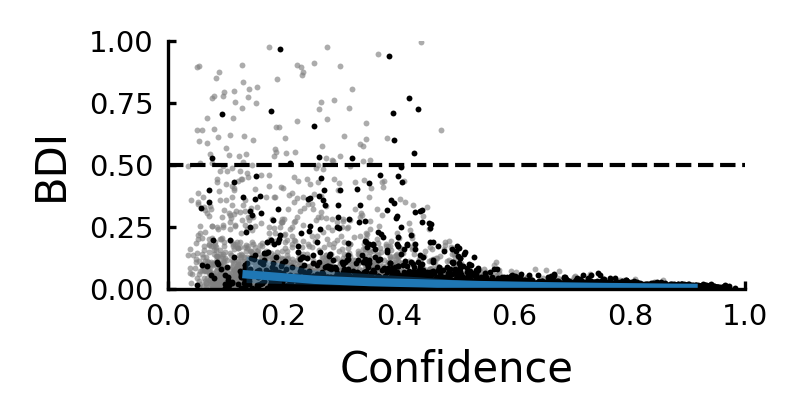

Binned summary kept 10 bins (method=quantile, nbins=10, min_per_bin=25)


In [ ]:
# -----------------------
# Config
# -----------------------
USE = "vit_b16"
save_dir = "/content/drive/MyDrive/AlexNet_Images"
out_dir = save_dir
csv_path = os.path.join(out_dir, f"{USE}_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv")  # adjust if needed

CONF_COL = "conf_top1"
CORRECT_COL = "correct"   # expects 0/1 in CSV
save_fig = True

# ---- binned summary params ----
NBINS = 10                 # 5–10 works well for a compact Fig 5A-style overlay
BINNING = "quantile"       # "quantile" (equal counts) or "uniform" (equal width)
SHOW_IQR = True            # median + IQR band
MIN_PER_BIN = 25           # skip bins with too few points

# -----------------------
# Load
# -----------------------
df = pd.read_csv(csv_path)

for col in [CONF_COL, CORRECT_COL]:
    if col not in df.columns:
        raise ValueError(f"Missing '{col}' in CSV. Available: {df.columns.tolist()}")

# -----------------------
# Pick "last layer (classifier)" BDI column automatically
# -----------------------
bdi_cols = [c for c in df.columns if c.endswith("__bdi")]
if len(bdi_cols) == 0:
    raise ValueError("No layerwise BDI columns found (expected columns ending with '__bdi').")

head_like = [c for c in bdi_cols if re.search(r"(?:^|__)heads?\.?head|head|classifier", c, flags=re.IGNORECASE)]
BDI_COL = head_like[-1] if len(head_like) > 0 else bdi_cols[-1]
print("Using last-layer BDI column:", BDI_COL)

# -----------------------
# Extract + clean
# -----------------------
x = pd.to_numeric(df[CONF_COL], errors="coerce").to_numpy(float)
y = pd.to_numeric(df[BDI_COL], errors="coerce").to_numpy(float)
c = pd.to_numeric(df[CORRECT_COL], errors="coerce").to_numpy(float)

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(c)
x, y, c = x[mask], y[mask], c[mask].astype(int)

m_ok  = (c == 1)
m_bad = (c == 0)

print(f"Rows: {len(df)} | Finite points: {mask.sum()} | Acc (finite): {m_ok.mean():.4f}")

# -----------------------
# Helper: binned summaries of BDI vs confidence
# -----------------------
def binned_summary(xv, yv, nbins=10, method="quantile", min_per_bin=10):
    xv = np.asarray(xv)
    yv = np.asarray(yv)

    if method == "quantile":
        edges = np.quantile(xv, np.linspace(0, 1, nbins + 1))
        edges = np.unique(edges)
        if edges.size < 3:
            raise ValueError("Quantile bin edges collapsed. Try uniform binning or fewer bins.")
    elif method == "uniform":
        edges = np.linspace(0.0, 1.0, nbins + 1)
    else:
        raise ValueError("method must be 'quantile' or 'uniform'")

    idx = np.digitize(xv, edges, right=False) - 1
    idx = np.clip(idx, 0, len(edges) - 2)

    xc, med, q25, q75, n = [], [], [], [], []
    for b in range(len(edges) - 1):
        sel = (idx == b)
        if sel.sum() < min_per_bin:
            continue
        xb = xv[sel]
        yb = yv[sel]
        xc.append(np.median(xb))         # x-position as median confidence in bin
        med.append(np.median(yb))
        q25.append(np.quantile(yb, 0.25))
        q75.append(np.quantile(yb, 0.75))
        n.append(sel.sum())

    return np.array(xc), np.array(med), np.array(q25), np.array(q75), np.array(n)

xc, med, q25, q75, nbin = binned_summary(x, y, nbins=NBINS, method=BINNING, min_per_bin=MIN_PER_BIN)

# -----------------------
# Plot: last-layer BDI vs top-1 confidence
# correct = black, incorrect = gray, plus binned median + IQR overlay
# -----------------------
fig, ax = plt.subplots(figsize=(2.7, 1.5), dpi=300)

# Scatter
if np.any(m_bad):
    ax.scatter(x[m_bad], y[m_bad], s=2, color="gray", alpha=0.65, linewidths=0, rasterized=True)
if np.any(m_ok):
    ax.scatter(x[m_ok],  y[m_ok],  s=2, color="black", alpha=1.0, linewidths=0, rasterized=True)

# Binned overlay
if xc.size:
    if SHOW_IQR:
        ax.fill_between(xc, q25, q75, alpha=0.30, linewidth=0)  # adjust alpha if desired
    ax.plot(xc, med, linewidth=2.0)

ax.axhline(0.5, linestyle="--", color="black", linewidth=1)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.set_xlabel("Confidence", fontsize=10)
ax.set_ylabel("BDI", fontsize=10)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.tick_params(axis="both", which="both", direction="in", length=2, labelsize=7)

fig.tight_layout()

if save_fig:
    outpath = os.path.join(save_dir, f"{USE}_scatter_conf_vs_lastlayerBDI_with_binned_summary.eps")
    fig.savefig(outpath, format="eps", bbox_inches="tight", pad_inches=0.02)
    print("Saved:", outpath)

plt.show()
print(f"Binned summary kept {xc.size} bins (method={BINNING}, nbins={NBINS}, min_per_bin={MIN_PER_BIN})")


Loaded: /content/drive/MyDrive/AlexNet_Images/vit_b16_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv shape: (10000, 166)
N layer prefixes: 51
Layer order:
00: conv_proj
01: encoder.layers.encoder_layer_0.ln_1
02: encoder.layers.encoder_layer_0.ln_2
03: encoder.layers.encoder_layer_0.mlp.0
04: encoder.layers.encoder_layer_0.mlp.3
05: encoder.layers.encoder_layer_1.ln_1
06: encoder.layers.encoder_layer_1.ln_2
07: encoder.layers.encoder_layer_1.mlp.0
08: encoder.layers.encoder_layer_1.mlp.3
09: encoder.layers.encoder_layer_2.ln_1
10: encoder.layers.encoder_layer_2.ln_2
11: encoder.layers.encoder_layer_2.mlp.0
12: encoder.layers.encoder_layer_2.mlp.3
13: encoder.layers.encoder_layer_3.ln_1
14: encoder.layers.encoder_layer_3.ln_2
...


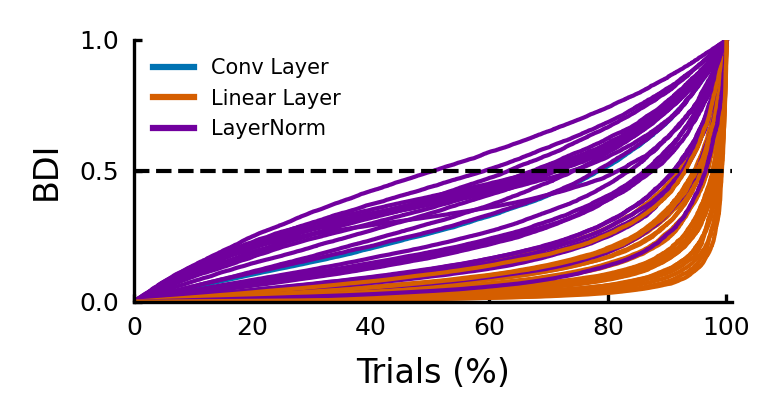

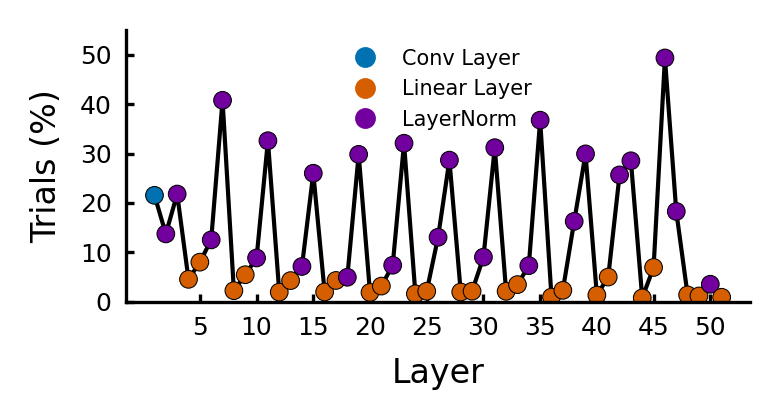

Average BDI by type:
  Conv     : mean=0.3180  SEM=0.0024  (layers=1)
  Linear   : mean=0.0879  SEM=0.0003  (layers=25)
  LayerNorm: mean=0.3098  SEM=0.0004  (layers=25)
Other layers excluded from type-summary plot: 0


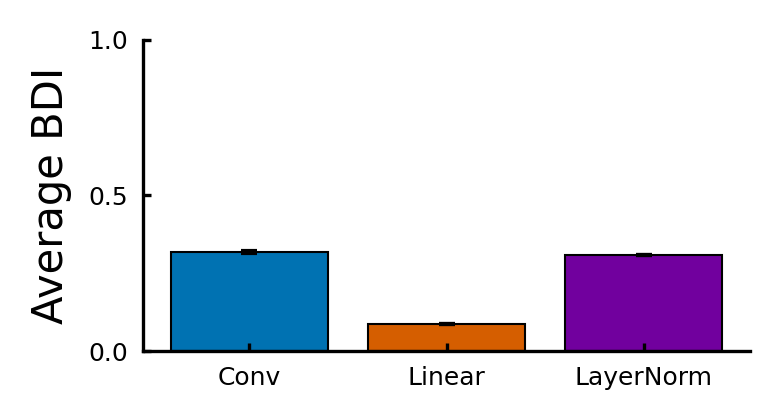

In [ ]:
# ============================================================
# ViT-B/16
# Load CSV -> reconstruct per-layer BDI -> make:
#   1) layerwise BDI plot
#   2) percent trials with BDI > 0.5 by layer
#   3) average BDI by layer type
#
# Color-blind friendly grouping:
#   Conv / patch projection = blue
#   Linear / attention / MLP / head = orange
#   LayerNorm = green
#
# Unmatched layers are plotted gray but are not shown in legends
# and are not included in the layer-type bar plot.
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
USE = "vit_b16"
out_dir = "/content/drive/MyDrive/AlexNet_Images"
save_dir = out_dir
os.makedirs(save_dir, exist_ok=True)

save_fig = True
sort_each_layer = True
include_all_layers = False
n_show = 10000

show_legend_layerwise = True
show_legend_pct = True

# ------------------------------------------------------------
# Color-blind friendly colors
# Okabe-Ito style palette
# ------------------------------------------------------------
CONV_COLOR = "#0072B2"       # blue
LINEAR_COLOR = "#D55E00"     # vermillion/orange
LAYERNORM_COLOR = "#71009e"


mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
mpl.set_loglevel("error")

# ------------------------------------------------------------
# Load CSV
# ------------------------------------------------------------
csv_path = os.path.join(
    out_dir,
    f"{USE}_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv"
)

# For local ImageNet subset, use instead:
# csv_path = os.path.join(
#     out_dir,
#     f"{USE}_local_imagenet500_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv"
# )

if not os.path.isfile(csv_path):
    raise FileNotFoundError(f"CSV not found: {csv_path}")

df = pd.read_csv(csv_path)
print("Loaded:", csv_path, "shape:", df.shape)

# ------------------------------------------------------------
# Identify core columns
# ------------------------------------------------------------
top1_col = "top1" if "top1" in df.columns else ("top1_idx" if "top1_idx" in df.columns else None)
top2_col = "top2" if "top2" in df.columns else ("top2_idx" if "top2_idx" in df.columns else None)
bdi_all_col = "bdi_all" if "bdi_all" in df.columns else ("bdi_all_layers" if "bdi_all_layers" in df.columns else None)

if top1_col is None or top2_col is None or bdi_all_col is None:
    raise ValueError(f"Missing required columns. Found: {df.columns.tolist()[:50]}")

core_cols = {"fname", "img_path", "path", top1_col, top2_col, bdi_all_col}

# ------------------------------------------------------------
# Collect per-layer BDI columns
# Supports:
#   <layer>__bdi
#   <layer>__bdi0, <layer>__bdi1, ...
#   bdi_<layer>
# ------------------------------------------------------------
bdi_pat = re.compile(r"^(?P<prefix>.+)__bdi(?P<idx>\d*)$")

col_info = []  # (prefix, idx, colname)

for c in df.columns:
    if c in core_cols:
        continue

    m = bdi_pat.match(c)
    if m:
        idx_str = m.group("idx")
        idx = int(idx_str) if idx_str != "" else 0
        col_info.append((m.group("prefix"), idx, c))

# fallback: older naming
if len(col_info) == 0:
    for c in df.columns:
        if c.startswith("bdi_") and c not in ("bdi_all", "bdi_all_layers"):
            col_info.append((c[len("bdi_"):], 0, c))

if len(col_info) == 0:
    raise ValueError("No per-layer BDI columns found. Expected <layer>__bdi* or bdi_<layer>.")

prefixes = sorted(set(p for p, _, _ in col_info))
print("N layer prefixes:", len(prefixes))

def _bdi_idx(colname: str) -> int:
    m = bdi_pat.match(colname)
    if not m:
        return 0
    s = m.group("idx")
    return int(s) if s != "" else 0

# ------------------------------------------------------------
# Build per-layer BDI arrays
# If a layer has multiple __bdi* columns, average them per trial
# ------------------------------------------------------------
bdi_layers_np = {}

for pfx in prefixes:
    cols = [c for (pp, _, c) in col_info if pp == pfx]
    cols = sorted(cols, key=_bdi_idx)

    A = df[cols].to_numpy(dtype=float)          # (N, K)
    bdi_layers_np[pfx] = np.nanmean(A, axis=1)  # (N,)

bdi_all_np = df[bdi_all_col].to_numpy(dtype=np.float32)

# ------------------------------------------------------------
# Sort ViT layers in approximate architectural order
# ------------------------------------------------------------
def vit_sort_key(name: str):
    s = str(name).replace(".", "_").lower()

    # patch embedding / conv_proj first
    if re.search(r"(patch|embed|conv_proj|embeddings)", s):
        return (0, 0, 0, s)

    # encoder blocks
    m = re.search(r"(encoder_layer|layer|layers|blocks)_(\d+)", s)
    if m:
        block_idx = int(m.group(2))

        if re.search(r"(^|_)ln_?1($|_)", s):
            subrank = 0
        elif "self_attention" in s or "attention" in s or "attn" in s:
            subrank = 1
        elif re.search(r"(^|_)ln_?2($|_)", s):
            subrank = 2
        elif "mlp" in s:
            m2 = re.search(r"mlp_(\d+)", s)
            mlp_idx = int(m2.group(1)) if m2 else 99
            subrank = 3 + mlp_idx
        else:
            subrank = 99

        return (1, block_idx, subrank, s)

    # final norm
    if re.search(r"(encoder_ln|encoder_norm|(^|_)ln($|_)|layernorm|norm)", s):
        return (2, 0, 0, s)

    # head / classifier last
    if re.search(r"(head|classifier|fc)", s):
        return (3, 0, 0, s)

    return (9, 0, 0, s)

layer_names = sorted(bdi_layers_np.keys(), key=vit_sort_key)

print("Layer order:")
for i, name in enumerate(layer_names[:15]):
    print(f"{i:02d}: {name}")
if len(layer_names) > 15:
    print("...")

# ------------------------------------------------------------
# Layer type classification and colors
# ------------------------------------------------------------
def layer_type(prefix: str) -> str:
    s = prefix.lower().replace(".", "_")

    # LayerNorm first, because names may also include encoder/layer
    if (
        "layernorm" in s
        or re.search(r"(^|_)ln(_|$)", s)
        or re.search(r"(^|_)ln_?\d+($|_)", s)
        or ("norm" in s and "conv" not in s)
    ):
        return "LayerNorm"

    # Conv / patch embedding
    if (
        "conv" in s
        or "conv_proj" in s
        or "patch_embed" in s
        or "embed" in s
        or "embedding" in s
    ):
        return "Conv"

    # Linear / MLP / attention projections / head
    if (
        "linear" in s
        or "mlp" in s
        or "head" in s
        or "classifier" in s
        or "fc" in s
        or "attention" in s
        or "attn" in s
        or "out_proj" in s
        or "q_proj" in s
        or "k_proj" in s
        or "v_proj" in s
    ):
        return "Linear"

    return "Other"

def layer_type_color(prefix: str) -> str:
    t = layer_type(prefix)

    if t == "Conv":
        return CONV_COLOR
    if t == "Linear":
        return LINEAR_COLOR
    if t == "LayerNorm":
        return LAYERNORM_COLOR

    return OTHER_COLOR

layer_colors = {name: layer_type_color(name) for name in layer_names}
layer_color_list = [layer_colors[name] for name in layer_names]

N = len(layer_names)

# No "Other" label in legends
legend_line_handles = [
    Line2D([0], [0], color=CONV_COLOR, lw=1.5, label="Conv Layer"),
    Line2D([0], [0], color=LINEAR_COLOR, lw=1.5, label="Linear Layer"),
    Line2D([0], [0], color=LAYERNORM_COLOR, lw=1.5, label="LayerNorm"),
]

legend_dot_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor=CONV_COLOR,
        markeredgecolor=CONV_COLOR,
        markersize=4,
        label="Conv Layer"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor=LINEAR_COLOR,
        markeredgecolor=LINEAR_COLOR,
        markersize=4,
        label="Linear Layer"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor=LAYERNORM_COLOR,
        markeredgecolor=LAYERNORM_COLOR,
        markersize=4,
        label="LayerNorm"
    ),
]

# ============================================================
# Plot 1: Layerwise BDI curves
# ============================================================
fig, ax = plt.subplots(figsize=(2.7, 1.5), dpi=300)

for name in layer_names:
    bdi = np.asarray(bdi_layers_np[name]).reshape(-1)
    bdi = bdi[np.isfinite(bdi)]

    if bdi.size == 0:
        continue

    if sort_each_layer:
        bdi = np.sort(bdi)

    n = min(n_show, bdi.size)
    x = np.linspace(0, 100, n) if n > 1 else np.array([0.0])

    ax.plot(
        x,
        bdi[:n],
        linewidth=1,
        alpha=1,
        color=layer_colors[name],
        label=name
    )

if include_all_layers:
    bdi = np.asarray(bdi_all_np).reshape(-1)
    bdi = bdi[np.isfinite(bdi)]

    if sort_each_layer:
        bdi = np.sort(bdi)

    n = min(n_show, bdi.size)
    x = np.linspace(0, 100, n) if n > 1 else np.array([0.0])

    ax.plot(
        x,
        bdi[:n],
        linewidth=1.4,
        color="black",
        label="all_layers"
    )

ax.axhline(0.5, linestyle="--", color="black", linewidth=1)

ax.set_xlim(0, 101)
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}"))

ax.set_ylim(0, 1)
ax.set_yticks([0, 0.5, 1])

ax.set_xlabel("Trials (%)", fontsize=8)
ax.set_ylabel("BDI", fontsize=8)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.tick_params(
    axis="y",
    which="both",
    direction="in",
    left=True,
    right=False,
    length=2,
    labelsize=6
)

ax.tick_params(
    axis="x",
    which="both",
    direction="in",
    length=2,
    labelsize=6
)

if show_legend_layerwise:
    ax.legend(
        handles=legend_line_handles,
        fontsize=5,
        frameon=False,
        loc="upper left",
        # bbox_to_anchor=(1.02, 0.5)
    )

fig.tight_layout()

if save_fig:
    fig.savefig(
        os.path.join(save_dir, f"{USE}_BDI_all_layers_typecolors_cbfriendly.eps"),
        format="eps",
        bbox_inches="tight",
        pad_inches=0.02
    )
    fig.savefig(
        os.path.join(save_dir, f"{USE}_BDI_all_layers_typecolors_cbfriendly.png"),
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.02
    )

plt.show()

# ============================================================
# Plot 2: Percent trials with BDI > 0.5 by ViT layer
# ============================================================
pct_gt05 = []

for name in layer_names:
    bdi = np.asarray(bdi_layers_np[name]).reshape(-1)
    bdi = bdi[np.isfinite(bdi)]

    if bdi.size == 0:
        pct_gt05.append(np.nan)
    else:
        pct_gt05.append(100.0 * np.mean(bdi > 0.5))

pct_gt05 = np.asarray(pct_gt05, dtype=float)
x_layer = np.arange(len(layer_names))

fig_pct, ax_pct = plt.subplots(figsize=(2.7, 1.5), dpi=300)

ax_pct.plot(
    x_layer,
    pct_gt05,
    linestyle="-",
    linewidth=1,
    color="black",
    zorder=1
)

ax_pct.scatter(
    x_layer,
    pct_gt05,
    c=layer_color_list,
    s=18,
    edgecolor="black",
    linewidth=0.25,
    zorder=2
)

ax_pct.set_ylim(0, 55)
ax_pct.set_yticks([0, 10, 20, 30, 40, 50])
ax_pct.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}"))

ax_pct.set_xlabel("Layer", fontsize=8)
ax_pct.set_ylabel("Trials (%)", fontsize=8)

tick_pos = np.arange(4, len(layer_names), 5)   # 0-based positions -> layers 5,10,15,...
tick_lab = [str(i) for i in range(5, len(layer_names) + 1, 5)]

ax_pct.set_xticks(tick_pos)
ax_pct.set_xticklabels(tick_lab, fontsize=8)

ax_pct.spines["right"].set_visible(False)
ax_pct.spines["top"].set_visible(False)

ax_pct.tick_params(
    axis="y",
    which="both",
    direction="in",
    left=True,
    right=False,
    length=2,
    labelsize=6
)

ax_pct.tick_params(
    axis="x",
    which="both",
    direction="in",
    length=2,
    labelsize=6
)

if show_legend_pct:
    ax_pct.legend(
        handles=legend_dot_handles,
        fontsize=5,
        frameon=False,
        loc="upper center"
    )

fig_pct.tight_layout()

if save_fig:
    fig_pct.savefig(
        os.path.join(save_dir, f"{USE}_BDI_gt50_typecolors_cbfriendly.eps"),
        format="eps",
        bbox_inches="tight",
        pad_inches=0.02
    )

    fig_pct.savefig(
        os.path.join(save_dir, f"{USE}_BDI_gt50_typecolors_cbfriendly.png"),
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.02
    )

plt.show()

# ============================================================
# Plot 3: Average BDI by layer type
# Excludes "Other" from the bar plot
# ============================================================
type_map = {pfx: layer_type(pfx) for pfx in prefixes}

type_means, type_sems = {}, {}

# No "Other" here
type_order = ["Conv", "Linear", "LayerNorm"]

for t in type_order:
    pfx_t = [p for p in prefixes if type_map[p] == t]

    if len(pfx_t) == 0:
        continue

    M = np.stack([bdi_layers_np[p] for p in pfx_t], axis=1)  # (N, L)
    per_trial = np.nanmean(M, axis=1)                        # (N,)

    type_means[t] = float(np.nanmean(per_trial))

    n_eff = int(np.sum(np.isfinite(per_trial)))
    if n_eff > 1:
        type_sems[t] = float(np.nanstd(per_trial, ddof=1) / np.sqrt(n_eff))
    else:
        type_sems[t] = np.nan

print("Average BDI by type:")
for t in type_order:
    if t in type_means:
        n_layers = sum(type_map[p] == t for p in prefixes)
        print(f"  {t:9s}: mean={type_means[t]:.4f}  SEM={type_sems[t]:.4f}  (layers={n_layers})")

n_other = sum(type_map[p] == "Other" for p in prefixes)
print("Other layers excluded from type-summary plot:", n_other)

types = [t for t in type_order if t in type_means]
y = np.array([type_means[t] for t in types], dtype=float)
e = np.array([type_sems[t] for t in types], dtype=float)

type_color_map = {
    "Conv": CONV_COLOR,
    "Linear": LINEAR_COLOR,
    "LayerNorm": LAYERNORM_COLOR,
}

bar_colors = [type_color_map[t] for t in types]

fig2, ax2 = plt.subplots(figsize=(2.7, 1.5), dpi=300)
xpos = np.arange(len(types))

ax2.bar(
    xpos,
    y,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.5
)

ax2.errorbar(
    xpos,
    y,
    yerr=e,
    fmt="none",
    capsize=2,
    linewidth=1,
    color="black"
)

ax2.set_ylim(0, 1)
ax2.set_yticks([0, 0.5, 1])
ax2.set_ylabel("Average BDI", fontsize=10)

ax2.set_xticks(xpos)
ax2.set_xticklabels(types, fontsize=8)

ax2.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)

ax2.tick_params(
    axis="y",
    which="both",
    direction="in",
    left=True,
    right=False,
    length=2,
    labelsize=6
)

ax2.tick_params(
    axis="x",
    which="both",
    direction="in",
    length=2,
    labelsize=6
)

fig2.tight_layout()

if save_fig:
    fig2.savefig(
        os.path.join(save_dir, f"{USE}_Layer_relationship_typecolors_cbfriendly.eps"),
        format="eps",
        bbox_inches="tight",
        pad_inches=0.02
    )
    fig2.savefig(
        os.path.join(save_dir, f"{USE}_Layer_relationship_typecolors_cbfriendly.png"),
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.02
    )

plt.show()

## ImageNet-C last-layer BDI analysis

In [ ]:
# Merged + fixed code:
# - Computes last-layer BDI (top1 vs top2) for AlexNet, VGG16, ViT-B/16
# - Runs over ImageNet-C-like ImageFolder structure: root/corruption/severity/<wnid>/*.jpg
# - FIX: maps ImageFolder class index -> ImageNet-1k index via wnid, so accuracy is meaningful
# - Writes ONE CSV per model: {model}_per_image_ALL.csv

import os, csv, json, pkgutil
import urllib.request
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.models import (
    alexnet, vgg16, vit_b_16,
    AlexNet_Weights, VGG16_Weights, ViT_B_16_Weights
)


# -----------------------------
# User paths / config
# -----------------------------
IMAGENETC_ROOT = "/content/drive/MyDrive/AlexNet_Images/ImageNet_C_Tiny"
OUT_DIR = "/content/drive/MyDrive/AlexNet_Images"
os.makedirs(OUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
NUM_WORKERS = 4
PIN_MEMORY = torch.cuda.is_available()

CORRUPTIONS = None
SEVERITIES = None

SAVE_PROCESSED_EVERY = 0
MAX_SAVE_PER_SPLIT = 200

FORCE = True  # set True to overwrite existing CSVs

# Add this near the top of your Colab script (before you call load_wnid_to_imagenet_index)
# It will download imagenet_class_index.json into your Google Drive if missing.

IMAGENET_CLASS_INDEX_JSON = "/content/drive/MyDrive/imagenet_class_index.json"

def ensure_imagenet_class_index_json(path=IMAGENET_CLASS_INDEX_JSON):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    if os.path.isfile(path) and os.path.getsize(path) > 0:
        print("✅ Found:", path)
        return path

    # Primary URL (widely mirrored, torchvision/Keras format: {"0":["n01440764","tench"], ...})
    urls = [
        "https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json",
        # Fallback mirror (if the first is blocked in your environment)
        "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet_class_index.json",
    ]

    last_err = None
    for url in urls:
        try:
            print("⬇️ Downloading:", url)
            urllib.request.urlretrieve(url, path)
            if os.path.getsize(path) > 0:
                print("✅ Downloaded to:", path)
                return path
        except Exception as e:
            last_err = e
            print("⚠️ Failed:", url, "->", repr(e))

    raise RuntimeError(f"Could not download imagenet_class_index.json. Last error: {last_err}")

# Call once
ensure_imagenet_class_index_json()

# Then load it
import json
def load_wnid_to_imagenet_index(json_path=IMAGENET_CLASS_INDEX_JSON):
    with open(json_path, "r") as f:
        j = json.load(f)
    return {v[0]: int(k) for k, v in j.items()}

WNID2IDX = load_wnid_to_imagenet_index()
print("Loaded WNID2IDX size:", len(WNID2IDX))


# -----------------------------
# Helpers: discover dataset structure
# -----------------------------
def discover_corruptions(root):
    return sorted([d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))])

def discover_severities(root, corruption):
    p = os.path.join(root, corruption)
    sevs = []
    for d in os.listdir(p):
        if os.path.isdir(os.path.join(p, d)) and d.isdigit():
            sevs.append(int(d))
    return sorted(sevs)

# -----------------------------
# Load ImageNet wnid -> 0..999 index mapping (Torchvision resource)
# -----------------------------

IMAGENET_CLASS_INDEX_JSON = "/content/drive/MyDrive/imagenet_class_index.json"
# (You can change this path)

def load_wnid_to_imagenet_index(json_path=IMAGENET_CLASS_INDEX_JSON):
    if not os.path.isfile(json_path):
        raise FileNotFoundError(
            f"Missing ImageNet class index JSON at: {json_path}\n"
            "Fix: download 'imagenet_class_index.json' (torchvision format) and place it there.\n"
            "It should map indices '0'..'999' -> ['n########', 'label']."
        )
    with open(json_path, "r") as f:
        j = json.load(f)
    # j: {"0": ["n01440764","tench"], ...}
    return {v[0]: int(k) for k, v in j.items()}

WNID2IDX = load_wnid_to_imagenet_index()

# -----------------------------
# Robust mean/std retrieval (for debug saving)
# -----------------------------
def imagenet_mean_std_from_weights(weights):
    try:
        m = getattr(weights, "meta", {})
        if isinstance(m, dict) and ("mean" in m) and ("std" in m):
            return list(m["mean"]), list(m["std"])
        t = weights.transforms()
        if hasattr(t, "mean") and hasattr(t, "std"):
            return list(t.mean), list(t.std)
    except Exception:
        pass
    return [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

# -----------------------------
# Optional helpers: save processed debug images
# -----------------------------
def denorm_to_uint8(x_chw: torch.Tensor, mean, std):
    x = x_chw.detach().cpu().float().clone()
    mean = torch.tensor(mean).view(3, 1, 1)
    std  = torch.tensor(std).view(3, 1, 1)
    x = x * std + mean
    x = x.clamp(0, 1)
    x = (x * 255.0).round().to(torch.uint8)
    return x.permute(1, 2, 0).numpy()

def save_batch_every_n(xb, save_root, global_start_idx, mean, std, every=100, max_save=200):
    if not every or every <= 0:
        return 0
    os.makedirs(save_root, exist_ok=True)
    saved = 0
    B = xb.shape[0]
    for i in range(B):
        g = global_start_idx + i
        if (g % every) != 0:
            continue
        arr = denorm_to_uint8(xb[i], mean, std)
        out_path = os.path.join(save_root, f"proc_{g:07d}.jpg")
        Image.fromarray(arr).save(out_path, quality=95)
        saved += 1
        if saved >= max_save:
            break
    return saved

# -----------------------------
# Dataset wrapper to also return file paths
# -----------------------------
class ImageFolderWithPaths(datasets.ImageFolder):
    def __getitem__(self, index):
        x, y = super().__getitem__(index)
        path, _ = self.samples[index]
        return x, y, path

def make_loader(root, corruption, severity, transform):
    p = os.path.join(root, corruption, str(severity))
    if not os.path.isdir(p):
        raise FileNotFoundError(f"Missing: {p}")
    ds = ImageFolderWithPaths(root=p, transform=transform)
    dl = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    return ds, dl

# -----------------------------
# Model wrapper: penultimate features + last head params
# -----------------------------
class LastLayerBDIWrapper(torch.nn.Module):
    def __init__(self, model_name: str):
        super().__init__()
        self.model_name = model_name.lower()

        if self.model_name == "alexnet":
            weights = AlexNet_Weights.IMAGENET1K_V1
            self.transform = weights.transforms()
            self.mean, self.std = imagenet_mean_std_from_weights(weights)

            m = alexnet(weights=weights).eval()
            self.features = m.features
            self.avgpool = m.avgpool
            self.pre_head = torch.nn.Sequential(*list(m.classifier.children())[:-1])
            self.head = list(m.classifier.children())[-1]

        elif self.model_name == "vgg16":
            weights = VGG16_Weights.IMAGENET1K_V1
            self.transform = weights.transforms()
            self.mean, self.std = imagenet_mean_std_from_weights(weights)

            m = vgg16(weights=weights).eval()
            self.features = m.features
            self.avgpool = m.avgpool
            self.pre_head = torch.nn.Sequential(*list(m.classifier.children())[:-1])
            self.head = list(m.classifier.children())[-1]

        elif self.model_name in ("vit_b_16", "vit-b-16", "vitb16"):
            weights = ViT_B_16_Weights.IMAGENET1K_V1
            self.transform = weights.transforms()
            self.mean, self.std = imagenet_mean_std_from_weights(weights)

            self.vit = vit_b_16(weights=weights).eval()
            self.head = self.vit.heads.head

        else:
            raise ValueError("model_name must be: alexnet, vgg16, vit_b_16")

        self.to(DEVICE).eval()

    @torch.no_grad()
    def forward(self, x):
        if self.model_name in ("alexnet", "vgg16"):
            x = self.features(x)
            x = self.avgpool(x)
            x = torch.flatten(x, 1)
            feat = self.pre_head(x)
            logits = self.head(feat)
            W = self.head.weight
            b = self.head.bias
            return feat, logits, W, b

        # ViT without forward_features()
        vit = self.vit
        x = vit._process_input(x)
        B = x.shape[0]
        cls = vit.class_token.expand(B, -1, -1)
        x = torch.cat((cls, x), dim=1)
        x = vit.encoder(x)
        feat = x[:, 0]
        logits = vit.heads.head(feat)
        W = vit.heads.head.weight
        b = vit.heads.head.bias
        return feat, logits, W, b

# -----------------------------
# BDI computation (Top-1 vs Top-2)
# -----------------------------
@torch.no_grad()
def batch_bdi_last_layer(feat, logits, W, b):
    # Compute top1/top2 by logits (cleaner), but confidence from softmax
    top_val, top_idx = torch.topk(logits, k=2, dim=1)
    top1 = top_idx[:, 0]
    top2 = top_idx[:, 1]

    prob = F.softmax(logits, dim=1)
    conf = prob.gather(1, top1[:, None]).squeeze(1)  # P(chosen class)

    dw = W[top1] - W[top2]
    db = b[top1] - b[top2]

    evid = torch.sum(feat * dw, dim=1)
    bdi = torch.abs(db) / (torch.abs(db) + torch.abs(evid) + 1e-12)
    return top1, top2, conf, evid, db, bdi

# -----------------------------
# Evaluate and write ONE CSV per model (skip if exists)
# -----------------------------
def eval_and_write_one_csv(model_name: str, corrs):
    out_csv = os.path.join(OUT_DIR, f"{model_name}_per_image_ALL.csv")

    # --- skip if already run ---
    if (not FORCE) and os.path.exists(out_csv) and os.path.getsize(out_csv) > 0:
        print(f"⏭️  Skipping {model_name}: already exists -> {out_csv}")
        return

    wrapper = LastLayerBDIWrapper(model_name)

    with open(out_csv, "w", newline="") as f:
        wcsv = csv.writer(f)
        wcsv.writerow([
            "model", "corruption", "severity",
            "path", "y_folder", "wnid", "y_im1k",
            "top1", "top2",
            "conf", "evid", "bias", "bdi",
            "correct"
        ])

        for corr in corrs:
            sevs = discover_severities(IMAGENETC_ROOT, corr) if SEVERITIES is None else SEVERITIES
            if not sevs:
                continue

            for sev in sevs:
                ds, dl = make_loader(IMAGENETC_ROOT, corr, sev, wrapper.transform)

                # Build mapping: ImageFolder label (0..K-1) -> ImageNet-1k index (0..999)
                class_to_im1k = []
                missing = []
                for wn in ds.classes:
                    if wn in WNID2IDX:
                        class_to_im1k.append(WNID2IDX[wn])
                    else:
                        class_to_im1k.append(-1)
                        missing.append(wn)
                if missing:
                    print(f"⚠️  {model_name} | {corr} s{sev}: {len(missing)} class folders not in ImageNet-1k mapping "
                          f"(example: {missing[0]})")
                class_to_im1k = torch.tensor(class_to_im1k, dtype=torch.long, device=DEVICE)

                n_processed = 0
                n_total = len(ds)
                global_seen = 0
                saved_total = 0
                save_root = os.path.join(OUT_DIR, "processed_debug", model_name, corr, str(sev))

                for xb, yb, paths in dl:
                    # Optional processed-image saving (before moving to GPU)
                    if SAVE_PROCESSED_EVERY and SAVE_PROCESSED_EVERY > 0:
                        if saved_total < MAX_SAVE_PER_SPLIT:
                            saved_now = save_batch_every_n(
                                xb, save_root,
                                global_start_idx=global_seen,
                                mean=wrapper.mean, std=wrapper.std,
                                every=SAVE_PROCESSED_EVERY,
                                max_save=(MAX_SAVE_PER_SPLIT - saved_total)
                            )
                            saved_total += saved_now

                    xb = xb.to(DEVICE, non_blocking=True)
                    yb = yb.to(DEVICE, non_blocking=True)

                    feat, logits, W, b = wrapper(xb)
                    top1, top2, conf, evid, db, bdi = batch_bdi_last_layer(feat, logits, W, b)

                    # FIX: map folder label -> ImageNet-1k index via wnid
                    y_im1k = class_to_im1k[yb]
                    valid = (y_im1k >= 0)
                    correct = ((top1 == y_im1k) & valid).to(torch.int32)

                    # CPU for writing
                    top1_np = top1.detach().cpu().numpy()
                    top2_np = top2.detach().cpu().numpy()
                    conf_np = conf.detach().cpu().numpy()
                    evid_np = evid.detach().cpu().numpy()
                    db_np   = db.detach().cpu().numpy()
                    bdi_np  = bdi.detach().cpu().numpy()
                    y_folder_np = yb.detach().cpu().numpy()
                    y_im1k_np = y_im1k.detach().cpu().numpy()
                    cor_np  = correct.detach().cpu().numpy()

                    for i in range(len(paths)):
                        yi = int(y_folder_np[i])
                        wnid = ds.classes[yi] if 0 <= yi < len(ds.classes) else ""
                        wcsv.writerow([
                            model_name, corr, int(sev),
                            paths[i], yi, wnid, int(y_im1k_np[i]),
                            int(top1_np[i]), int(top2_np[i]),
                            float(conf_np[i]),
                            float(evid_np[i]),
                            float(db_np[i]),
                            float(bdi_np[i]),
                            int(cor_np[i])
                        ])

                    bs = xb.size(0)
                    n_processed += bs
                    global_seen += bs

                    if (n_processed % 1000) < bs:
                        # quick sanity check on accuracy scale for first chunk
                        if n_processed <= 1000:
                            acc_est = float(cor_np.mean())
                            valid_frac = float((y_im1k_np >= 0).mean())
                            print(f"{model_name} | {corr} s{sev}: batch0 acc≈{acc_est:.3f}, valid_labels≈{valid_frac:.3f}")
                        print(f"{model_name} | {corr} s{sev}: processed {n_processed}/{n_total} "
                              f"({100.0*n_processed/n_total:.1f}%)")

                if saved_total > 0:
                    print(f"✅ Saved {saved_total} processed debug images to: {save_root}")

    print("✅ Wrote ONE per-image CSV:", out_csv)

# -----------------------------
# Run
# -----------------------------
if not os.path.isdir(IMAGENETC_ROOT):
    raise FileNotFoundError(f"Not found: {IMAGENETC_ROOT}")

corrs_all = discover_corruptions(IMAGENETC_ROOT)
if not corrs_all:
    raise RuntimeError(f"No corruption folders found under {IMAGENETC_ROOT}")

corrs = corrs_all if CORRUPTIONS is None else CORRUPTIONS
print("✅ Corruptions to run:", corrs)

for mname in ["alexnet", "vgg16", "vit_b_16"]:
    eval_and_write_one_csv(mname, corrs)


✅ Found: /content/drive/MyDrive/imagenet_class_index.json
Loaded WNID2IDX size: 1000
✅ Corruptions to run: ['noise']
alexnet | noise s1: batch0 acc≈0.404, valid_labels≈1.000
alexnet | noise s1: processed 1000/1000 (100.0%)
alexnet | noise s2: batch0 acc≈0.000, valid_labels≈1.000
alexnet | noise s2: processed 1000/1000 (100.0%)
alexnet | noise s3: processed 1013/1013 (100.0%)
alexnet | noise s4: batch0 acc≈0.000, valid_labels≈1.000
alexnet | noise s4: processed 1000/1000 (100.0%)
alexnet | noise s5: processed 1007/1007 (100.0%)
✅ Wrote ONE per-image CSV: /content/drive/MyDrive/AlexNet_Images/alexnet_per_image_ALL.csv
vgg16 | noise s1: batch0 acc≈0.519, valid_labels≈1.000
vgg16 | noise s1: processed 1000/1000 (100.0%)
vgg16 | noise s2: batch0 acc≈0.000, valid_labels≈1.000
vgg16 | noise s2: processed 1000/1000 (100.0%)
vgg16 | noise s3: processed 1013/1013 (100.0%)
vgg16 | noise s4: batch0 acc≈0.000, valid_labels≈1.000
vgg16 | noise s4: processed 1000/1000 (100.0%)
vgg16 | noise s5: proce

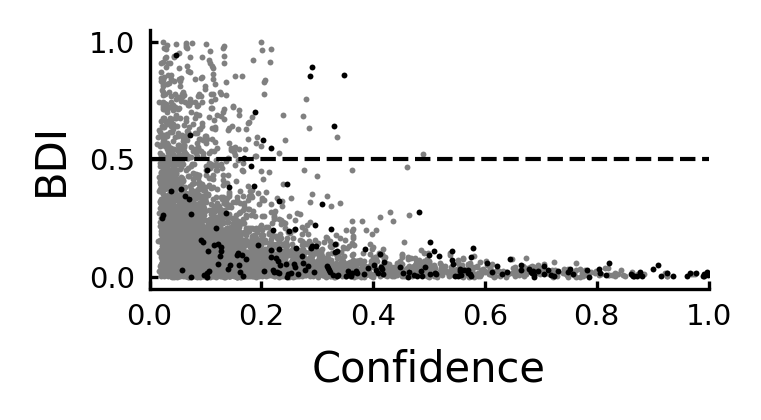

alexnet (all corruptions/severities): n=5020, acc=0.0382 | %BDI>0.5 (all)=6.33 | %BDI>0.5 (correct)=5.21 | %BDI>0.5 (incorrect)=6.38


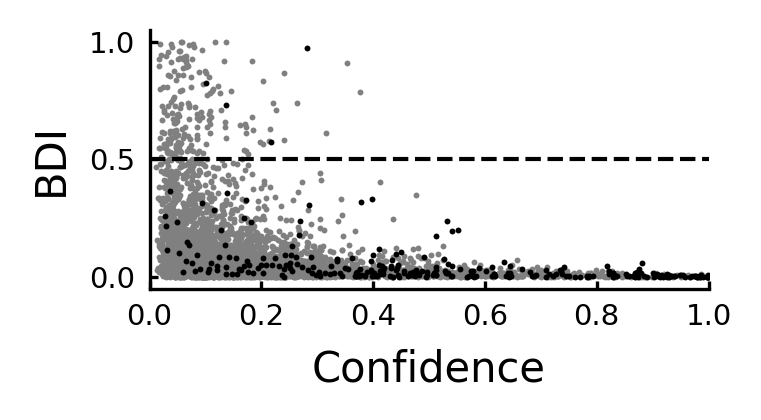

vgg16 (all corruptions/severities): n=5020, acc=0.0552 | %BDI>0.5 (all)=3.90 | %BDI>0.5 (correct)=1.44 | %BDI>0.5 (incorrect)=4.05


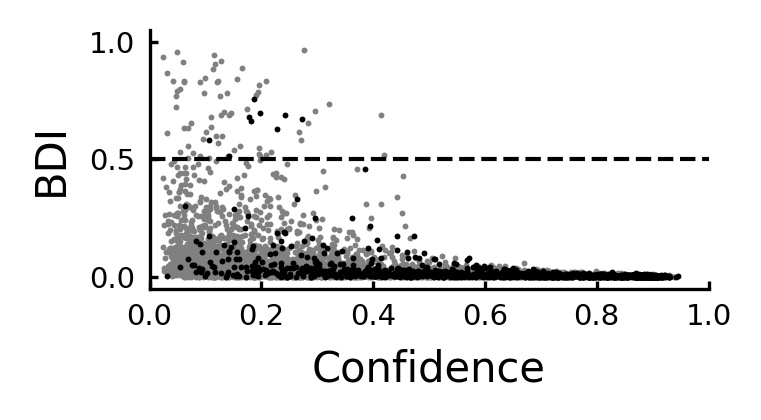

vit_b_16 (all corruptions/severities): n=5020, acc=0.2432 | %BDI>0.5 (all)=1.51 | %BDI>0.5 (correct)=0.74 | %BDI>0.5 (incorrect)=1.76


In [ ]:
# ------------------------------------------------------------
# Plot Confidence vs BDI from ImageNet-C per-image CSVs
# Correct = black, Incorrect = gray
# ALSO: print % trials with BDI > 0.5 (overall + optional by correctness)
# ------------------------------------------------------------

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

save_fig = False
out_dir = "/content/drive/MyDrive/AlexNet_Images"

models = ["alexnet", "vgg16", "vit_b_16"]

PLOT_BY_CORRUPTION = False
PLOT_BY_SEVERITY   = False
CONF_LIM = (0.0, 1.0)
BDI_LIM  = (-0.05, 1.05)

def csv_for_model(mname: str) -> str:
    p = os.path.join(out_dir, f"{mname}_per_image_ALL.csv")
    if not os.path.isfile(p):
        raise FileNotFoundError(f"Missing CSV for {mname}: {p}")
    return p

def plot_scatter(df, title, outpath=None):
    # coerce numeric columns
    x = pd.to_numeric(df["conf"], errors="coerce").to_numpy(float)
    y = pd.to_numeric(df["bdi"],  errors="coerce").to_numpy(float)
    c = pd.to_numeric(df["correct"], errors="coerce").to_numpy(float)

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(c)
    x, y, c = x[mask], y[mask], c[mask].astype(int)

    m_ok  = (c == 1)
    m_bad = (c == 0)

    # ---- NEW: % trials with BDI > 0.5 ----
    pct_bdi_gt05_all = 100.0 * float(np.mean(y > 0.5)) if y.size else np.nan
    pct_bdi_gt05_ok  = 100.0 * float(np.mean(y[m_ok] > 0.5)) if np.any(m_ok) else np.nan
    pct_bdi_gt05_bad = 100.0 * float(np.mean(y[m_bad] > 0.5)) if np.any(m_bad) else np.nan

    fig, ax = plt.subplots(figsize=(2.7, 1.5), dpi=300)

    # Plot incorrect first (gray), then correct on top (black)
    if np.any(m_bad):
        ax.scatter(x[m_bad], y[m_bad], s=2, color="gray", alpha=1.0, linewidths=0, rasterized=True)
    if np.any(m_ok):
        ax.scatter(x[m_ok],  y[m_ok],  s=2, color="black", alpha=1.0, linewidths=0, rasterized=True)

    ax.axhline(0.5, linestyle="--", color="black", linewidth=1)
    ax.set_xlim(*CONF_LIM)
    ax.set_ylim(*BDI_LIM)

    ax.set_xlabel("Confidence", fontsize=10)
    ax.set_ylabel("BDI", fontsize=10)

    overall_acc = float(m_ok.mean()) if c.size else np.nan

    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.tick_params(axis="both", which="both", direction="in", length=2, labelsize=7)

    fig.tight_layout()
    if outpath is not None and save_fig:
        fig.savefig(outpath, bbox_inches="tight", pad_inches=0.02)
    plt.show()

    print(
        f"{title}: n={x.size}, acc={overall_acc:.4f} | "
        f"%BDI>0.5 (all)={pct_bdi_gt05_all:.2f} | "
        f"%BDI>0.5 (correct)={pct_bdi_gt05_ok:.2f} | "
        f"%BDI>0.5 (incorrect)={pct_bdi_gt05_bad:.2f}"
    )

# -----------------------------
# Main
# -----------------------------
for mname in models:
    csv_path = csv_for_model(mname)
    df = pd.read_csv(csv_path)

    required = {"conf", "bdi", "correct", "corruption", "severity"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{mname}: missing columns {missing} in {os.path.basename(csv_path)}")

    # ---- overall plot ----
    outpath = os.path.join(out_dir, f"{mname}_imagenetc_conf_vs_bdi_ALL.eps")
    plot_scatter(df, title=f"{mname} (all corruptions/severities)", outpath=outpath)

    # ---- optional: per corruption ----
    if PLOT_BY_CORRUPTION:
        for corr in sorted(df["corruption"].dropna().unique()):
            d0 = df[df["corruption"] == corr]
            outpath = os.path.join(out_dir, f"{mname}_imagenetc_conf_vs_bdi_{corr}.eps")
            plot_scatter(d0, title=f"{mname} | {corr}", outpath=outpath)

    # ---- optional: per severity ----
    if PLOT_BY_SEVERITY:
        sev_vals = pd.to_numeric(df["severity"], errors="coerce").dropna().unique()
        for sev in sorted(sev_vals):
            d0 = df[pd.to_numeric(df["severity"], errors="coerce") == sev]
            outpath = os.path.join(out_dir, f"{mname}_imagenetc_conf_vs_bdi_sev{int(sev)}.eps")
            plot_scatter(d0, title=f"{mname} | severity {int(sev)}", outpath=outpath)



alexnet: n=5000 | conf range=(0.013,0.999) | bdi range=(0.000,1.000)
alexnet: acc (as stored) = 0.0382
alexnet paired t-test across confidence bins (err_low vs err_high): n_bins=19 | t=-0.5016 | p=0.6221
Saved: /content/drive/MyDrive/AlexNet_Images/alexnet_Fig6_matchedConf_error_lowHighBDI.eps


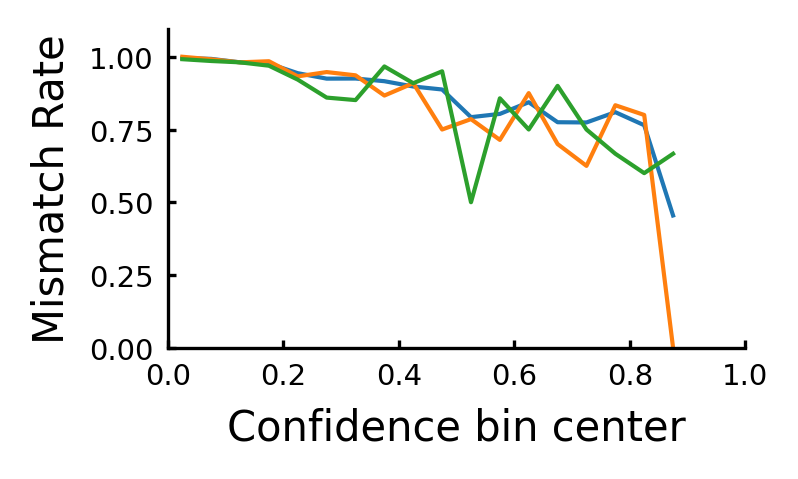

Saved: /content/drive/MyDrive/AlexNet_Images/alexnet_Fig6_bar_meanSEM_all_lowHighBDI.eps


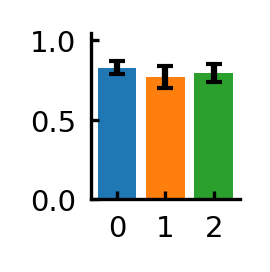


vgg16: n=5000 | conf range=(0.012,0.999) | bdi range=(0.000,0.999)
vgg16: acc (as stored) = 0.0548
vgg16 paired t-test across confidence bins (err_low vs err_high): n_bins=20 | t=0.3113 | p=0.759
Saved: /content/drive/MyDrive/AlexNet_Images/vgg16_Fig6_matchedConf_error_lowHighBDI.eps


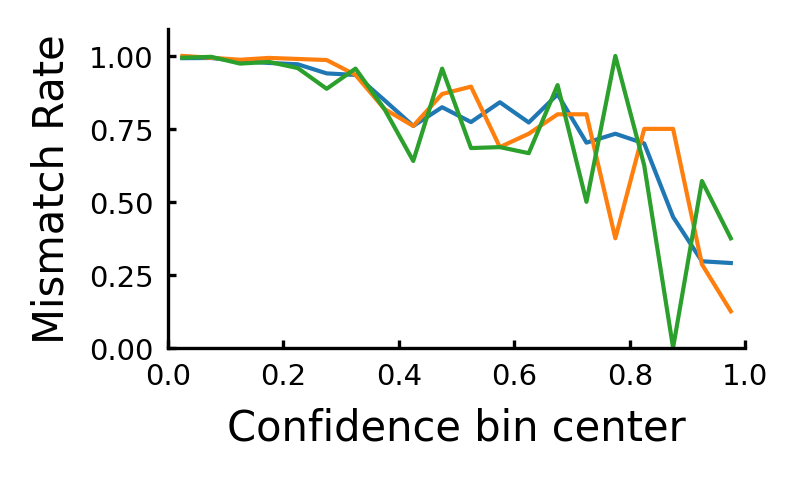

Saved: /content/drive/MyDrive/AlexNet_Images/vgg16_Fig6_bar_meanSEM_all_lowHighBDI.eps


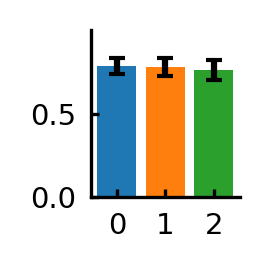


vit_b_16: n=5000 | conf range=(0.024,0.946) | bdi range=(0.000,0.963)
vit_b_16: acc (as stored) = 0.2428
vit_b_16 paired t-test across confidence bins (err_low vs err_high): n_bins=19 | t=-1.7918 | p=0.08999
Saved: /content/drive/MyDrive/AlexNet_Images/vit_b_16_Fig6_matchedConf_error_lowHighBDI.eps


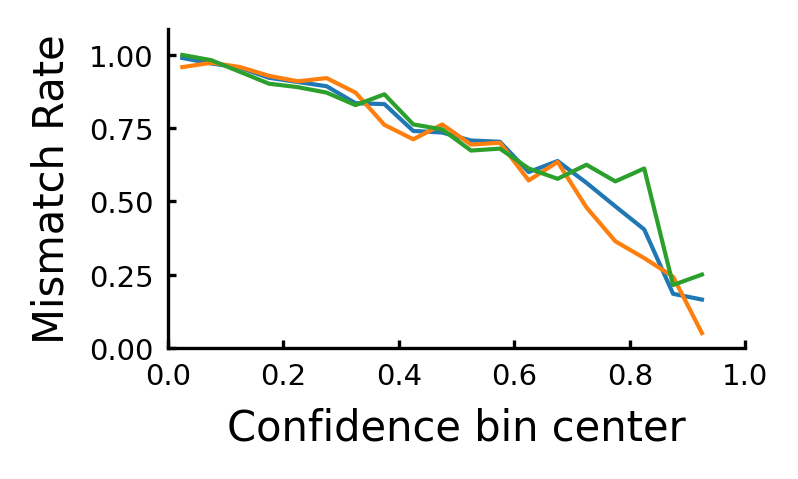

Saved: /content/drive/MyDrive/AlexNet_Images/vit_b_16_Fig6_bar_meanSEM_all_lowHighBDI.eps


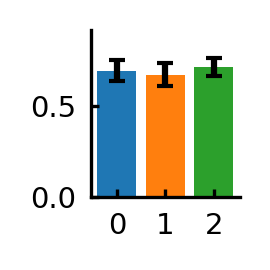

In [ ]:
# ============================================================
# Figure 6 analysis (matched-confidence bins; stratify by BDI)
#
# Goal (what Fig 6 implies):
#   - At similar confidence, trials can have very different BDI.
#   - Quantify this by binning confidence and computing:
#       (1) spread of BDI within each confidence bin (IQR + 10–90%)
#       (2) % bias-dominant (BDI>0.5) within each confidence bin
#       (3) OPTIONAL (if labels exist): error rate within each confidence bin,
#           and error rate for low-BDI vs high-BDI at matched confidence.
#
# Works with per-image CSVs produced by your ImageNet-C run:
#   OUT_DIR/<model>_per_image_ALL.csv
# Columns expected:
#   conf, bdi, correct, corruption, severity, path, y, wnid, top1, top2, ...
#
# IMPORTANT:
#   - If you want to preserve a "label-free" framing, you can still compute
#     (1) and (2) without using 'correct'. The code supports both.
#
# Outputs:
#   - Scatter: conf vs BDI (gray points), plus binned median/IQR band
#   - Line: %BDI>0.5 vs confidence bin
#   - OPTIONAL: error rate low/high BDI within matched-confidence bins
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as spstats

# -------------------------
# Config
# -------------------------
OUT_DIR = "/content/drive/MyDrive/AlexNet_Images"
MODELS  = ["alexnet", "vgg16", "vit_b_16"]

# Choose subset of ImageNet-C to reproduce Fig 6
# - If you want the exact 1500 trials used in the figure, set N_SAMPLE=1500
# - If you want to use all rows, set N_SAMPLE=None
N_SAMPLE = 5000

# Optional filters
FILTER_CORRUPTIONS = None   # e.g., ["gaussian_noise", "motion_blur"] or None for all
FILTER_SEVERITIES  = None   # e.g., [3] or [1,2,3,4,5] or None for all

# Confidence binning
# For ImageNet-1k softmax, confidence spans [0,1]. Use finer bins at high conf if desired.
BIN_EDGES = np.linspace(0.0, 1.0, 21)  # 20 bins of width 0.05

# BDI threshold (bias dominance)
BDI_THR = 0.5

# Matched-confidence stratification for "low vs high BDI"
# Use quantiles within each confidence bin.
LOW_Q  = 0.25
HIGH_Q = 0.75

SAVE_FIG = True


# -------------------------
# Helpers
# -------------------------
def load_model_df(model_name: str) -> pd.DataFrame:
    csv_path = os.path.join(OUT_DIR, f"{model_name}_per_image_ALL.csv")
    if not os.path.isfile(csv_path):
        raise FileNotFoundError(f"Missing: {csv_path}")
    df = pd.read_csv(csv_path)

    # required columns
    for col in ["conf", "bdi", "corruption", "severity"]:
        if col not in df.columns:
            raise ValueError(f"{model_name}: missing '{col}' in CSV columns")

    # numeric coercion
    df["conf"] = pd.to_numeric(df["conf"], errors="coerce")
    df["bdi"]  = pd.to_numeric(df["bdi"],  errors="coerce")

    if "correct" in df.columns:
        df["correct"] = pd.to_numeric(df["correct"], errors="coerce")

    # filtering
    if FILTER_CORRUPTIONS is not None:
        df = df[df["corruption"].isin(FILTER_CORRUPTIONS)]
    if FILTER_SEVERITIES is not None:
        sev = pd.to_numeric(df["severity"], errors="coerce")
        df = df[sev.isin(FILTER_SEVERITIES)]

    df = df[np.isfinite(df["conf"]) & np.isfinite(df["bdi"])]

    # optional subsample (deterministic)
    if N_SAMPLE is not None and len(df) > N_SAMPLE:
        df = df.sample(n=N_SAMPLE, random_state=0)

    return df.reset_index(drop=True)

def binned_stats(conf, bdi, edges):
    # returns per-bin centers and summary stats for bdi
    conf = np.asarray(conf)
    bdi  = np.asarray(bdi)

    bin_id = np.digitize(conf, edges, right=False) - 1
    nb = len(edges) - 1

    centers = 0.5 * (edges[:-1] + edges[1:])
    out = dict(
        centers=centers,
        n=np.zeros(nb, dtype=int),
        med=np.full(nb, np.nan),
        q10=np.full(nb, np.nan),
        q25=np.full(nb, np.nan),
        q75=np.full(nb, np.nan),
        q90=np.full(nb, np.nan),
        frac_gt=np.full(nb, np.nan),
    )

    for b in range(nb):
        m = (bin_id == b)
        if not np.any(m):
            continue
        v = bdi[m]
        v = v[np.isfinite(v)]
        if v.size == 0:
            continue
        out["n"][b] = v.size
        out["med"][b] = np.median(v)
        out["q10"][b] = np.quantile(v, 0.10)
        out["q25"][b] = np.quantile(v, 0.25)
        out["q75"][b] = np.quantile(v, 0.75)
        out["q90"][b] = np.quantile(v, 0.90)
        out["frac_gt"][b] = np.mean(v > BDI_THR)
    return out

def matched_conf_error_rate(df, edges, low_q=0.25, high_q=0.75):
    """
    OPTIONAL: requires df['correct'] (0/1).
    Within each confidence bin:
      - define low-BDI = bottom quantile, high-BDI = top quantile
      - compute error rate for low vs high BDI subsets
    """
    if "correct" not in df.columns:
        return None

    conf = df["conf"].to_numpy(float)
    bdi  = df["bdi"].to_numpy(float)
    cor  = df["correct"].to_numpy(float)

    mask = np.isfinite(conf) & np.isfinite(bdi) & np.isfinite(cor)
    conf, bdi, cor = conf[mask], bdi[mask], cor[mask]
    err = 1.0 - cor

    bin_id = np.digitize(conf, edges, right=False) - 1
    nb = len(edges) - 1
    centers = 0.5 * (edges[:-1] + edges[1:])

    out = dict(
        centers=centers,
        n=np.zeros(nb, dtype=int),
        err_all=np.full(nb, np.nan),
        err_low=np.full(nb, np.nan),
        err_high=np.full(nb, np.nan),
        n_low=np.zeros(nb, dtype=int),
        n_high=np.zeros(nb, dtype=int),
    )

    for b in range(nb):
        m = (bin_id == b)
        if not np.any(m):
            continue
        vb = bdi[m]
        eb = err[m]
        if vb.size < 10:
            continue

        out["n"][b] = vb.size
        out["err_all"][b] = np.mean(eb)

        ql = np.quantile(vb, low_q)
        qh = np.quantile(vb, high_q)

        m_low = vb <= ql
        m_high = vb >= qh

        if np.any(m_low):
            out["n_low"][b] = int(m_low.sum())
            out["err_low"][b] = float(np.mean(eb[m_low]))
        if np.any(m_high):
            out["n_high"][b] = int(m_high.sum())
            out["err_high"][b] = float(np.mean(eb[m_high]))

    return out

def plot_fig6_like(df, model_name: str):
    conf = df["conf"].to_numpy(float)
    bdi  = df["bdi"].to_numpy(float)

    stats = binned_stats(conf, bdi, BIN_EDGES)
    err_stats = matched_conf_error_rate(df, BIN_EDGES, LOW_Q, HIGH_Q)

    # -------------------------
    # Panel 1:
    # (A) matched-confidence error curves
    # (B) separate bar plot: mean±SEM across confidence bins + paired t-test
    # -------------------------
    if err_stats is not None:
        centers = err_stats["centers"]
        err_all  = np.asarray(err_stats["err_all"], dtype=float)
        err_low  = np.asarray(err_stats["err_low"], dtype=float)
        err_high = np.asarray(err_stats["err_high"], dtype=float)

        # paired bins where BOTH low and high exist
        m_pair = np.isfinite(err_low) & np.isfinite(err_high)
        low_pair  = err_low[m_pair]
        high_pair = err_high[m_pair]

        def mean_sem(v: np.ndarray):
            v = v[np.isfinite(v)]
            if v.size == 0:
                return np.nan, np.nan, 0
            mu = float(np.mean(v))
            sem = float(np.std(v, ddof=1) / np.sqrt(v.size)) if v.size > 1 else np.nan
            return mu, sem, int(v.size)

        mu_low,  sem_low,  n_bins = mean_sem(low_pair)
        mu_high, sem_high, _      = mean_sem(high_pair)

        # paired t-test across bins
        if n_bins >= 2:
            t_stat, p_val = spstats.ttest_rel(low_pair, high_pair, nan_policy="omit")
        else:
            t_stat, p_val = np.nan, np.nan

        print(
            f"{model_name} paired t-test across confidence bins (err_low vs err_high): "
            f"n_bins={n_bins} | t={t_stat:.4f} | p={p_val:.4g}"
        )

                # ---- Figure 1: curves (capture line colors) ----
        fig1, ax1 = plt.subplots(figsize=(2.7, 1.7), dpi=300)

        l_all  = ax1.plot(centers, err_all,  linewidth=1, label="all")[0]
        l_low  = ax1.plot(centers, err_low,  linewidth=1, label=f"low BDI (≤Q{int(LOW_Q*100)})")[0]
        l_high = ax1.plot(centers, err_high, linewidth=1, label=f"high BDI (≥Q{int(HIGH_Q*100)})")[0]

        col_all  = l_all.get_color()
        col_low  = l_low.get_color()
        col_high = l_high.get_color()

        ax1.set_xlim(0, 1)
        ymax = np.nanmax(err_all)
        ax1.set_ylim(0, ymax * 1.1 if np.isfinite(ymax) and ymax > 0 else 1)
        ax1.set_xlabel("Confidence bin center", fontsize=10)
        ax1.set_ylabel("Mismatch Rate", fontsize=10)
        ax1.spines["right"].set_visible(False)
        ax1.spines["top"].set_visible(False)
        ax1.tick_params(axis="both", which="both", direction="in", length=2, labelsize=7)
        # ax1.legend(frameon=False, fontsize=7)
        fig1.tight_layout()

        if SAVE_FIG:
            p1 = os.path.join(OUT_DIR, f"{model_name}_Fig6_matchedConf_error_lowHighBDI.eps")
            fig1.savefig(p1, bbox_inches="tight", pad_inches=0.02)
            print("Saved:", p1)

        plt.show()

        # ---- Figure 2: bar plot (separate) mean±SEM across confidence bins ----
        # Compute "all" across bins where err_all is defined
        all_bins = err_all[np.isfinite(err_all)]

        mu_all,  sem_all,  n_allbins  = mean_sem(all_bins)
        mu_low,  sem_low,  n_lowbins  = mean_sem(low_pair)    # already paired-defined above
        mu_high, sem_high, n_highbins = mean_sem(high_pair)

        fig2, ax2 = plt.subplots(figsize=(1, 1), dpi=300)

        labels = ["all", f"low (≤Q{int(LOW_Q*100)})", f"high (≥Q{int(HIGH_Q*100)})"]
        means  = [mu_all, mu_low, mu_high]
        sems   = [sem_all, sem_low, sem_high]
        colors = [col_all, col_low, col_high]

        xbar = np.arange(len(labels))
        ax2.bar(xbar, means, yerr=sems, capsize=2, color=colors)
        ax2.set_xticks(xbar)
        ax2.set_ylim(0, 1)
        ax2.set_yticks([0, 0.5, 1.0])
        # ax2.set_xticklabels(labels, fontsize=7)
        # ax2.set_ylabel("Mean mismatch\n(across bins)", fontsize=10)

        ymax2 = np.nanmax([
            mu_all  + (sem_all  if np.isfinite(sem_all)  else 0),
            mu_low  + (sem_low  if np.isfinite(sem_low)  else 0),
            mu_high + (sem_high if np.isfinite(sem_high) else 0),
        ])
        ax2.set_ylim(0, ymax2 * 1.2 if np.isfinite(ymax2) and ymax2 > 0 else 1)

        ax2.spines["right"].set_visible(False)
        ax2.spines["top"].set_visible(False)
        ax2.tick_params(axis="both", which="both", direction="in", length=2, labelsize=7)

        # annotate both n's: paired bins for t-test, and bins used for "all"
        # ax2.set_title(
        #     f"paired t-test (low vs high): p={p_val:.3g}\n"
        #     f"n_bins paired={n_bins}, n_bins all={n_allbins}",
        #     fontsize=8
        # )
        fig2.tight_layout()

        if SAVE_FIG:
            p2 = os.path.join(OUT_DIR, f"{model_name}_Fig6_bar_meanSEM_all_lowHighBDI.eps")
            fig2.savefig(p2, bbox_inches="tight", pad_inches=0.02)
            print("Saved:", p2)

        plt.show()


# -------------------------
# Run for each model
# -------------------------
for m in MODELS:
    dfm = load_model_df(m)
    print(f"\n{m}: n={len(dfm)} | conf range=({dfm.conf.min():.3f},{dfm.conf.max():.3f}) | bdi range=({dfm.bdi.min():.3f},{dfm.bdi.max():.3f})")
    if "correct" in dfm.columns:
        acc = float(np.mean(dfm["correct"].to_numpy(float) == 1))
        print(f"{m}: acc (as stored) = {acc:.4f}")
    plot_fig6_like(dfm, m)


In [ ]:
USE = "vit_b16" # "alexnet", "vgg16"
SAVE_FIG = True

out_dir = "/content/drive/MyDrive/AlexNet_Images/"


# -----------------------------
# 1) Clean inputs (NO correctness used)
# -----------------------------
if USE in ("alexnet", "vgg16"):
    csv_path = os.path.join(out_dir, f"{USE}_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv")  # adjust if needed
    df = pd.read_csv(csv_path)

    df["conf"] = pd.to_numeric(df["conf"], errors="coerce")
    df["bdi_all"] = pd.to_numeric(df["bdi_all"], errors="coerce")

    df = df.dropna(subset=["conf", "bdi_all"]).copy()
    conf = df["conf"].to_numpy(dtype=float)
    bdi_all = df["bdi_all"].to_numpy(dtype=float)

elif USE == "vit_b16":
    csv_path = os.path.join(out_dir, f"{USE}_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv")  # adjust if needed
    df = pd.read_csv(csv_path)

    # ViT file uses conf_top1; normalize to a common column name "conf"
    df["conf"] = pd.to_numeric(df["conf_top1"], errors="coerce")
    df["bdi_all"] = pd.to_numeric(df["bdi_all"], errors="coerce")

    df = df.dropna(subset=["conf", "bdi_all"]).copy()
    conf = df["conf"].to_numpy(dtype=float)
    bdi_all = df["bdi_all"].to_numpy(dtype=float)

else:
    raise ValueError(f"Unknown USE='{USE}'. Expected 'alexnet', 'vgg16', or 'vit_b_16'.")


# -----------------------------
# 2) Coverage grid over (tau, gamma)
# accept := (conf ≥ tau) & (BDI_all ≤ gamma)
# -----------------------------
taus = np.linspace(0, 1, 201)
gammas = np.linspace(0, 1, 201)

cov_grid = np.zeros((taus.size, gammas.size), dtype=float)

for i, tau in enumerate(taus):
    base = conf >= tau
    if base.sum() == 0:
        cov_grid[i, :] = 0.0
        continue
    b = bdi_all[base]
    cov_grid[i, :] = (b[:, None] <= gammas[None, :]).mean(axis=0) * base.mean()

# -----------------------------
# 3) Heatmap + contours (fontsize=6, RdBu, black lines)
# -----------------------------
plt.figure(figsize=(3, 2), dpi=200)
X, Y = np.meshgrid(gammas, taus)

im = plt.imshow(
    cov_grid,
    origin="lower",
    aspect="auto",
    extent=[gammas.min(), gammas.max(), taus.min(), taus.max()],
    cmap="RdBu_r",
    vmin=0.0, vmax=1.0,
    interpolation="bilinear"
)

cbar = plt.colorbar(im, ticks=[0,0.2,0.4,0.6,0.8,1.0])
cbar.set_label("fraction accepted", fontsize=6, rotation=-90, labelpad=10)
cbar.ax.tick_params(labelsize=6)

cand = np.array([0.1, 0.3, 0.5, 0.7, 0.9], dtype=float)
zmin, zmax = float(np.nanmin(cov_grid)), float(np.nanmax(cov_grid))
levels = cand[(cand > zmin + 1e-12) & (cand < zmax - 1e-12)]
if levels.size < 2:
    levels = np.linspace(zmin, zmax, 6)

cs = plt.contour(X, Y, cov_grid, levels=np.sort(levels), linewidths=0.9, colors="black")
plt.clabel(cs, inline=True, fontsize=6, fmt="%.2f", colors="black")

# plt.xlabel("BDI ≤ γ", fontsize=10)
plt.xlabel(r"$\mathrm{BDI}_{\mathrm{all}} \leq \gamma$", fontsize=10)
plt.ylabel("Confidence ≥ τ", fontsize=10)
# plt.title("Coverage heatmap + contours: accept := (conf ≥ τ) & (BDI_all ≤ γ)", fontsize=6)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

plt.tight_layout()

if SAVE_FIG:
  p = os.path.join(out_dir, f"{USE}_confidence_bdi_all_acceptance_map.eps")
  plt.savefig(p, bbox_inches="tight", pad_inches=0.02)

plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/AlexNet_Images/vit_b16_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv'

In [ ]:
USE = "alexnet"
SAVE_FIG = True
out_dir = "/content/drive/MyDrive/AlexNet_Images/"

# -----------------------------
# 1) Load + clean inputs (needs risk column)
# -----------------------------
if USE in ("alexnet", "vgg16"):
    csv_path = os.path.join(out_dir, f"{USE}_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv")
    df = pd.read_csv(csv_path)

    df["conf"] = pd.to_numeric(df["conf"], errors="coerce")
    # handle alt name
    if "bdi_all" not in df.columns and "bdi_all_layers" in df.columns:
        df["bdi_all"] = df["bdi_all_layers"]
    df["bdi_all"] = pd.to_numeric(df["bdi_all"], errors="coerce")

elif USE == "vit_b16":
    csv_path = os.path.join(out_dir, f"{USE}_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv")
    df = pd.read_csv(csv_path)

    df["conf"] = pd.to_numeric(df["conf_top1"], errors="coerce")
    if "bdi_all" not in df.columns and "bdi_all_layers" in df.columns:
        df["bdi_all"] = df["bdi_all_layers"]
    df["bdi_all"] = pd.to_numeric(df["bdi_all"], errors="coerce")

else:
    raise ValueError(f"Unknown USE='{USE}'. Expected 'alexnet', 'vgg16', or 'vit_b16'.")

# --- detect risk column ---
risk_col = None
if "mismatch" in df.columns:
    risk_col = "mismatch"     # 1=bad
elif "match" in df.columns:
    risk_col = "match"        # 1=good (invert)
elif "correct" in df.columns:
    risk_col = "correct"      # 1=good (invert)

if risk_col is None:
    raise ValueError("No risk column found. Need one of: 'mismatch', 'match', or 'correct'.")

df[risk_col] = pd.to_numeric(df[risk_col], errors="coerce")

# Drop NaNs
df = df.dropna(subset=["conf", "bdi_all", risk_col]).copy()

conf = df["conf"].to_numpy(dtype=float)
bdi_all = df["bdi_all"].to_numpy(dtype=float)

# risk := 1 means bad outcome
rraw = df[risk_col].to_numpy(dtype=float)
risk = rraw if risk_col == "mismatch" else (1.0 - rraw)
risk = np.clip(risk, 0.0, 1.0)

# -----------------------------
# 2) Risk grid over (tau, gamma)
# accept := (conf ≥ tau) & (BDI_all ≤ gamma)
# risk_grid[i,j] = mean(risk | accepted), NaN if none accepted
# -----------------------------
taus = np.linspace(0, 1, 201)
gammas = np.linspace(0, 1, 201)

risk_grid = np.full((taus.size, gammas.size), np.nan, dtype=float)

for i, tau in enumerate(taus):
    base = conf >= tau
    if not np.any(base):
        continue

    b = bdi_all[base]
    r = risk[base]

    for j, g in enumerate(gammas):
        sel = b <= g
        if np.any(sel):
            risk_grid[i, j] = float(np.mean(r[sel]))

# -----------------------------
# 3) Risk heatmap (Reds) + contours (black)
# -----------------------------
plt.figure(figsize=(3, 2), dpi=200)
X, Y = np.meshgrid(gammas, taus)

im = plt.imshow(
    risk_grid,
    origin="lower",
    aspect="auto",
    extent=[gammas.min(), gammas.max(), taus.min(), taus.max()],
    cmap="Reds",
    vmin=0.0, vmax=1.0,          # colorbar range [0,1]
    interpolation="bilinear"
)

cbar = plt.colorbar(im, ticks=[0,0.2,0.4,0.6,0.8,1.0])
cbar.set_label("risk among accepted", fontsize=6, rotation=-90, labelpad=10)
cbar.ax.tick_params(labelsize=6)

# contours (optional)
cand = np.array([0.1, 0.3, 0.5, 0.7, 0.9], dtype=float)
zmin, zmax = float(np.nanmin(risk_grid)), float(np.nanmax(risk_grid))
levels = cand[(cand > zmin + 1e-12) & (cand < zmax - 1e-12)]
if levels.size < 2:
    levels = np.linspace(zmin, zmax, 6)

cs = plt.contour(X, Y, risk_grid, levels=np.sort(levels), linewidths=0.9, colors="black")
plt.clabel(cs, inline=True, fontsize=6, fmt="%.2f", colors="black")

plt.xlabel(r"$\mathrm{BDI}_{\mathrm{all}} \leq \gamma$", fontsize=10)
plt.ylabel("Confidence ≥ τ", fontsize=10)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

plt.tight_layout()

if SAVE_FIG:
    p = os.path.join(out_dir, f"{USE}_confidence_bdi_all_risk_heatmap.eps")
    plt.savefig(p, bbox_inches="tight", pad_inches=0.02)

plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/AlexNet_Images/alexnet_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv'

Loaded: /content/drive/MyDrive/AlexNet_Images/vgg16_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv
Shape: (10000, 61)
First columns: ['img_path', 'wnid', 'y_tiny', 'y_im1k', 'valid_label', 'pred', 'conf', 'correct', 'bdi_all', 'top1', 'top2', 'C_evid_all', 'C_bias_all', 'features__0__Cevid', 'features__0__Cbias', 'features__2__Cevid', 'features__2__Cbias', 'features__5__Cevid', 'features__5__Cbias', 'features__7__Cevid']
Valid rows: 10000
Accuracy: 0.1672
Mismatch rate overall: 0.8328
Saved: /content/drive/MyDrive/AlexNet_Images/vgg16_local_imagenet_mismatch_vs_BDI_fixed_conf.eps
Saved: /content/drive/MyDrive/AlexNet_Images/vgg16_local_imagenet_mismatch_vs_BDI_fixed_conf.png


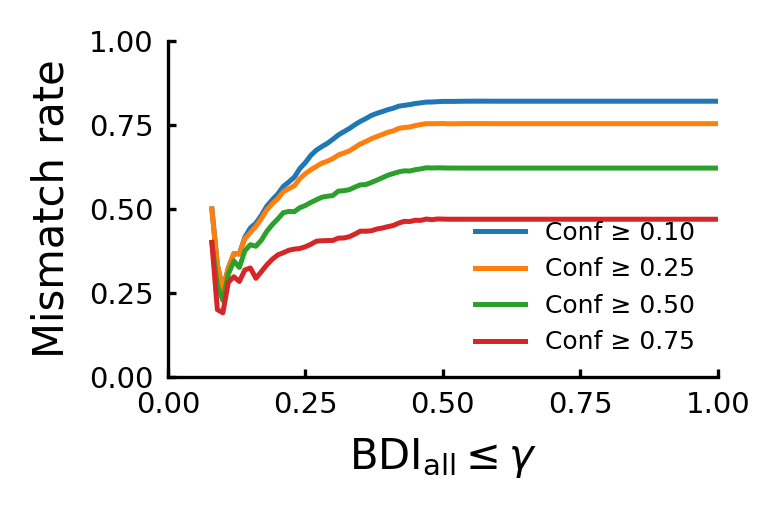


Summary at BDI threshold = 0.50
  Conf >= 0.10: mismatch=0.8201 | accepted=9010
  Conf >= 0.25: mismatch=0.7542 | accepted=5737
  Conf >= 0.50: mismatch=0.6221 | accepted=2543
  Conf >= 0.75: mismatch=0.4696 | accepted=1052

Summary at BDI threshold = 1.00
  Conf >= 0.10: mismatch=0.8206 | accepted=9171
  Conf >= 0.25: mismatch=0.7538 | accepted=5808
  Conf >= 0.50: mismatch=0.6216 | accepted=2558
  Conf >= 0.75: mismatch=0.4691 | accepted=1053


In [6]:
# ============================================================
# Mismatch-rate vs BDI-threshold curves
# for fixed confidence thresholds
#
# Acceptance rule:
#   accept if conf_top1 >= tau and bdi_all <= gamma
#
# Plot:
#   x-axis = BDI threshold gamma
#   y-axis = mismatch rate among accepted samples
#   curves = tau in [0.1, 0.25, 0.5, 0.75]
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
USE = "vgg16"   # "alexnet" | "vgg16" | "vit_b16"

out_dir = "/content/drive/MyDrive/AlexNet_Images"
save_dir = out_dir
os.makedirs(save_dir, exist_ok=True)

save_fig = True

# Fixed confidence thresholds
CONF_THRESHOLDS = [0.10, 0.25, 0.50, 0.75]

# BDI thresholds to sweep on x-axis
BDI_GRID = np.linspace(0.0, 1.0, 101)

# Optional minimum accepted samples required to compute mismatch
MIN_ACCEPTED = 5

# Plot settings
FIGSIZE = (2.7, 1.8)
DPI = 300

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
mpl.set_loglevel("error")


# ------------------------------------------------------------
# Locate CSV
# ------------------------------------------------------------
csv_path = os.path.join(
    out_dir,
    f"{USE}_tiny_val_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv"
)

if not os.path.isfile(csv_path):
    matches = sorted(glob.glob(
        os.path.join(
            out_dir,
            f"{USE}_local_imagenet*_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv"
        )
    ))
    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find CSV for {USE} in {out_dir}"
        )
    csv_path = matches[-1]
    print("Using auto-detected CSV:", csv_path)

df = pd.read_csv(csv_path)

print("Loaded:", csv_path)
print("Shape:", df.shape)
print("First columns:", df.columns[:20].tolist())


# ------------------------------------------------------------
# Identify columns
# ------------------------------------------------------------
conf_col = (
    "conf_top1" if "conf_top1" in df.columns
    else "conf" if "conf" in df.columns
    else None
)

bdi_col = (
    "bdi_all" if "bdi_all" in df.columns
    else "bdi_all_layers" if "bdi_all_layers" in df.columns
    else None
)

correct_col = "correct" if "correct" in df.columns else None

if conf_col is None:
    raise ValueError("Could not find confidence column ('conf_top1' or 'conf').")

if bdi_col is None:
    raise ValueError("Could not find BDI column ('bdi_all' or 'bdi_all_layers').")

if correct_col is None:
    raise ValueError("Could not find 'correct' column; mismatch rate requires ground-truth correctness.")


# ------------------------------------------------------------
# Extract arrays
# ------------------------------------------------------------
conf = pd.to_numeric(df[conf_col], errors="coerce").to_numpy(float)
bdi  = pd.to_numeric(df[bdi_col], errors="coerce").to_numpy(float)
correct = pd.to_numeric(df[correct_col], errors="coerce").to_numpy(float)

# keep valid rows only
mask = np.isfinite(conf) & np.isfinite(bdi) & np.isfinite(correct)
conf = conf[mask]
bdi = bdi[mask]
correct = correct[mask].astype(int)

# mismatch = 1 when incorrect
mismatch = (correct == 0).astype(float)

print(f"Valid rows: {len(conf)}")
print(f"Accuracy: {np.mean(correct == 1):.4f}")
print(f"Mismatch rate overall: {np.mean(mismatch):.4f}")


# ------------------------------------------------------------
# Compute mismatch-rate curves
# ------------------------------------------------------------
def mismatch_vs_bdi_for_fixed_conf(conf, bdi, mismatch, tau, bdi_grid, min_accepted=5):
    """
    For a fixed confidence threshold tau, compute mismatch rate among:
        accept = (conf >= tau) & (bdi <= gamma)
    for each gamma in bdi_grid.
    """
    y = []
    n_acc = []

    conf_mask = conf >= tau

    for gamma in bdi_grid:
        accept = conf_mask & (bdi <= gamma)
        n = int(np.sum(accept))
        n_acc.append(n)

        if n < min_accepted:
            y.append(np.nan)
        else:
            y.append(np.mean(mismatch[accept]))

    return np.asarray(y, dtype=float), np.asarray(n_acc, dtype=int)


curve_dict = {}
count_dict = {}

for tau in CONF_THRESHOLDS:
    y, n_acc = mismatch_vs_bdi_for_fixed_conf(
        conf=conf,
        bdi=bdi,
        mismatch=mismatch,
        tau=tau,
        bdi_grid=BDI_GRID,
        min_accepted=MIN_ACCEPTED,
    )
    curve_dict[tau] = y
    count_dict[tau] = n_acc


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)

for tau in CONF_THRESHOLDS:
    ax.plot(
        BDI_GRID,
        curve_dict[tau],
        linewidth=1.2,
        label=f"Conf ≥ {tau:.2f}"
    )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])

# ax.set_xlabel("BDI threshold", fontsize=10)
ax.set_xlabel(r"$\mathrm{BDI}_{\mathrm{all}} \leq \gamma$", fontsize=10)
ax.set_ylabel("Mismatch rate", fontsize=10)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.tick_params(axis="both", which="both", direction="in", length=2, labelsize=7)

ax.legend(fontsize=6, frameon=False, loc="best")

fig.tight_layout()

if save_fig:
    base = os.path.join(save_dir, f"{USE}_local_imagenet_mismatch_vs_BDI_fixed_conf")
    fig.savefig(base + ".eps", format="eps", bbox_inches="tight", pad_inches=0.02)
    fig.savefig(base + ".png", dpi=600, bbox_inches="tight", pad_inches=0.02)
    print("Saved:", base + ".eps")
    print("Saved:", base + ".png")

plt.show()


# ------------------------------------------------------------
# Optional: print endpoint summaries
# ------------------------------------------------------------
print("\nSummary at BDI threshold = 0.50")
idx_05 = np.argmin(np.abs(BDI_GRID - 0.50))
for tau in CONF_THRESHOLDS:
    mm = curve_dict[tau][idx_05]
    nacc = count_dict[tau][idx_05]
    print(f"  Conf >= {tau:.2f}: mismatch={mm:.4f} | accepted={nacc}")

print("\nSummary at BDI threshold = 1.00")
idx_10 = np.argmin(np.abs(BDI_GRID - 1.00))
for tau in CONF_THRESHOLDS:
    mm = curve_dict[tau][idx_10]
    nacc = count_dict[tau][idx_10]
    print(f"  Conf >= {tau:.2f}: mismatch={mm:.4f} | accepted={nacc}")

## DeepLIFT comparison

USE: vit_b16
IMAGE_PATH: /content/tiny-imagenet-200/val/images/val_4626.JPEG
DEVICE_MAIN: cpu
DEVICE_ATTR: cpu

Single-image last-layer BDI:
top1        : 341
top2        : 342
conf_top1   : 0.4335118234157562
conf_top2   : 0.4135163128376007
BDI         : 0.7255416512489319
C_bias      : 0.0342613123357296
C_evid      : 0.012960389256477356
margin      : 0.047221701592206955

Attribution backend: deeplift


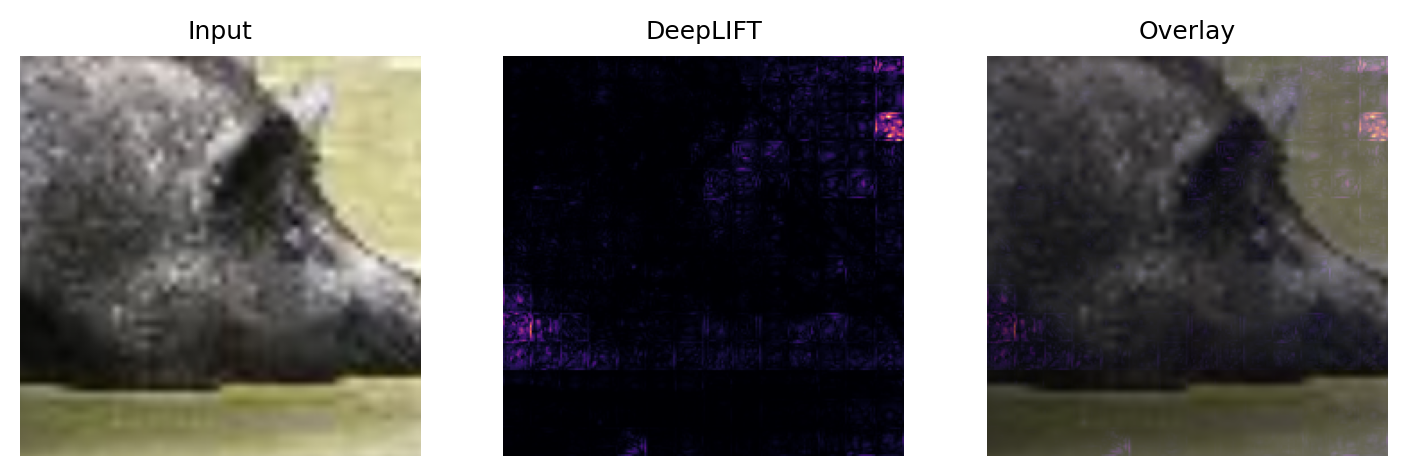

In [ ]:
# ============================================================
# Single-image last-layer BDI + DeepLIFT/Saliency attribution
# Works for AlexNet or VGG-16
# ============================================================

import os
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as tv_models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from PIL import Image


# ----------------------------
# Config
# ----------------------------
USE = "vit_b16"     # "alexnet", "vgg16", or "vit_b16"
ImageID = 4626
IMAGE_PATH = f"/content/tiny-imagenet-200/val/images/val_{ImageID}.JPEG"

DEVICE_MAIN = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE_ATTR = "cpu"   # safer for DeepLIFT

IMG_SIZE = 224
EPS = 1e-12

MARGIN_MODE = "top1_top2"  # "top1_top2" or "fixed"
C_POS, C_NEG = 281, 282    # only used if MARGIN_MODE == "fixed"

ATTR_METHOD = "auto"       # "auto", "deeplift", or "saliency"
ATTR_BASELINE = "zeros"

print("USE:", USE)
print("IMAGE_PATH:", IMAGE_PATH)
print("DEVICE_MAIN:", DEVICE_MAIN)
print("DEVICE_ATTR:", DEVICE_ATTR)

# ============================================================
# Model builder
# Supports AlexNet, VGG-16, and ViT-B/16
# ============================================================

def build_model(use, device):
    use = use.lower()

    if use == "alexnet":
        model = tv_models.alexnet(
            weights=tv_models.AlexNet_Weights.IMAGENET1K_V1
        ).to(device).eval()

        last_fc = model.classifier[-1]

        def forward_to_last_features(x):
            x = model.features(x)
            x = model.avgpool(x)
            x = torch.flatten(x, 1)
            x = model.classifier[:-1](x)
            return x

        return model, last_fc, forward_to_last_features

    elif use == "vgg16":
        model = tv_models.vgg16(
            weights=tv_models.VGG16_Weights.IMAGENET1K_V1
        ).to(device).eval()

        last_fc = model.classifier[-1]

        def forward_to_last_features(x):
            x = model.features(x)
            x = model.avgpool(x)
            x = torch.flatten(x, 1)
            x = model.classifier[:-1](x)
            return x

        return model, last_fc, forward_to_last_features

    elif use == "vit_b16":
        model = tv_models.vit_b_16(
            weights=tv_models.ViT_B_16_Weights.IMAGENET1K_V1
        ).to(device).eval()

        # Final classifier for torchvision ViT-B/16
        last_fc = model.heads.head

        def forward_to_last_features(x):
            """
            Return CLS-token representation immediately before the final classifier head.

            Mirrors torchvision VisionTransformer.forward():
              x = _process_input(x)
              prepend class token
              encoder
              take CLS token
              heads
            but stops before the final Linear head.
            """
            x = model._process_input(x)

            n = x.shape[0]
            batch_class_token = model.class_token.expand(n, -1, -1)
            x = torch.cat([batch_class_token, x], dim=1)

            x = model.encoder(x)

            # CLS token
            x = x[:, 0]

            # If future torchvision heads contain pre-head layers, apply them
            # but skip the final classifier.
            if isinstance(model.heads, nn.Sequential):
                head_modules = list(model.heads.children())

                if len(head_modules) > 1:
                    for m in head_modules[:-1]:
                        x = m(x)

            return x

        return model, last_fc, forward_to_last_features

    else:
        raise ValueError("USE must be 'alexnet', 'vgg16', or 'vit_b16'.")


# ============================================================
# Preprocess image
# ============================================================

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
])

if not os.path.isfile(IMAGE_PATH):
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

pil_image = Image.open(IMAGE_PATH).convert("RGB")
x_main = preprocess(pil_image).unsqueeze(0).to(DEVICE_MAIN)
x_attr = preprocess(pil_image).unsqueeze(0).to(DEVICE_ATTR)


# ============================================================
# Main model and single-image BDI
# ============================================================

model, last_fc, forward_to_last_features = build_model(USE, DEVICE_MAIN)


@torch.no_grad()
def bdi_single_image(x, margin_mode="top1_top2", c_pos=None, c_neg=None, eps=EPS):
    logits = model(x)
    probs = torch.softmax(logits, dim=1)

    if margin_mode == "fixed":
        if c_pos is None or c_neg is None:
            raise ValueError("c_pos and c_neg are required for fixed margin.")

        c1 = torch.tensor([int(c_pos)], device=x.device)
        c2 = torch.tensor([int(c_neg)], device=x.device)

    elif margin_mode == "top1_top2":
        top2 = torch.topk(logits, k=2, dim=1).indices
        c1 = top2[:, 0]
        c2 = top2[:, 1]

    else:
        raise ValueError("margin_mode must be 'top1_top2' or 'fixed'.")

    a = forward_to_last_features(x)

    W = last_fc.weight
    b = last_fc.bias

    dw = W[c1] - W[c2]
    db = b[c1] - b[c2]

    C_evid = (a * dw).sum(dim=1)
    C_bias = db

    margin = C_bias + C_evid

    BDI = torch.abs(C_bias) / (
        torch.abs(C_bias) + torch.abs(C_evid) + eps
    )

    conf_top1 = probs.gather(1, c1[:, None]).squeeze(1)
    conf_top2 = probs.gather(1, c2[:, None]).squeeze(1)

    return {
        "logits": logits.detach(),
        "top1": int(c1.item()),
        "top2": int(c2.item()),
        "conf_top1": float(conf_top1.item()),
        "conf_top2": float(conf_top2.item()),
        "BDI": float(BDI.item()),
        "C_bias": float(C_bias.item()),
        "C_evid": float(C_evid.item()),
        "margin": float(margin.item()),
    }


result = bdi_single_image(
    x_main,
    margin_mode=MARGIN_MODE,
    c_pos=C_POS,
    c_neg=C_NEG,
)

print("\nSingle-image last-layer BDI:")
for k, v in result.items():
    if k != "logits":
        print(f"{k:12s}: {v}")


# ============================================================
# Attribution backend
# ============================================================

def choose_attr_backend(method="auto"):
    method = method.lower()

    if method in ("deeplift", "saliency"):
        return method

    try:
        import captum  # noqa: F401
        return "deeplift"
    except Exception:
        return "saliency"


# ============================================================
# Attribution wrappers
# ============================================================

class MarginFixedScalar(nn.Module):
    def __init__(self, base_model, c_pos, c_neg):
        super().__init__()
        self.base = base_model
        self.c_pos = int(c_pos)
        self.c_neg = int(c_neg)

    def forward(self, x):
        logits = self.base(x)
        margin = logits[:, self.c_pos] - logits[:, self.c_neg]
        return margin.unsqueeze(1)


class MarginTop1Top2Scalar(nn.Module):
    """
    Uses fixed top1/top2 classes for this specific image.
    """
    def __init__(self, base_model, c1, c2):
        super().__init__()
        self.base = base_model
        self.c1 = int(c1)
        self.c2 = int(c2)

    def forward(self, x):
        logits = self.base(x)
        margin = logits[:, self.c1] - logits[:, self.c2]
        return margin.unsqueeze(1)


def saliency_heatmap(model_attr, x, margin_mode, c_pos=None, c_neg=None):
    model_attr.eval()

    xin = x.detach().clone().requires_grad_(True)
    logits = model_attr(xin)

    if margin_mode == "fixed":
        margin = logits[:, c_pos] - logits[:, c_neg]

    elif margin_mode == "top1_top2":
        with torch.no_grad():
            top2 = torch.topk(logits.detach(), k=2, dim=1).indices
            c1 = int(top2[0, 0].item())
            c2 = int(top2[0, 1].item())

        margin = logits[:, c1] - logits[:, c2]

    else:
        raise ValueError("margin_mode must be 'fixed' or 'top1_top2'.")

    model_attr.zero_grad(set_to_none=True)
    margin.sum().backward()

    return xin.grad.detach()


def deeplift_heatmap(model_attr, x, margin_mode, top1=None, top2=None, c_pos=None, c_neg=None):
    from captum.attr import DeepLift

    model_attr.eval()

    if ATTR_BASELINE == "zeros":
        baseline = torch.zeros_like(x)
    else:
        raise ValueError("Currently only ATTR_BASELINE='zeros' is implemented.")

    if margin_mode == "fixed":
        wrapper = MarginFixedScalar(
            model_attr,
            c_pos=c_pos,
            c_neg=c_neg,
        ).to(x.device)

    elif margin_mode == "top1_top2":
        wrapper = MarginTop1Top2Scalar(
            model_attr,
            c1=top1,
            c2=top2,
        ).to(x.device)

    else:
        raise ValueError("margin_mode must be 'fixed' or 'top1_top2'.")

    dl = DeepLift(wrapper)

    attr = dl.attribute(
        x,
        baselines=baseline,
        target=0,
    )

    return attr.detach()


# ============================================================
# Run attribution on the same specific image
# ============================================================

model_attr, _, _ = build_model(USE, DEVICE_ATTR)

backend = choose_attr_backend(ATTR_METHOD)
print("\nAttribution backend:", backend)

if backend == "deeplift":
    heat = deeplift_heatmap(
        model_attr,
        x_attr,
        MARGIN_MODE,
        top1=result["top1"],
        top2=result["top2"],
        c_pos=C_POS,
        c_neg=C_NEG,
    )
else:
    heat = saliency_heatmap(
        model_attr,
        x_attr,
        MARGIN_MODE,
        c_pos=C_POS,
        c_neg=C_NEG,
    )

heat_np = heat.detach().cpu().numpy()[0]          # (3, H, W)
heat_abs = np.abs(heat_np).sum(axis=0)            # (H, W)

heat_mass = float(np.sum(np.abs(heat_np)))

# print("\nAttribution summary:")
# print("heat_mass:", heat_mass)
# print("|C_bias| :", abs(result["C_bias"]))
# print("|C_evid| :", abs(result["C_evid"]))
# print("BDI      :", result["BDI"])


# ============================================================
# Plot original processed image, attribution heatmap, and overlay
# Same-size panels, no colorbar
# ============================================================

# Normalize heatmap for display
heat_disp = heat_abs.copy()
if np.max(heat_disp) > 0:
    heat_disp = heat_disp / np.max(heat_disp)

# ------------------------------------------------------------
# Convert the transformed tensor back to displayable RGB
# so it matches the heatmap size exactly
# ------------------------------------------------------------
img_disp = x_attr.detach().cpu()[0].numpy()   # (3, H, W)

mean = np.array([0.485, 0.456, 0.406])[:, None, None]
std  = np.array([0.229, 0.224, 0.225])[:, None, None]

img_disp = img_disp * std + mean              # de-normalize
img_disp = np.clip(img_disp, 0, 1)
img_disp = np.transpose(img_disp, (1, 2, 0)) # (H, W, 3)

fig, axes = plt.subplots(1, 3, figsize=(7.4, 2.4), dpi=200)

# Panel 1: processed image actually used by the model
axes[0].imshow(img_disp)
axes[0].set_title("Input", fontsize=9)
axes[0].axis("off")

# Panel 2: heatmap
axes[1].imshow(heat_disp, cmap="magma")
axes[1].set_title("DeepLIFT", fontsize=9)
axes[1].axis("off")

# Panel 3: overlay
axes[2].imshow(img_disp)
axes[2].imshow(heat_disp, cmap="magma", alpha=0.5)
axes[2].set_title( "Overlay", fontsize=9)
axes[2].axis("off")

# fig.suptitle(
#     f"{USE} | top1={result['top1']} top2={result['top2']} | "
#     f"BDI={result['BDI']:.3f}",
#     fontsize=9
# )

fig.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Local ImageNet-subset BDI analysis
#
# Input folder:
#   /content/drive/MyDrive/AlexNet_Images/ImageNet
#
# Models:
#   alexnet, vgg16, vit_b16
#
# Output:
#   one CSV per model in:
#   /content/drive/MyDrive/AlexNet_Images
# ============================================================

import os
import re
import csv
import json
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torchvision.models as tv_models

from torchvision.models import (
    AlexNet_Weights,
    VGG16_Weights,
    ViT_B_16_Weights,
)

from torch.utils.data import Dataset, DataLoader


# ============================================================
# 1. Settings
# ============================================================

# Main output folder
OUT_DIR = "/content/drive/MyDrive/AlexNet_Images"

# Your downloaded ImageNet validation subset
IMAGE_DIR = "/content/drive/MyDrive/AlexNet_Images/ImageNet"

# Fallback if Drive was mounted differently
if not os.path.isdir(IMAGE_DIR):
    alt = "/content/MyDrive/AlexNet_Images/ImageNet"
    if os.path.isdir(alt):
        IMAGE_DIR = alt

os.makedirs(OUT_DIR, exist_ok=True)

MODEL_LIST = ["alexnet", "vgg16", "vit_b16"]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BATCH_SIZE_BY_MODEL = {
    "alexnet": 8,
    "vgg16": 2,
    "vit_b16": 1,
}

NUM_WORKERS = 2
SAVE_EVERY = 50
PRINT_EVERY = 100
EPS = 1e-12

OVERWRITE_EXISTING_CSV = False

print("DEVICE:", DEVICE)
print("IMAGE_DIR:", IMAGE_DIR)
print("OUT_DIR:", OUT_DIR)

if not os.path.isdir(IMAGE_DIR):
    raise FileNotFoundError(f"Image directory not found: {IMAGE_DIR}")


# ============================================================
# 2. ImageNet class-index mapping
# ============================================================

IMAGENET_CLASS_INDEX_JSON = os.path.join(OUT_DIR, "imagenet_class_index.json")


def ensure_imagenet_class_index_json(path=IMAGENET_CLASS_INDEX_JSON):
    if os.path.isfile(path) and os.path.getsize(path) > 0:
        return path

    url = "https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json"
    print("Downloading ImageNet class index:", url)
    urllib.request.urlretrieve(url, path)

    if not os.path.isfile(path) or os.path.getsize(path) == 0:
        raise RuntimeError("Failed to download imagenet_class_index.json")

    return path


def load_imagenet_maps(json_path=IMAGENET_CLASS_INDEX_JSON):
    with open(json_path, "r") as f:
        j = json.load(f)

    idx2wnid = {int(k): v[0] for k, v in j.items()}
    idx2label = {int(k): v[1] for k, v in j.items()}
    wnid2idx = {v[0]: int(k) for k, v in j.items()}

    return idx2wnid, idx2label, wnid2idx


ensure_imagenet_class_index_json()
IDX2WNID, IDX2LABEL, WNID2IDX = load_imagenet_maps()

print("Loaded ImageNet-1K class map:", len(WNID2IDX))


# ============================================================
# 3. Optional LOC_val_solution.csv support
# ============================================================

def find_loc_val_solution(search_dir):
    search_dir = Path(search_dir)

    exact = list(search_dir.rglob("LOC_val_solution.csv"))
    if len(exact) > 0:
        return str(exact[0])

    loose = [
        p for p in search_dir.rglob("*.csv")
        if "val" in p.name.lower() and "solution" in p.name.lower()
    ]

    if len(loose) > 0:
        return str(loose[0])

    return None


def load_loc_val_solution(path):
    if path is None or not os.path.isfile(path):
        print("No LOC_val_solution.csv found. Will use folder labels if available.")
        return {}

    print("Loading validation solution:", path)

    sol = pd.read_csv(path)

    if "ImageId" not in sol.columns or "PredictionString" not in sol.columns:
        print("LOC_val_solution.csv found but columns are not as expected.")
        print("Columns:", sol.columns.tolist())
        return {}

    mapping = {}

    for _, row in sol.iterrows():
        image_id = str(row["ImageId"])
        pred = str(row["PredictionString"])
        parts = pred.split()

        if len(parts) == 0:
            continue

        wnid = parts[0]

        if wnid in WNID2IDX:
            mapping[image_id] = wnid

    return mapping


loc_path = find_loc_val_solution(IMAGE_DIR)
loc_mapping = load_loc_val_solution(loc_path)

print("LOC_val_solution:", loc_path)
print("LOC mapping size:", len(loc_mapping))


# ============================================================
# 4. Build local image manifest
# ============================================================

IMG_EXTS = {".jpg", ".jpeg", ".png"}


def find_all_images(image_dir):
    image_dir = Path(image_dir)

    images = []

    for p in image_dir.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            images.append(str(p))

    return sorted(images)


def infer_label_from_path(path, loc_mapping):
    """
    Label inference priority:
      1. parent folder is ImageNet WNID, e.g. n01440764
      2. filename stem matches LOC_val_solution ImageId
      3. filename contains ILSVRC2012_val_xxxxxxxx
      4. unknown label -> -1
    """
    p = Path(path)

    # Case 1: parent directory is WNID
    parent = p.parent.name
    if parent in WNID2IDX:
        return parent, WNID2IDX[parent]

    # Case 2: file stem is ImageNet validation ID
    stem = p.stem
    if stem in loc_mapping:
        wnid = loc_mapping[stem]
        return wnid, WNID2IDX.get(wnid, -1)

    # Case 3: validation ID embedded in filename
    m = re.search(r"(ILSVRC2012_val_\d+)", stem)
    if m:
        image_id = m.group(1)
        if image_id in loc_mapping:
            wnid = loc_mapping[image_id]
            return wnid, WNID2IDX.get(wnid, -1)

    return "unknown", -1


all_images = find_all_images(IMAGE_DIR)

print("Discovered image files:", len(all_images))
for p in all_images[:5]:
    print(" ", p)

if len(all_images) == 0:
    raise RuntimeError(f"No image files found in: {IMAGE_DIR}")

records = []

for path in all_images:
    wnid, y = infer_label_from_path(path, loc_mapping)

    records.append(
        {
            "path": path,
            "fname": os.path.basename(path),
            "wnid": wnid,
            "y_im1k": int(y),
            "label": IDX2LABEL.get(int(y), "unknown") if y >= 0 else "unknown",
        }
    )

sample_df = pd.DataFrame(records)

print("\nTotal local images:", len(sample_df))
print("Images with known labels:", int((sample_df["y_im1k"] >= 0).sum()))
print("Images without known labels:", int((sample_df["y_im1k"] < 0).sum()))

manifest_path = os.path.join(
    OUT_DIR,
    f"local_imagenet_subset_{len(sample_df)}_manifest.csv"
)

sample_df.to_csv(manifest_path, index=False)

print("Saved manifest:", manifest_path)
display(sample_df.head())


# ============================================================
# 5. Dataset
# ============================================================

class ImageNetLocalSubsetDataset(Dataset):
    def __init__(self, manifest_df, transform):
        self.df = manifest_df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        path = row["path"]
        img = Image.open(path).convert("RGB")

        x = self.transform(img)

        return (
            x,
            int(row["y_im1k"]),
            str(row["wnid"]),
            str(row["fname"]),
            str(row["path"]),
        )


# ============================================================
# 6. Layer utilities
# ============================================================

def get_cnn_track_layers(model):
    return [
        (name, m)
        for name, m in model.named_modules()
        if isinstance(m, (nn.Conv2d, nn.Linear))
    ]


def get_vit_track_layers(
    model,
    include_conv=True,
    include_linear=True,
    include_layernorm=True,
):
    types = []

    if include_conv:
        types.append(nn.Conv2d)

    if include_linear:
        types.append(nn.Linear)

    if include_layernorm:
        types.append(nn.LayerNorm)

    return [
        (name, m)
        for name, m in model.named_modules()
        if isinstance(m, tuple(types))
    ]


def broadcast_bias(module, u):
    b = getattr(module, "bias", None)

    if b is None:
        return torch.zeros_like(u)

    if u.ndim == 2:
        return b.view(1, -1).expand_as(u)

    if u.ndim == 3:
        return b.view(1, 1, -1).expand_as(u)

    if u.ndim == 4:
        return b.view(1, -1, 1, 1).expand_as(u)

    try:
        shape = [1] * u.ndim
        shape[-b.ndim:] = list(b.shape)
        return b.view(*shape).expand_as(u)
    except Exception:
        return torch.zeros_like(u)


# ============================================================
# 7. Generic layerwise BDI for top1-top2 margin
# ============================================================

@torch.enable_grad()
def layerwise_bdi_top1_top2_generic(model, x, layers, eps=EPS):
    """
    Computes layerwise BDI for label-free margin:
      z_top1 - z_top2

    Returns:
      bdi_by_layer
      bdi_all
      top1_idx
      top2_idx
      conf_top1
      conf_top2
      C_evid_by_layer
      C_bias_by_layer
      C_evid_all
      C_bias_all
    """
    model.eval()

    x = x.detach()
    x.requires_grad_(True)

    store = {}
    hooks = []

    def make_hook(layer_name, layer_module):
        def hook_fn(m, inp, out):
            if not torch.is_tensor(out):
                return

            u = out

            if not u.requires_grad:
                raise RuntimeError(
                    f"{layer_name}: output requires_grad=False. "
                    "Do not use torch.no_grad() or torch.inference_mode()."
                )

            u.retain_grad()

            store[layer_name] = {
                "u": u,
                "u_bias": broadcast_bias(layer_module, u),
            }

        return hook_fn

    for name, m in layers:
        hooks.append(m.register_forward_hook(make_hook(name, m)))

    try:
        logits = model(x)

        if logits.ndim != 2 or logits.shape[1] < 2:
            raise ValueError(f"Expected logits shape (B,K), got {tuple(logits.shape)}")

        probs = torch.softmax(logits, dim=1)

        top2 = torch.topk(logits, k=2, dim=1).indices
        top1_idx = top2[:, 0]
        top2_idx = top2[:, 1]

        z1 = logits.gather(1, top1_idx[:, None]).squeeze(1)
        z2 = logits.gather(1, top2_idx[:, None]).squeeze(1)

        margin = z1 - z2

        conf_top1 = probs.gather(1, top1_idx[:, None]).squeeze(1).detach()
        conf_top2 = probs.gather(1, top2_idx[:, None]).squeeze(1).detach()

        model.zero_grad(set_to_none=True)
        margin.sum().backward()

        bdi_by_layer = {}
        C_evid_by_layer = {}
        C_bias_by_layer = {}

        abs_bias_sum = None
        abs_evid_sum = None

        C_bias_signed_sum = None
        C_evid_signed_sum = None

        for name, _ in layers:
            if name not in store:
                continue

            u = store[name]["u"]
            u_bias = store[name]["u_bias"]
            g = u.grad

            if g is None:
                raise RuntimeError(f"{name}: u.grad is None.")

            u_evid = u - u_bias
            dims = tuple(range(1, u.ndim))

            C_bias = (g * u_bias).sum(dim=dims)
            C_evid = (g * u_evid).sum(dim=dims)

            denom = C_bias.abs() + C_evid.abs()

            bdi = torch.where(
                denom > 0,
                C_bias.abs() / denom,
                torch.full_like(denom, 0.5),
            )

            bdi_by_layer[name] = bdi.detach()
            C_evid_by_layer[name] = C_evid.detach()
            C_bias_by_layer[name] = C_bias.detach()

            abs_bias_sum = (
                C_bias.abs()
                if abs_bias_sum is None
                else abs_bias_sum + C_bias.abs()
            )

            abs_evid_sum = (
                C_evid.abs()
                if abs_evid_sum is None
                else abs_evid_sum + C_evid.abs()
            )

            C_bias_signed_sum = (
                C_bias
                if C_bias_signed_sum is None
                else C_bias_signed_sum + C_bias
            )

            C_evid_signed_sum = (
                C_evid
                if C_evid_signed_sum is None
                else C_evid_signed_sum + C_evid
            )

        denom_all = abs_bias_sum + abs_evid_sum

        bdi_all = torch.where(
            denom_all > 0,
            abs_bias_sum / denom_all,
            torch.full_like(denom_all, 0.5),
        ).detach()

        return (
            bdi_by_layer,
            bdi_all,
            top1_idx.detach(),
            top2_idx.detach(),
            conf_top1,
            conf_top2,
            C_evid_by_layer,
            C_bias_by_layer,
            C_evid_signed_sum.detach(),
            C_bias_signed_sum.detach(),
        )

    finally:
        for h in hooks:
            h.remove()


# ============================================================
# 8. Build model / transform
# ============================================================

def build_model_and_transform(model_name):
    model_name = model_name.lower()

    if model_name == "alexnet":
        weights = AlexNet_Weights.IMAGENET1K_V1
        model = tv_models.alexnet(weights=weights).to(DEVICE).eval()
        transform = weights.transforms()
        layers = get_cnn_track_layers(model)

    elif model_name == "vgg16":
        weights = VGG16_Weights.IMAGENET1K_V1
        model = tv_models.vgg16(weights=weights).to(DEVICE).eval()
        transform = weights.transforms()
        layers = get_cnn_track_layers(model)

    elif model_name == "vit_b16":
        weights = ViT_B_16_Weights.IMAGENET1K_V1
        model = tv_models.vit_b_16(weights=weights).to(DEVICE).eval()
        transform = weights.transforms()
        layers = get_vit_track_layers(
            model,
            include_conv=True,
            include_linear=True,
            include_layernorm=True,
        )

    else:
        raise ValueError("model_name must be 'alexnet', 'vgg16', or 'vit_b16'.")

    batch_size = BATCH_SIZE_BY_MODEL[model_name]

    return model, transform, layers, batch_size


# ============================================================
# 9. CSV helpers
# ============================================================

def csv_append(path, header, rows):
    file_exists = os.path.exists(path) and os.path.getsize(path) > 0

    with open(path, "a", newline="") as f:
        writer = csv.writer(f)

        if not file_exists:
            writer.writerow(header)

        writer.writerows(rows)


def load_seen_fnames(path):
    if not (os.path.exists(path) and os.path.getsize(path) > 0):
        return set()

    seen = set()

    with open(path, "r", newline="") as f:
        reader = csv.reader(f)
        header = next(reader, None)

        if header is None:
            return set()

        try:
            idx = header.index("fname")
        except ValueError:
            idx = 0

        for row in reader:
            if len(row) > idx:
                seen.add(row[idx])

    return seen


# ============================================================
# 10. Run one model
# ============================================================

def run_model_on_local_imagenet_subset(model_name, sample_df, overwrite=False):
    print("\n============================================================")
    print("Running:", model_name)
    print("============================================================")

    model, transform, layers, batch_size = build_model_and_transform(model_name)

    layer_names = [name for name, _ in layers]

    print("Tracked layers:", len(layer_names))
    print("First 10 layers:", layer_names[:10])
    print("Batch size:", batch_size)

    csv_path = os.path.join(
        OUT_DIR,
        f"{model_name}_local_imagenet{len(sample_df)}_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv"
    )

    if overwrite and os.path.exists(csv_path):
        os.remove(csv_path)
        print("Removed existing CSV:", csv_path)

    seen = load_seen_fnames(csv_path)

    run_df = sample_df[~sample_df["fname"].isin(seen)].reset_index(drop=True)

    print("CSV:", csv_path)
    print("Already processed:", len(seen))
    print("Pending:", len(run_df))

    if len(run_df) == 0:
        print("No pending images.")
        return csv_path

    header = [
        "fname",
        "path",
        "wnid",
        "y_im1k",
        "top1",
        "top2",
        "conf_top1",
        "conf_top2",
        "correct",
        "bdi_all",
        "C_evid_all",
        "C_bias_all",
    ]

    header += [f"{k}__bdi" for k in layer_names]
    header += [f"{k}__Cevid" for k in layer_names]
    header += [f"{k}__Cbias" for k in layer_names]

    ds = ImageNetLocalSubsetDataset(run_df, transform=transform)

    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda"),
    )

    rows = []
    processed = 0
    failed = 0

    for batch_i, batch in enumerate(dl):
        x, y, wnid, fname, path = batch

        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        try:
            (
                bdi_by_layer,
                bdi_all,
                top1,
                top2,
                conf_top1,
                conf_top2,
                C_evid_by_layer,
                C_bias_by_layer,
                C_evid_all,
                C_bias_all,
            ) = layerwise_bdi_top1_top2_generic(model, x, layers)

        except Exception as e:
            failed += len(fname)
            print(f"[WARN] batch failed: {type(e).__name__}: {e}", flush=True)

            if DEVICE == "cuda":
                torch.cuda.empty_cache()

            continue

        for j in range(len(fname)):
            yj = int(y[j].item())

            if yj >= 0:
                correct = int(int(top1[j].item()) == yj)
            else:
                correct = np.nan

            row = [
                str(fname[j]),
                str(path[j]),
                str(wnid[j]),
                yj,
                int(top1[j].item()),
                int(top2[j].item()),
                float(conf_top1[j].item()),
                float(conf_top2[j].item()),
                correct,
                float(bdi_all[j].item()),
                float(C_evid_all[j].item()),
                float(C_bias_all[j].item()),
            ]

            for k in layer_names:
                v = bdi_by_layer.get(k, None)
                row.append(float(v[j].item()) if v is not None else np.nan)

            for k in layer_names:
                v = C_evid_by_layer.get(k, None)
                row.append(float(v[j].item()) if v is not None else np.nan)

            for k in layer_names:
                v = C_bias_by_layer.get(k, None)
                row.append(float(v[j].item()) if v is not None else np.nan)

            rows.append(row)
            processed += 1

        if len(rows) >= SAVE_EVERY:
            csv_append(csv_path, header, rows)
            rows = []

        if processed > 0 and processed % PRINT_EVERY == 0:
            print(
                f"{model_name}: processed={processed}/{len(run_df)} | failed={failed}",
                flush=True,
            )

        del x

        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    if len(rows) > 0:
        csv_append(csv_path, header, rows)

    print(f"Done {model_name}: processed={processed}, failed={failed}")
    print("Saved:", csv_path)

    del model

    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    return csv_path


# ============================================================
# 11. Run all models
# ============================================================

csv_outputs = {}

for model_name in MODEL_LIST:
    csv_outputs[model_name] = run_model_on_local_imagenet_subset(
        model_name,
        sample_df,
        overwrite=OVERWRITE_EXISTING_CSV,
    )


# ============================================================
# 12. Summary
# ============================================================

summary_rows = []

for model_name, csv_path in csv_outputs.items():
    if not os.path.isfile(csv_path):
        continue

    d = pd.read_csv(csv_path)

    if "correct" in d.columns:
        valid_correct = d["correct"].dropna()
        acc = valid_correct.mean() if len(valid_correct) else np.nan
        mismatch = 1.0 - acc if np.isfinite(acc) else np.nan
    else:
        acc = np.nan
        mismatch = np.nan

    summary_rows.append(
        {
            "model": model_name,
            "n": len(d),
            "n_labeled": int((d["y_im1k"] >= 0).sum()) if "y_im1k" in d.columns else 0,
            "accuracy": acc,
            "mismatch_rate": mismatch,
            "mean_conf_top1": d["conf_top1"].mean() if "conf_top1" in d.columns else np.nan,
            "mean_bdi_all": d["bdi_all"].mean() if "bdi_all" in d.columns else np.nan,
            "pct_bdi_all_gt05": 100.0 * np.mean(d["bdi_all"] > 0.5) if "bdi_all" in d.columns else np.nan,
        }
    )

summary_df = pd.DataFrame(summary_rows)

summary_path = os.path.join(
    OUT_DIR,
    f"local_imagenet{len(sample_df)}_alexnet_vgg16_vitb16_bdi_summary.csv"
)

summary_df.to_csv(summary_path, index=False)

print("\nSummary:")
display(summary_df)

print("Saved summary:", summary_path)

print("\nCSV outputs:")
for k, v in csv_outputs.items():
    print(k, "->", v)

DEVICE: cpu
IMAGE_DIR: /content/drive/MyDrive/AlexNet_Images/ImageNet
OUT_DIR: /content/drive/MyDrive/AlexNet_Images
Loaded ImageNet-1K class map: 1000
No LOC_val_solution.csv found. Will use folder labels if available.
LOC_val_solution: None
LOC mapping size: 0
Discovered image files: 1083
  /content/drive/MyDrive/AlexNet_Images/ImageNet/ILSVRC2012_val_00000037.JPEG
  /content/drive/MyDrive/AlexNet_Images/ImageNet/ILSVRC2012_val_00000200.JPEG
  /content/drive/MyDrive/AlexNet_Images/ImageNet/ILSVRC2012_val_00000229.JPEG
  /content/drive/MyDrive/AlexNet_Images/ImageNet/ILSVRC2012_val_00000235.JPEG
  /content/drive/MyDrive/AlexNet_Images/ImageNet/ILSVRC2012_val_00000247.JPEG

Total local images: 1083
Images with known labels: 0
Images without known labels: 1083
Saved manifest: /content/drive/MyDrive/AlexNet_Images/local_imagenet_subset_1083_manifest.csv


,path,fname,wnid,y_im1k,label
0,/content/drive/MyDrive/AlexNet_Images/ImageNet...,ILSVRC2012_val_00000037.JPEG,unknown,-1,unknown
1,/content/drive/MyDrive/AlexNet_Images/ImageNet...,ILSVRC2012_val_00000200.JPEG,unknown,-1,unknown
2,/content/drive/MyDrive/AlexNet_Images/ImageNet...,ILSVRC2012_val_00000229.JPEG,unknown,-1,unknown
3,/content/drive/MyDrive/AlexNet_Images/ImageNet...,ILSVRC2012_val_00000235.JPEG,unknown,-1,unknown
4,/content/drive/MyDrive/AlexNet_Images/ImageNet...,ILSVRC2012_val_00000247.JPEG,unknown,-1,unknown



Running: alexnet
Tracked layers: 8
First 10 layers: ['features.0', 'features.3', 'features.6', 'features.8', 'features.10', 'classifier.1', 'classifier.4', 'classifier.6']
Batch size: 8
CSV: /content/drive/MyDrive/AlexNet_Images/alexnet_local_imagenet1083_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv
Already processed: 0
Pending: 1083
alexnet: processed=200/1083 | failed=0
alexnet: processed=400/1083 | failed=0
alexnet: processed=600/1083 | failed=0
alexnet: processed=800/1083 | failed=0
alexnet: processed=1000/1083 | failed=0
Done alexnet: processed=1083, failed=0
Saved: /content/drive/MyDrive/AlexNet_Images/alexnet_local_imagenet1083_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv

Running: vgg16
Tracked layers: 16
First 10 layers: ['features.0', 'features.2', 'features.5', 'features.7', 'features.10', 'features.12', 'features.14', 'features.17', 'features.19', 'features.21']
Batch size: 2
CSV: /content/drive/MyDrive/AlexNet_Images/vgg16_local_imagenet1083_bdi_ALL_LAYERS_with_conf_acc_C

,model,n,n_labeled,accuracy,mismatch_rate,mean_conf_top1,mean_bdi_all,pct_bdi_all_gt05
0,alexnet,1083,0,NaN,NaN,0.649723,0.348149,4.062789
1,vgg16,1083,0,NaN,NaN,0.767103,0.263703,0.646353
2,vit_b16,1083,0,NaN,NaN,0.770097,0.171895,0.000000


Saved summary: /content/drive/MyDrive/AlexNet_Images/local_imagenet1083_alexnet_vgg16_vitb16_bdi_summary.csv

CSV outputs:
alexnet -> /content/drive/MyDrive/AlexNet_Images/alexnet_local_imagenet1083_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv
vgg16 -> /content/drive/MyDrive/AlexNet_Images/vgg16_local_imagenet1083_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv
vit_b16 -> /content/drive/MyDrive/AlexNet_Images/vit_b16_local_imagenet1083_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv


Loaded: /content/drive/MyDrive/AlexNet_Images/alexnet_local_imagenet1083_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv
Shape: (1083, 36)
Columns: ['fname', 'path', 'wnid', 'y_im1k', 'top1', 'top2', 'conf_top1', 'conf_top2', 'correct', 'bdi_all', 'C_evid_all', 'C_bias_all', 'features.0__bdi', 'features.3__bdi', 'features.6__bdi', 'features.8__bdi', 'features.10__bdi', 'classifier.1__bdi', 'classifier.4__bdi', 'classifier.6__bdi']

Layer BDI columns in architecture order:
00: features.0__bdi
01: features.3__bdi
02: features.6__bdi
03: features.8__bdi
04: features.10__bdi
05: classifier.1__bdi
06: classifier.4__bdi
07: classifier.6__bdi

Using LAST-LAYER BDI column: classifier.6__bdi
Saved: /content/drive/MyDrive/AlexNet_Images/alexnet_local_imagenet1083_scatter_conf_vs_lastlayerBDI_with_binned_summary.eps
Saved: /content/drive/MyDrive/AlexNet_Images/alexnet_local_imagenet1083_scatter_conf_vs_lastlayerBDI_with_binned_summary.png


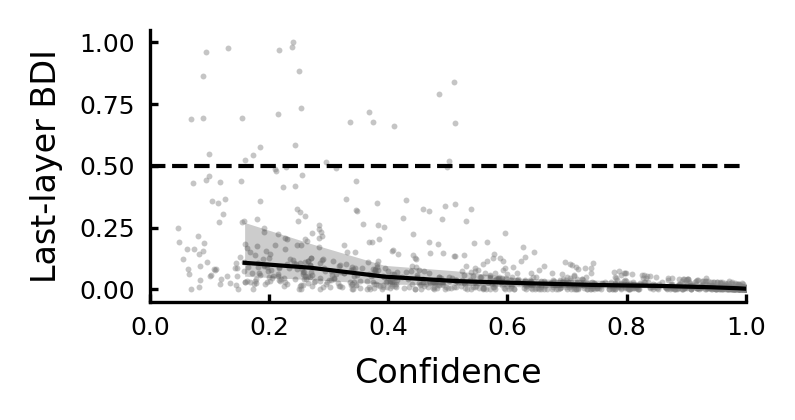

alexnet: n=1083, acc=nan
Binned summary: kept 10 bins (min_per_bin=25, method=quantile, nbins=10)
Last-layer BDI: classifier.6__bdi


In [ ]:
# ============================================================
# Confidence vs last-layer BDI scatter
# ImageNet subset version
# Works for AlexNet / VGG-16 / ViT-B/16
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
USE = "alexnet"      # "alexnet" | "vgg16" | "vit_b16"

out_dir = "/content/drive/MyDrive/AlexNet_Images"

# Set this to match your ImageNet subset size
N_IMAGENET = 1083

csv_path = os.path.join(
    out_dir,
    f"{USE}_local_imagenet{N_IMAGENET}_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv"
)

save_fig = True

CONF_LIM = (0.0, 1.0)
BDI_LIM  = (-0.05, 1.05)

NBINS = 10
BINNING = "quantile"     # "quantile" or "uniform"
SHOW_IQR = True
MIN_PER_BIN = 25


# ------------------------------------------------------------
# Load CSV
# ------------------------------------------------------------
if not os.path.isfile(csv_path):
    raise FileNotFoundError(f"CSV not found: {csv_path}")

df = pd.read_csv(csv_path)

print("Loaded:", csv_path)
print("Shape:", df.shape)
print("Columns:", df.columns[:20].tolist())


# ------------------------------------------------------------
# Locate core columns
# ------------------------------------------------------------
conf_col = (
    "conf_top1" if "conf_top1" in df.columns
    else "conf" if "conf" in df.columns
    else "top1_conf" if "top1_conf" in df.columns
    else None
)

bdi_col = (
    "bdi_all" if "bdi_all" in df.columns
    else "bdi_all_layers" if "bdi_all_layers" in df.columns
    else "bdi" if "bdi" in df.columns
    else None
)

if conf_col is None:
    raise ValueError(
        "Missing confidence column. Expected one of: "
        "'conf_top1', 'conf', 'top1_conf'."
    )

if bdi_col is None:
    raise ValueError(
        "Missing BDI column. Expected one of: "
        "'bdi_all', 'bdi_all_layers', 'bdi'."
    )


# ------------------------------------------------------------
# Layer sorting
# ------------------------------------------------------------
def cnn_layer_sort_key(colname: str):
    """
    CNN architecture order:
      features.* -> avgpool -> classifier.*
    """
    s = str(colname)
    s = re.sub(r"__bdi\d*$", "", s)
    s_norm = s.replace("__", ".").replace("_", ".")

    if s_norm.startswith("features"):
        group = 0
    elif s_norm.startswith("avgpool"):
        group = 1
    elif s_norm.startswith("classifier"):
        group = 2
    else:
        group = 3

    nums = re.findall(r"\d+", s_norm)
    idx = tuple(int(n) for n in nums) if nums else (10**9,)

    return (group, idx, s_norm)


def vit_layer_sort_key(colname: str):
    """
    ViT architecture order:
      conv_proj / patch embedding
      encoder blocks in order
      encoder.ln
      heads.head
    """
    s = str(colname)
    s = re.sub(r"__bdi\d*$", "", s)
    s_norm = s.replace("__", ".").replace("_", ".").lower()

    # Patch embedding / conv projection
    if s_norm.startswith("conv.proj") or s_norm.startswith("conv_proj"):
        return (0, -1, 0, s_norm)

    # Encoder block layers, e.g.
    # encoder.layers.encoder_layer_0.ln_1
    # encoder.layers.encoder_layer_0.self_attention.out_proj
    # encoder.layers.encoder_layer_0.mlp.0
    m = re.search(r"encoder.layer.(\d+)|encoder_layer.(\d+)|encoder_layer_(\d+)", s_norm)
    if m:
        block_vals = [g for g in m.groups() if g is not None]
        block_idx = int(block_vals[0])

        if "ln.1" in s_norm or "ln_1" in s_norm:
            subrank = 0
        elif "self.attention" in s_norm or "self_attention" in s_norm or "attention" in s_norm:
            subrank = 1
        elif "ln.2" in s_norm or "ln_2" in s_norm:
            subrank = 2
        elif "mlp" in s_norm:
            nums = re.findall(r"mlp[._](\d+)", s_norm)
            mlp_idx = int(nums[0]) if nums else 99
            subrank = 3 + mlp_idx
        else:
            subrank = 99

        return (1, block_idx, subrank, s_norm)

    # Final encoder norm
    if s_norm.startswith("encoder.ln") or "encoder.norm" in s_norm:
        return (2, 999, 0, s_norm)

    # Classification head
    if s_norm.startswith("heads") or s_norm.startswith("head") or "classifier" in s_norm:
        return (3, 999, 0, s_norm)

    return (9, 999, 999, s_norm)


def layer_sort_key(colname: str, use: str):
    if use.lower() == "vit_b16":
        return vit_layer_sort_key(colname)
    return cnn_layer_sort_key(colname)


# ------------------------------------------------------------
# Find last-layer BDI column
# Supports:
#   features.0__bdi
#   classifier.6__bdi
#   encoder.layers.encoder_layer_11.mlp.3__bdi
#   heads.head__bdi
#   <layer>__bdi0
# ------------------------------------------------------------
layer_bdi_cols = [
    c for c in df.columns
    if re.search(r"__bdi\d*$", c)
]

layer_bdi_cols = [
    c for c in layer_bdi_cols
    if c not in ("bdi_all", "bdi_all_layers", "bdi")
]

if len(layer_bdi_cols) > 0:
    layer_bdi_cols = sorted(
        layer_bdi_cols,
        key=lambda c: layer_sort_key(c, USE)
    )

    print("\nLayer BDI columns in architecture order:")
    for i, c in enumerate(layer_bdi_cols):
        print(f"{i:02d}: {c}")

    last_layer_col = layer_bdi_cols[-1]
    y = pd.to_numeric(df[last_layer_col], errors="coerce").to_numpy(float)

    print("\nUsing LAST-LAYER BDI column:", last_layer_col)

else:
    last_layer_col = None
    y = pd.to_numeric(df[bdi_col], errors="coerce").to_numpy(float)

    print("No per-layer BDI columns found; using global:", bdi_col)


x = pd.to_numeric(df[conf_col], errors="coerce").to_numpy(float)


# ------------------------------------------------------------
# Correctness / mismatch handling
# ------------------------------------------------------------
if "correct" in df.columns:
    correct = pd.to_numeric(df["correct"], errors="coerce").to_numpy(float)
else:
    print("No 'correct' column found. Plotting all points as unlabeled gray.")
    correct = np.full(len(df), np.nan)

mask = np.isfinite(x) & np.isfinite(y)

x = x[mask]
y = y[mask]
correct = correct[mask]

m_ok = correct == 1
m_bad = correct == 0
m_unknown = ~np.isfinite(correct)


# ------------------------------------------------------------
# Binned summary helper
# ------------------------------------------------------------
def binned_summary(xv, yv, nbins=10, method="quantile", min_per_bin=10):
    xv = np.asarray(xv)
    yv = np.asarray(yv)

    valid = np.isfinite(xv) & np.isfinite(yv)
    xv = xv[valid]
    yv = yv[valid]

    if xv.size == 0:
        return (
            np.array([]),
            np.array([]),
            np.array([]),
            np.array([]),
            np.array([]),
        )

    if method == "quantile":
        edges = np.quantile(xv, np.linspace(0, 1, nbins + 1))
        edges = np.unique(edges)

        if edges.size < 3:
            raise ValueError(
                "Quantile bin edges collapsed. "
                "Try BINNING='uniform' or fewer bins."
            )

    elif method == "uniform":
        edges = np.linspace(CONF_LIM[0], CONF_LIM[1], nbins + 1)

    else:
        raise ValueError("method must be 'quantile' or 'uniform'.")

    idx = np.digitize(xv, edges, right=False) - 1
    idx = np.clip(idx, 0, len(edges) - 2)

    xc, med, q25, q75, n = [], [], [], [], []

    for b in range(len(edges) - 1):
        sel = idx == b

        if sel.sum() < min_per_bin:
            continue

        xb = xv[sel]
        yb = yv[sel]

        xc.append(np.median(xb))
        med.append(np.median(yb))
        q25.append(np.quantile(yb, 0.25))
        q75.append(np.quantile(yb, 0.75))
        n.append(int(sel.sum()))

    return (
        np.asarray(xc),
        np.asarray(med),
        np.asarray(q25),
        np.asarray(q75),
        np.asarray(n),
    )


xc_all, med_all, q25_all, q75_all, n_all = binned_summary(
    x,
    y,
    nbins=NBINS,
    method=BINNING,
    min_per_bin=MIN_PER_BIN,
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(2.7, 1.5), dpi=300)

# Unknown correctness, if labels unavailable
if np.any(m_unknown):
    ax.scatter(
        x[m_unknown],
        y[m_unknown],
        s=2,
        color="gray",
        alpha=0.45,
        linewidths=0,
        rasterized=True,
    )

# Incorrect
if np.any(m_bad):
    ax.scatter(
        x[m_bad],
        y[m_bad],
        s=2,
        color="gray",
        alpha=0.65,
        linewidths=0,
        rasterized=True,
    )

# Correct
if np.any(m_ok):
    ax.scatter(
        x[m_ok],
        y[m_ok],
        s=2,
        color="black",
        alpha=1.0,
        linewidths=0,
        rasterized=True,
    )

# Binned median + IQR
if xc_all.size > 0:
    if SHOW_IQR:
        ax.fill_between(
            xc_all,
            q25_all,
            q75_all,
            alpha=0.20,
            linewidth=0,
            color="black",
        )

    ax.plot(
        xc_all,
        med_all,
        linewidth=1,
        color="black",
    )

ax.axhline(
    0.5,
    linestyle="--",
    color="black",
    linewidth=1,
)

ax.set_xlim(*CONF_LIM)
ax.set_ylim(*BDI_LIM)

ax.set_xlabel("Confidence", fontsize=8)
ax.set_ylabel("Last-layer BDI", fontsize=8)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.tick_params(
    axis="both",
    which="both",
    direction="in",
    length=2,
    labelsize=6,
)

fig.tight_layout()

if save_fig:
    outpath = os.path.join(
        out_dir,
        f"{USE}_local_imagenet{N_IMAGENET}_scatter_conf_vs_lastlayerBDI_with_binned_summary.eps"
    )

    fig.savefig(
        outpath,
        format="eps",
        bbox_inches="tight",
        pad_inches=0.02,
    )

    outpath_png = outpath.replace(".eps", ".png")

    fig.savefig(
        outpath_png,
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.02,
    )

    print("Saved:", outpath)
    print("Saved:", outpath_png)

plt.show()


# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------
if np.any(np.isfinite(correct)):
    acc = float(np.nanmean(correct))
else:
    acc = np.nan

print(f"{USE}: n={x.size}, acc={acc}")
print(
    f"Binned summary: kept {xc_all.size} bins "
    f"(min_per_bin={MIN_PER_BIN}, method={BINNING}, nbins={NBINS})"
)

if last_layer_col is not None:
    print("Last-layer BDI:", last_layer_col)
else:
    print("BDI column:", bdi_col)

Loaded: /content/drive/MyDrive/AlexNet_Images/vit_b16_local_imagenet1083_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv
Shape: (1083, 201)
First columns: ['fname', 'path', 'wnid', 'y_im1k', 'top1', 'top2', 'conf_top1', 'conf_top2', 'correct', 'bdi_all', 'C_evid_all', 'C_bias_all', 'conv_proj__bdi', 'encoder.layers.encoder_layer_0.ln_1__bdi', 'encoder.layers.encoder_layer_0.self_attention.out_proj__bdi']
Reconstructed:
  bdi_all_np: (1083,)
  top1_np: (1083,)
  top2_np: (1083,)
  N layerwise BDI arrays: 63
  First layers: ['conv_proj', 'encoder.layers.encoder_layer_0.ln_1', 'encoder.layers.encoder_layer_0.self_attention.out_proj', 'encoder.layers.encoder_layer_0.ln_2', 'encoder.layers.encoder_layer_0.mlp.0', 'encoder.layers.encoder_layer_0.mlp.3', 'encoder.layers.encoder_layer_1.ln_1', 'encoder.layers.encoder_layer_1.self_attention.out_proj', 'encoder.layers.encoder_layer_1.ln_2', 'encoder.layers.encoder_layer_1.mlp.0']

Layer order:
00: conv_proj
01: encoder.layers.encoder_layer_0.ln_1
0

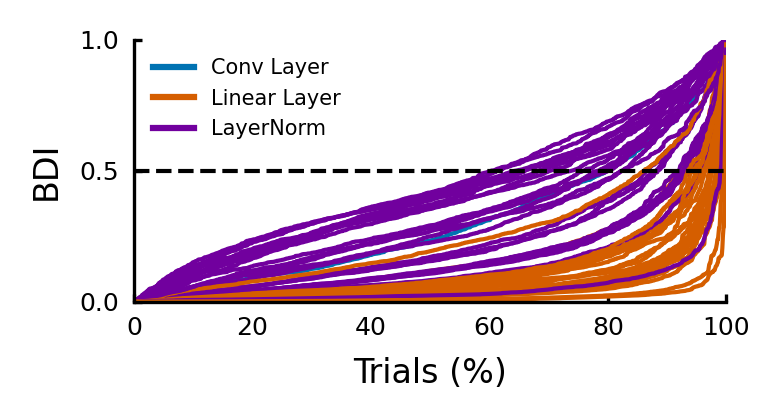

Saved: /content/drive/MyDrive/AlexNet_Images/vit_b16_local_imagenet1083_BDI_gt50_typecolors_cbfriendly.eps
Saved: /content/drive/MyDrive/AlexNet_Images/vit_b16_local_imagenet1083_BDI_gt50_typecolors_cbfriendly.png


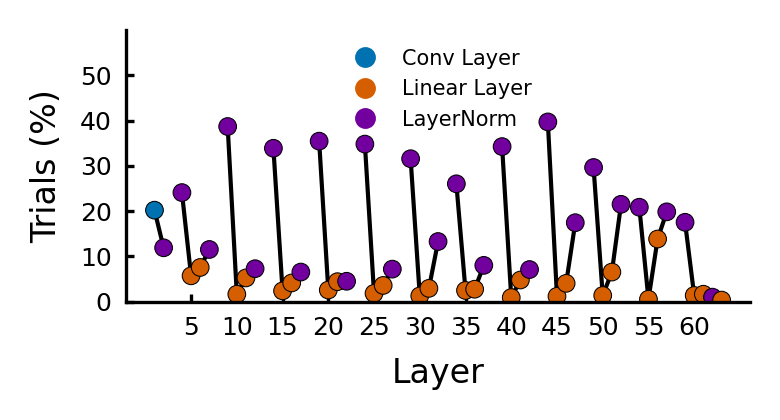

vit_b16: n images = 1083
Mean bdi_all = 0.1719
% bdi_all > 0.5 = 0.00%
N layers = 63


In [ ]:
# ============================================================
# Load ImageNet CSV + reconstruct layerwise BDI + make both plots
# Works for AlexNet, VGG-16, and ViT-B/16
#
# Color-blind friendly grouping:
#   CNN:
#     features   = blue
#     classifier = orange
#
#   ViT:
#     Conv / Patch              = blue
#     Linear / Attention / Head = orange
#     LayerNorm                 = green
# ============================================================

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
USE = "vit_b16"      # options: "alexnet", "vgg16", "vit_b16"

N_IMAGENET = 1083   # set to your local ImageNet subset size

save_fig = True
out_dir = "/content/drive/MyDrive/AlexNet_Images"
save_dir = out_dir
os.makedirs(save_dir, exist_ok=True)

show_legend_layerwise = True
show_legend_pct = True

include_all_layers = False
sort_each_layer = True
n_show = 10000

# ------------------------------------------------------------
# Color-blind friendly colors
# Okabe-Ito style palette
# ------------------------------------------------------------
FEATURE_COLOR = "#0072B2"      # blue
CLASSIFIER_COLOR = "#D55E00"   # vermillion / orange

CONV_COLOR = "#0072B2"         # blue
LINEAR_COLOR = "#D55E00"       # vermillion / orange
LAYERNORM_COLOR = "#71009e"    # purple

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
mpl.set_loglevel("error")


# ------------------------------------------------------------
# Load ImageNet CSV
# ------------------------------------------------------------
csv_path = os.path.join(
    out_dir,
    f"{USE}_local_imagenet{N_IMAGENET}_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv"
)

# Fallback: auto-detect if N_IMAGENET is not exactly right
if not os.path.isfile(csv_path):
    matches = sorted(glob.glob(
        os.path.join(
            out_dir,
            f"{USE}_local_imagenet*_bdi_ALL_LAYERS_with_conf_acc_Cevid_Cbias.csv"
        )
    ))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"CSV not found:\n{csv_path}\n\n"
            f"No fallback matches found for {USE}_local_imagenet*."
        )

    csv_path = matches[-1]
    print("Using auto-detected CSV:", csv_path)

df = pd.read_csv(csv_path)

print("Loaded:", csv_path)
print("Shape:", df.shape)
print("First columns:", df.columns[:15].tolist())


# ------------------------------------------------------------
# Core columns
# ------------------------------------------------------------
top1_col = (
    "top1" if "top1" in df.columns
    else "top1_idx" if "top1_idx" in df.columns
    else None
)

top2_col = (
    "top2" if "top2" in df.columns
    else "top2_idx" if "top2_idx" in df.columns
    else None
)

bdi_all_col = (
    "bdi_all" if "bdi_all" in df.columns
    else "bdi_all_layers" if "bdi_all_layers" in df.columns
    else None
)

if bdi_all_col is None:
    raise ValueError("Could not find 'bdi_all' or 'bdi_all_layers'.")

bdi_all_np = df[bdi_all_col].to_numpy(dtype=np.float32)
top1_np = df[top1_col].to_numpy(dtype=np.int32) if top1_col is not None else None
top2_np = df[top2_col].to_numpy(dtype=np.int32) if top2_col is not None else None


# ------------------------------------------------------------
# Reconstruct layerwise BDI dictionary
# Supports:
#   <layer>__bdi
#   <layer>__bdi0, <layer>__bdi1, ...
#   bdi_<layer>
# ------------------------------------------------------------
bdi_layers_np = {}

# Case 1: "<layer>__bdi"
scalar_bdi_cols = [
    c for c in df.columns
    if c.endswith("__bdi")
]

if len(scalar_bdi_cols) > 0:
    for c in scalar_bdi_cols:
        layer_name = c.replace("__bdi", "")
        bdi_layers_np[layer_name] = df[c].to_numpy(dtype=np.float32)

else:
    # Case 2: "<layer>__bdi0", "<layer>__bdi1", ...
    indexed_bdi_cols = [
        c for c in df.columns
        if re.search(r"__bdi\d+$", c)
    ]

    if len(indexed_bdi_cols) > 0:
        prefixes = sorted(
            set(re.sub(r"__bdi\d+$", "", c) for c in indexed_bdi_cols)
        )

        for pref in prefixes:
            cols_pref = [
                c for c in indexed_bdi_cols
                if re.sub(r"__bdi\d+$", "", c) == pref
            ]

            cols_pref = sorted(
                cols_pref,
                key=lambda c: int(re.search(r"__bdi(\d+)$", c).group(1))
            )

            arr = df[cols_pref].to_numpy(dtype=np.float32)

            if arr.shape[1] == 1:
                arr = arr[:, 0]

            bdi_layers_np[pref] = arr

    else:
        # Case 3: "bdi_<layer>"
        old_bdi_cols = [
            c for c in df.columns
            if c.startswith("bdi_") and c not in ("bdi_all", "bdi_all_layers")
        ]

        if len(old_bdi_cols) == 0:
            raise ValueError(
                "Could not find any layerwise BDI columns.\n"
                "Expected '<layer>__bdi', '<layer>__bdi0', or 'bdi_<layer>'."
            )

        for c in old_bdi_cols:
            layer_name = c[len("bdi_"):]
            bdi_layers_np[layer_name] = df[c].to_numpy(dtype=np.float32)

print("Reconstructed:")
print("  bdi_all_np:", bdi_all_np.shape)
print("  top1_np:", None if top1_np is None else top1_np.shape)
print("  top2_np:", None if top2_np is None else top2_np.shape)
print("  N layerwise BDI arrays:", len(bdi_layers_np))
print("  First layers:", list(bdi_layers_np.keys())[:10])


# ------------------------------------------------------------
# Layer ordering
# ------------------------------------------------------------
def cnn_layer_sort_key(name: str):
    """
    CNN order:
      features.* -> avgpool -> classifier.*
    """
    s = str(name)
    s = re.sub(r"^bdi_", "", s)
    s = s.replace("__", ".").replace("_", ".")
    parts = s.split(".")
    prefix = parts[0] if len(parts) > 0 else s

    if prefix == "features":
        group = 0
    elif prefix == "avgpool":
        group = 1
    elif prefix == "classifier":
        group = 2
    else:
        group = 3

    nums = re.findall(r"\d+", s)
    idx = tuple(int(n) for n in nums) if nums else (10**9,)

    return (group, idx, s)


def vit_layer_sort_key(name: str):
    """
    ViT order:
      conv_proj / patch embedding
      encoder blocks in order
      final encoder norm
      classifier head
    """
    s = str(name)
    s = re.sub(r"^bdi_", "", s)
    s_norm = s.replace("__", ".").replace("_", ".").lower()

    # Patch embedding
    if s_norm.startswith("conv.proj") or s_norm.startswith("conv_proj"):
        return (0, -1, 0, s_norm)

    # Encoder blocks
    m = re.search(
        r"encoder\.layers\.encoder\.layer\.(\d+)|"
        r"encoder\.layers\.encoder_layer\.(\d+)|"
        r"encoder\.layer\.(\d+)|"
        r"encoder_layer\.(\d+)|"
        r"encoder_layer_(\d+)",
        s_norm
    )

    if m:
        block_vals = [g for g in m.groups() if g is not None]
        block_idx = int(block_vals[0])

        if "ln.1" in s_norm or "ln_1" in s_norm:
            subrank = 0
        elif "self.attention" in s_norm or "self_attention" in s_norm or "attention" in s_norm:
            subrank = 1
        elif "ln.2" in s_norm or "ln_2" in s_norm:
            subrank = 2
        elif "mlp" in s_norm:
            nums = re.findall(r"mlp[._](\d+)", s_norm)
            mlp_idx = int(nums[0]) if nums else 99
            subrank = 3 + mlp_idx
        else:
            subrank = 99

        return (1, block_idx, subrank, s_norm)

    # Final encoder norm
    if s_norm.startswith("encoder.ln") or "encoder.norm" in s_norm:
        return (2, 999, 0, s_norm)

    # Classifier head
    if s_norm.startswith("heads") or s_norm.startswith("head") or "classifier" in s_norm:
        return (3, 999, 0, s_norm)

    return (9, 999, 999, s_norm)


def layer_sort_key(name: str):
    if USE.lower() == "vit_b16":
        return vit_layer_sort_key(name)
    return cnn_layer_sort_key(name)


layer_names = sorted(bdi_layers_np.keys(), key=layer_sort_key)

print("\nLayer order:")
for i, name in enumerate(layer_names):
    print(f"{i:02d}: {name}")


# ------------------------------------------------------------
# Color assignment
# ------------------------------------------------------------
def cnn_layer_group(name: str):
    s = str(name)
    s = re.sub(r"^bdi_", "", s)
    s = s.replace("__", ".").replace("_", ".")
    prefix = s.split(".")[0] if len(s) > 0 else s

    if prefix == "features":
        return "features"
    elif prefix == "classifier":
        return "classifier"
    else:
        return "other"


def vit_layer_group(name: str):
    s = str(name)
    s = re.sub(r"^bdi_", "", s)
    s_norm = s.replace("__", ".").replace("_", ".").lower()

    # LayerNorm first
    if (
        "layernorm" in s_norm
        or re.search(r"(^|\.|_)ln(\.|_|$)", s_norm)
        or re.search(r"ln[._]?\d+", s_norm)
        or ("norm" in s_norm and "conv" not in s_norm)
    ):
        return "layernorm"

    # Conv / patch projection
    if (
        "conv.proj" in s_norm
        or "conv_proj" in s_norm
        or "patch" in s_norm
        or "embed" in s_norm
        or "embedding" in s_norm
    ):
        return "conv"

    # Linear / attention / head
    if (
        "linear" in s_norm
        or "mlp" in s_norm
        or "head" in s_norm
        or "classifier" in s_norm
        or "fc" in s_norm
        or "attention" in s_norm
        or "attn" in s_norm
        or "out_proj" in s_norm
        or "q_proj" in s_norm
        or "k_proj" in s_norm
        or "v_proj" in s_norm
    ):
        return "linear"

    return "other"


def layer_color(name: str):
    if USE.lower() == "vit_b16":
        group = vit_layer_group(name)

        if group == "conv":
            return CONV_COLOR
        elif group == "linear":
            return LINEAR_COLOR
        elif group == "layernorm":
            return LAYERNORM_COLOR
        else:
            return OTHER_COLOR

    else:
        group = cnn_layer_group(name)

        if group == "features":
            return FEATURE_COLOR
        elif group == "classifier":
            return CLASSIFIER_COLOR
        else:
            return OTHER_COLOR


layer_colors = {
    name: layer_color(name)
    for name in layer_names
}

layer_color_list = [
    layer_colors[name]
    for name in layer_names
]

N = len(layer_names)

if N == 0:
    raise ValueError("No layerwise BDI arrays were reconstructed.")


# ------------------------------------------------------------
# Legends
# ------------------------------------------------------------
if USE.lower() == "vit_b16":
    legend_line_handles = [
        Line2D([0], [0], color=CONV_COLOR, lw=1.5, label="Conv Layer"),
        Line2D([0], [0], color=LINEAR_COLOR, lw=1.5, label="Linear Layer"),
        Line2D([0], [0], color=LAYERNORM_COLOR, lw=1.5, label="LayerNorm"),
    ]

    legend_dot_handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor=CONV_COLOR,
               markeredgecolor=CONV_COLOR, markersize=4, label="Conv Layer"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor=LINEAR_COLOR,
               markeredgecolor=LINEAR_COLOR, markersize=4, label="Linear Layer"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor=LAYERNORM_COLOR,
               markeredgecolor=LAYERNORM_COLOR, markersize=4, label="LayerNorm"),
    ]
else:
    legend_line_handles = [
        Line2D([0], [0], color=FEATURE_COLOR, lw=1.5, label="Conv Layer"),
        Line2D([0], [0], color=CLASSIFIER_COLOR, lw=1.5, label="Linear Layer"),
    ]

    legend_dot_handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor=FEATURE_COLOR,
               markeredgecolor=FEATURE_COLOR, markersize=4, label="Conv Layer"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor=CLASSIFIER_COLOR,
               markeredgecolor=CLASSIFIER_COLOR, markersize=4, label="Linear Layer"),
    ]


# ============================================================
# Plot 1: Layer-resolved BDI curves
# ============================================================
fig, ax = plt.subplots(figsize=(2.7, 1.5), dpi=300)

for name in layer_names:
    bdi = np.asarray(bdi_layers_np[name]).reshape(-1)
    bdi = bdi[np.isfinite(bdi)]

    if bdi.size == 0:
        continue

    if sort_each_layer:
        bdi = np.sort(bdi)

    n = min(n_show, bdi.size)
    x = np.linspace(0, 100, n) if n > 1 else np.array([0.0])

    ax.plot(
        x,
        bdi[:n],
        linewidth=1,
        alpha=1,
        color=layer_colors[name],
        label=name
    )

if include_all_layers:
    bdi = np.asarray(bdi_all_np).reshape(-1)
    bdi = bdi[np.isfinite(bdi)]

    if sort_each_layer:
        bdi = np.sort(bdi)

    n = min(n_show, bdi.size)
    x = np.linspace(0, 100, n) if n > 1 else np.array([0.0])

    ax.plot(
        x,
        bdi[:n],
        linewidth=1.4,
        color="black",
        label="all_layers"
    )

ax.axhline(
    0.5,
    linestyle="--",
    color="black",
    linewidth=1
)

ax.set_xlim(0, 100)
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}"))

ax.set_ylim(0, 1)
ax.set_yticks([0, 0.5, 1])

ax.set_xlabel("Trials (%)", fontsize=8)
ax.set_ylabel("BDI", fontsize=8)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.tick_params(
    axis="y",
    which="both",
    direction="in",
    left=True,
    right=False,
    length=2,
    labelsize=6
)

ax.tick_params(
    axis="x",
    which="both",
    direction="in",
    length=2,
    labelsize=6
)

if show_legend_layerwise:
    ax.legend(
        handles=legend_line_handles,
        fontsize=5,
        frameon=False,
        loc="upper left",
        # bbox_to_anchor=(1.02, 0.5)
    )

fig.tight_layout()

if save_fig:
    base = os.path.join(
        save_dir,
        f"{USE}_local_imagenet{len(df)}_BDI_all_layers_typecolors_cbfriendly"
    )

    fig.savefig(
        base + ".eps",
        format="eps",
        bbox_inches="tight",
        pad_inches=0.02
    )

    fig.savefig(
        base + ".png",
        format="png",
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.02
    )

    print("Saved:", base + ".eps")
    print("Saved:", base + ".png")

plt.show()


# ============================================================
# Plot 2: Percent trials with BDI > 0.5
# ============================================================
pct_gt05 = []

for name in layer_names:
    bdi = np.asarray(bdi_layers_np[name]).ravel()
    bdi = bdi[np.isfinite(bdi)]

    pct_gt05.append(
        100.0 * np.mean(bdi > 0.5)
        if bdi.size
        else np.nan
    )

pct_gt05 = np.asarray(pct_gt05, dtype=float)
x = np.arange(N)

fig_pct, ax_pct = plt.subplots(figsize=(2.7, 1.5), dpi=300)

ax_pct.plot(
    x,
    pct_gt05,
    linestyle="-",
    linewidth=1,
    color="black",
    zorder=1
)

ax_pct.scatter(
    x,
    pct_gt05,
    c=layer_color_list,
    s=18,
    edgecolor="black",
    linewidth=0.25,
    zorder=2
)

ax_pct.set_ylim(0, 60)
ax_pct.set_yticks([0, 10, 20, 30, 40, 50])
ax_pct.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.0f}"))

ax_pct.set_xlabel("Layer", fontsize=8)
ax_pct.set_ylabel("Trials (%)", fontsize=8)

# Show every 5th layer tick: 5, 10, 15, ...
tick_pos = np.arange(4, N, 5)
tick_lab = [str(i) for i in range(5, N + 1, 5)]

ax_pct.set_xticks(tick_pos)
ax_pct.set_xticklabels(tick_lab, fontsize=6)

ax_pct.spines["right"].set_visible(False)
ax_pct.spines["top"].set_visible(False)

ax_pct.tick_params(
    axis="y",
    which="both",
    direction="in",
    left=True,
    right=False,
    length=2,
    labelsize=6
)

ax_pct.tick_params(
    axis="x",
    which="both",
    direction="in",
    length=2,
    labelsize=6
)

if show_legend_pct:
    ax_pct.legend(
        handles=legend_dot_handles,
        fontsize=5,
        frameon=False,
        loc="best"
    )

fig_pct.tight_layout()

if save_fig:
    base = os.path.join(
        save_dir,
        f"{USE}_local_imagenet{len(df)}_BDI_gt50_typecolors_cbfriendly"
    )

    fig_pct.savefig(
        base + ".eps",
        format="eps",
        bbox_inches="tight",
        pad_inches=0.02
    )

    fig_pct.savefig(
        base + ".png",
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.02
    )

    print("Saved:", base + ".eps")
    print("Saved:", base + ".png")

plt.show()


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print(f"{USE}: n images = {len(df)}")
print(f"Mean bdi_all = {np.nanmean(bdi_all_np):.4f}")
print(f"% bdi_all > 0.5 = {100 * np.nanmean(bdi_all_np > 0.5):.2f}%")
print(f"N layers = {N}")